In [6]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))


## S


- s / average / inverse_transform


In [7]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from data_provider.icecore_data_loader import Dataset_IceCore_S

print("PROJECT_ROOT =", PROJECT_ROOT)

try:
    from scipy import stats
except Exception:
    stats = None


def _to_str_array(arr):
    out = []
    for x in np.asarray(arr).reshape(-1):
        if isinstance(x, bytes):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return np.asarray(out)


def _as_1d_float(arr):
    arr = np.asarray(arr, dtype=np.float32)
    if arr.ndim == 2 and arr.shape[-1] == 1:
        arr = arr[:, 0]
    return arr.reshape(-1)


def _squeeze_target_array(arr, name="values"):
    arr = np.asarray(arr)
    if arr.ndim == 3 and arr.shape[-1] == 1:
        return arr[..., 0]
    if arr.ndim == 3:
        return arr[..., -1]
    if arr.ndim == 2:
        return arr
    raise ValueError(f"{name} 应为 [N,T] 或 [N,T,C]，实际 {arr.shape}")


def _calc_mean_and_sort(data_dict):
    if not data_dict:
        return np.asarray([], dtype=np.float32), np.asarray([], dtype=np.float32)
    sorted_years = sorted(data_dict.keys())
    mean_vals = [np.mean(data_dict[y]) for y in sorted_years]
    return np.asarray(sorted_years, dtype=np.float32), np.asarray(mean_vals, dtype=np.float32)


def _moving_average_1d(x, window=3):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if window <= 1 or len(x) < window:
        return x
    kernel = np.ones(window, dtype=np.float32) / float(window)
    return np.convolve(x, kernel, mode="valid")


def _corr_1d(pred, true):
    pred = np.asarray(pred, dtype=np.float32).reshape(-1)
    true = np.asarray(true, dtype=np.float32).reshape(-1)
    mask = np.isfinite(pred) & np.isfinite(true)
    pred = pred[mask]
    true = true[mask]
    if len(pred) < 2 or np.std(pred) <= 1e-8 or np.std(true) <= 1e-8:
        return np.nan
    return float(np.corrcoef(pred, true)[0, 1])


def _smooth_corr_1d(pred, true, window=3):
    pred_s = _moving_average_1d(pred, window=window)
    true_s = _moving_average_1d(true, window=window)
    n = min(len(pred_s), len(true_s))
    if n == 0:
        return np.nan
    return _corr_1d(pred_s[:n], true_s[:n])


def _align_by_lag(pred, true, lag):
    pred = np.asarray(pred, dtype=np.float32).reshape(-1)
    true = np.asarray(true, dtype=np.float32).reshape(-1)
    if lag < 0:
        p = pred[-lag:]
        t = true[:len(p)]
    elif lag > 0:
        p = pred[:-lag]
        t = true[lag:]
    else:
        p = pred
        t = true
    n = min(len(p), len(t))
    return p[:n], t[:n]


def _lag_aware_corr_1d(pred, true, max_lag=2):
    best_corr = np.nan
    best_lag = 0
    for lag in range(-max_lag, max_lag + 1):
        p, t = _align_by_lag(pred, true, lag)
        if len(p) < 2:
            continue
        corr = _corr_1d(p, t)
        if np.isfinite(corr) and (not np.isfinite(best_corr) or corr > best_corr):
            best_corr = corr
            best_lag = lag
    return float(best_corr) if np.isfinite(best_corr) else np.nan, int(best_lag)


def _nse_1d(pred, true):
    pred = np.asarray(pred, dtype=np.float32).reshape(-1)
    true = np.asarray(true, dtype=np.float32).reshape(-1)
    mask = np.isfinite(pred) & np.isfinite(true)
    pred = pred[mask]
    true = true[mask]
    if len(pred) == 0:
        return np.nan
    denominator = float(np.sum((true - np.mean(true)) ** 2))
    if denominator <= 1e-12:
        return np.nan
    return float(1.0 - np.sum((true - pred) ** 2) / denominator)


def _lag_aware_nse_1d(pred, true, max_lag=2):
    best_nse = np.nan
    best_lag = 0
    for lag in range(-max_lag, max_lag + 1):
        p, t = _align_by_lag(pred, true, lag)
        if len(p) < 2:
            continue
        nse = _nse_1d(p, t)
        if np.isfinite(nse) and (not np.isfinite(best_nse) or nse > best_nse):
            best_nse = nse
            best_lag = lag
    return float(best_nse) if np.isfinite(best_nse) else np.nan, int(best_lag)


def _calc_prediction_metrics(pred, true):
    pred = np.asarray(pred, dtype=np.float32).reshape(-1)
    true = np.asarray(true, dtype=np.float32).reshape(-1)
    mask = np.isfinite(pred) & np.isfinite(true)
    pred = pred[mask]
    true = true[mask]
    if len(pred) == 0:
        return {
            "n": 0, "mse": np.nan, "rmse": np.nan,"mae": np.nan, "corr": np.nan,
            "corr_smooth_3": np.nan, "lag_corr": np.nan, "best_lag": np.nan,
            "nse": np.nan, "lag_nse": np.nan, "best_nse_lag": np.nan,
            "smape": np.nan, "ks_stat": np.nan, "ks_pvalue": np.nan,
        }
    err = pred - true
    mse = float(np.mean(err ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(err)))
    corr = _corr_1d(pred, true)
    corr_smooth_3 = _smooth_corr_1d(pred, true, window=3)
    lag_corr, best_lag = _lag_aware_corr_1d(pred, true, max_lag=2)
    nse = _nse_1d(pred, true)
    lag_nse, best_nse_lag = _lag_aware_nse_1d(pred, true, max_lag=2)
    smape = float(np.mean(200.0 * np.abs(pred - true) / (np.abs(true) + np.abs(pred) + 1e-8)))
    if stats is not None:
        ks_stat, ks_pvalue = stats.ks_2samp(true, pred)
        ks_stat = float(ks_stat)
        ks_pvalue = float(ks_pvalue)
    else:
        ks_stat = np.nan
        ks_pvalue = np.nan
    return {
        "n": int(len(pred)), "mse": mse, "rmse": rmse,"mae": mae, "corr": corr,
        "corr_smooth_3": corr_smooth_3, "lag_corr": lag_corr, "best_lag": best_lag,
        "nse": nse, "lag_nse": lag_nse, "best_nse_lag": best_nse_lag,
        "smape": smape, "ks_stat": ks_stat, "ks_pvalue": ks_pvalue,
    }


def _format_metrics(metrics):
    return (
        f"N={metrics['n']} | "
        f"mse: {metrics['mse']:.4f}, rmse: {metrics['rmse']:.4f}, mae: {metrics['mae']:.4f} | "
        f"corr: {metrics['corr']:.4f} | "
        f"corr_smooth_3: {metrics['corr_smooth_3']:.4f} | "
        f"lag_corr@±2: {metrics['lag_corr']:.4f}, best_lag: {metrics['best_lag']} | "
        f"NSE: {metrics['nse']:.4f} | "
        f"lag_NSE@±2: {metrics['lag_nse']:.4f}, best_nse_lag: {metrics['best_nse_lag']} | "
        f"SMAPE(%): {metrics['smape']:.2f} | "
        f"KS-D: {metrics['ks_stat']:.4f}, KS-p: {metrics['ks_pvalue']:.4g}"
    )


def _print_prediction_metrics(label, metrics):
    print(f"[{label}] {_format_metrics(metrics)}")


def _metric_ready_curve(arr):
    return np.asarray(arr, dtype=np.float32).reshape(1, -1, 1)



def _safe_inverse_transform_s(dataset, vals):
    vals = np.asarray(vals, dtype=np.float32).reshape(-1)
    if len(vals) == 0:
        return vals
    return dataset.inverse_transform(vals.reshape(-1, 1)).reshape(-1)


def _write_metrics_csv(path, rows):
    if not rows:
        return
    fieldnames = list(rows[0].keys())
    with open(path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def visualise_icecore_s_with_history(
    npz_path,
    target_cluster,
    root_path,
    data_path,
    cluster_result_path,
    site_meta_path="dataset/icecore/data_sources.csv",
    target="accum",
    seq_len=32,
    label_len=16,
    pred_len=32,
    apply_pywt=True,
    residual_prediction=False,
    support_ratio=0.66,
    filter_cid=None,
    save_dir=None,
    show=True,
    inverse_transform_values=False,
):
    """
    单变量可视化。inverse_transform_values=True 时，图和指标都使用反归一化值；
    False 时使用 results.npz 中的 scaled 值。
    """
    dataset = Dataset_IceCore_S(
        root_path=root_path,
        data_path=data_path,
        flag="train",
        size=[seq_len, label_len, pred_len],
        features="S",
        target=target,
        scale=True,
        timeenc=1,
        freq="y",
        percent=100,
        task_name="long_term_forecast",
        is_pretraining=0,
        apply_pywt=apply_pywt,
        site_meta_path=site_meta_path,
        cluster_result_path=cluster_result_path,
        residual_prediction=residual_prediction,
        support_ratio=support_ratio,
        filter_cid=filter_cid,
        verbose=False,
    )

    data = np.load(npz_path, allow_pickle=True)
    preds = _squeeze_target_array(data["preds"], "preds")
    trues = _squeeze_target_array(data["trues"], "trues")
    sites = _to_str_array(data["sites"])
    years = np.asarray(data["years"])
    clusters = np.asarray(data["clusters"]).reshape(-1)
    inputs = _squeeze_target_array(data["inputs"], "inputs") if "inputs" in data else None
    has_inputs = inputs is not None

    scale_label = "scaled"
    if inverse_transform_values:
        preds = _safe_inverse_transform_s(dataset, preds.reshape(-1)).reshape(preds.shape)
        trues = _safe_inverse_transform_s(dataset, trues.reshape(-1)).reshape(trues.shape)
        if has_inputs:
            inputs = _safe_inverse_transform_s(dataset, inputs.reshape(-1)).reshape(inputs.shape)
        scale_label = "inverse-transformed"

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    print(f"Loaded results: preds={preds.shape}, trues={trues.shape}, scale={scale_label}")
    if stats is None:
        print("[warn] scipy 不可用，K-S Test 指标会是 NaN")

    overall_metrics = _calc_prediction_metrics(preds, trues)
    _print_prediction_metrics("overall test windows", overall_metrics)

    target_mask = clusters == target_cluster
    if not np.any(target_mask):
        print(f"No data found for Cluster {target_cluster}.")
        return None

    cluster_metrics = _calc_prediction_metrics(preds[target_mask], trues[target_mask])
    _print_prediction_metrics(f"cluster {target_cluster} test windows", cluster_metrics)

    unique_sites = np.unique(sites[target_mask])
    site_metric_rows = []
    all_curve_pred = []
    all_curve_true = []

    for site_idx, site_name in enumerate(unique_sites):
        site_mask = (sites == site_name) & target_mask
        site_idx_list = np.where(site_mask)[0]

        agg_history = defaultdict(list)
        agg_trues = defaultdict(list)
        agg_preds = defaultdict(list)

        window_metrics = _calc_prediction_metrics(preds[site_idx_list], trues[site_idx_list])
        _print_prediction_metrics(f"{site_name} | window", window_metrics)

        for idx in site_idx_list:
            year_item = years[idx]
            year_arr = np.asarray(year_item).reshape(-1)
            if len(year_arr) > 1:
                pred_years = year_arr.astype(int)
                first_pred_year = int(pred_years[0])
            else:
                first_pred_year = int(year_arr[0])
                pred_years = np.arange(first_pred_year, first_pred_year + preds.shape[1])

            if has_inputs:
                history_seq = inputs[idx]
                hist_years = np.arange(first_pred_year - len(history_seq), first_pred_year)
                for yr, val in zip(hist_years, history_seq):
                    agg_history[int(yr)].append(float(val))

            y_true_seq = trues[idx]
            y_pred_seq = preds[idx]
            usable_len = min(len(pred_years), len(y_true_seq), len(y_pred_seq))
            for j in range(usable_len):
                yr = int(pred_years[j])
                agg_trues[yr].append(float(y_true_seq[j]))
                agg_preds[yr].append(float(y_pred_seq[j]))

        hist_years, hist_vals = _calc_mean_and_sort(agg_history)
        true_years, true_vals = _calc_mean_and_sort(agg_trues)
        pred_years, pred_vals = _calc_mean_and_sort(agg_preds)

        curve_metrics = _calc_prediction_metrics(_metric_ready_curve(pred_vals), _metric_ready_curve(true_vals))
        _print_prediction_metrics(f"{site_name} | curve", curve_metrics)

        all_curve_pred.append(pred_vals)
        all_curve_true.append(true_vals)

        row = {"site": site_name}
        for prefix, metrics in [("window", window_metrics), ("curve", curve_metrics)]:
            for key, value in metrics.items():
                row[f"{prefix}_{key}"] = value
        site_metric_rows.append(row)

        plt.figure(figsize=(14, 6))
        if has_inputs and len(hist_years) > 0:
            plt.plot(hist_years, hist_vals, label="Aggregated History", color="gray", linestyle="-", alpha=0.6, linewidth=1.8)
        plt.plot(true_years, true_vals, label="Aggregated True Future", color="#1f77b4", marker="o", markersize=4, linewidth=2)
        plt.plot(pred_years, pred_vals, label="Aggregated MAML Prediction", color="#ff7f0e", linestyle="--", marker="x", markersize=5, linewidth=2)
        plt.title(
            f"{site_idx + 1}/{len(unique_sites)} | {site_name} | Cluster {target_cluster} | "
            f"curve corr={curve_metrics['corr']:.3f}, NSE={curve_metrics['nse']:.3f}, "
            f"lag_NSE={curve_metrics['lag_nse']:.3f}@{curve_metrics['best_nse_lag']}",
            fontsize=13,
            pad=10,
        )
        plt.xlabel("Year", fontsize=12)
        plt.ylabel("Physical Value" if inverse_transform_values else "Scaled Value", fontsize=12)
        plt.legend(loc="best", fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        if save_dir is not None:
            safe_site = str(site_name).replace("/", "_").replace("\\", "_").replace(" ", "_").replace(":", "_")
            save_path = os.path.join(save_dir, f"cluster{target_cluster}_{safe_site}.png")
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"Saved: {save_path}")

        if show:
            plt.show()
        else:
            plt.close()

    overall_curve_metrics = _calc_prediction_metrics(np.concatenate(all_curve_pred), np.concatenate(all_curve_true)) if all_curve_pred else _calc_prediction_metrics([], [])
    print("\n========== Summary over plotted single-variable sites ==========")
    print(f"sites plotted: {len(site_metric_rows)}")
    _print_prediction_metrics("overall test windows", overall_metrics)
    _print_prediction_metrics(f"cluster {target_cluster} test windows", cluster_metrics)
    _print_prediction_metrics(f"cluster {target_cluster} aggregated curves", overall_curve_metrics)

    if save_dir is not None:
        _write_metrics_csv(os.path.join(save_dir, "site_metrics.csv"), site_metric_rows)
        with open(os.path.join(save_dir, "overall_metrics.txt"), "w") as f:
            f.write(f"scale={scale_label}\n")
            f.write("overall test windows | " + _format_metrics(overall_metrics) + "\n")
            f.write(f"cluster {target_cluster} test windows | " + _format_metrics(cluster_metrics) + "\n")
            f.write(f"cluster {target_cluster} aggregated curves | " + _format_metrics(overall_curve_metrics) + "\n")

    return {
        "scale": scale_label,
        "overall_window": overall_metrics,
        "cluster_window": cluster_metrics,
        "cluster_curve": overall_curve_metrics,
        "site_rows": site_metric_rows,
    }


PROJECT_ROOT = /sharedata/home/cyyang/SEMPO_copy0707


Loaded results: preds=(462, 16), trues=(462, 16), scale=scaled
[overall test windows] N=7392 | mse: 0.0516, mae: 0.1452 | corr: 0.9534 | corr_smooth_3: 0.9676 | lag_corr@±2: 0.9534, best_lag: 0 | NSE: 0.9024 | lag_NSE@±2: 0.9024, best_nse_lag: 0 | SMAPE(%): 37.63 | KS-D: 0.0732, KS-p: 1.234e-17
[cluster 0 test windows] N=2112 | mse: 0.0954, mae: 0.2219 | corr: 0.6196 | corr_smooth_3: 0.6980 | lag_corr@±2: 0.6196, best_lag: 0 | NSE: 0.3422 | lag_NSE@±2: 0.3422, best_nse_lag: 0 | SMAPE(%): 88.98 | KS-D: 0.1510, KS-p: 1.997e-21
[Ekstroem B04 | window] N=528 | mse: 0.1843, mae: 0.3593 | corr: -0.0329 | corr_smooth_3: 0.0056 | lag_corr@±2: 0.1661, best_lag: -2 | NSE: -0.1943 | lag_NSE@±2: -0.0848, best_nse_lag: -2 | SMAPE(%): 54.87 | KS-D: 0.5530, KS-p: 1.403e-74
[Ekstroem B04 | curve] N=48 | mse: 0.1548, mae: 0.3268 | corr: 0.0718 | corr_smooth_3: 0.1342 | lag_corr@±2: 0.2868, best_lag: -2 | NSE: -0.2254 | lag_NSE@±2: -0.0636, best_nse_lag: -2 | SMAPE(%): 50.27 | KS-D: 0.5625, KS-p: 2.432e

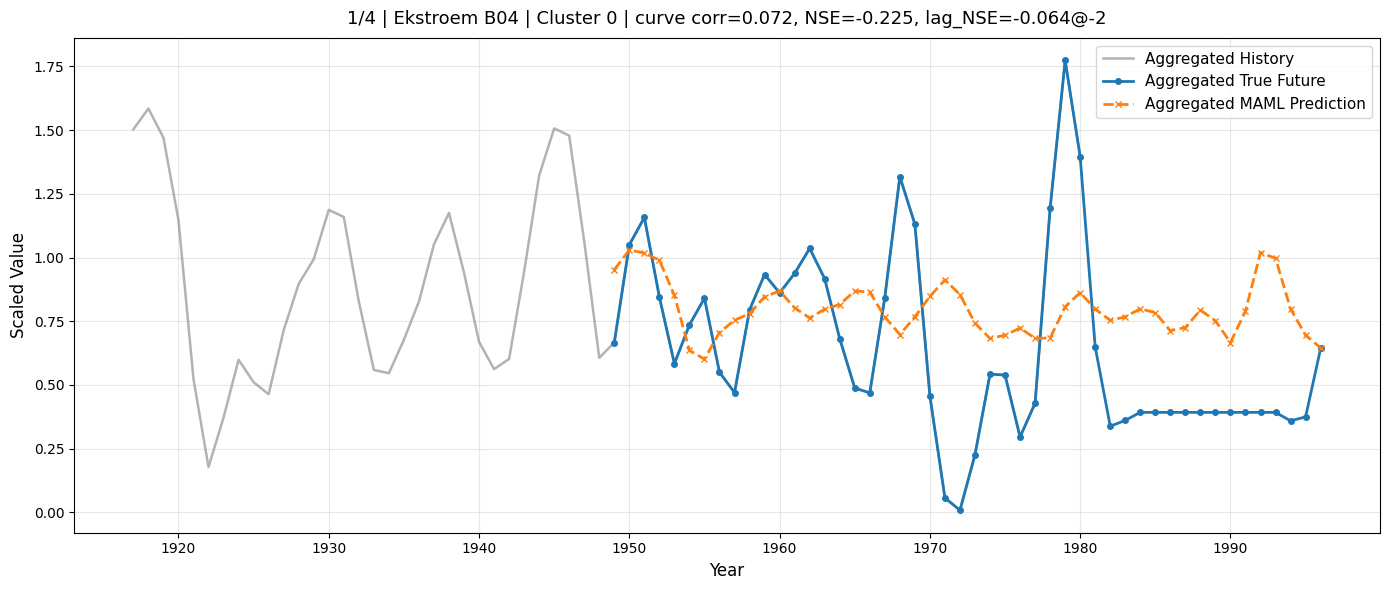

[Fimbulisen s100 | window] N=528 | mse: 0.1280, mae: 0.2835 | corr: 0.1232 | corr_smooth_3: 0.0841 | lag_corr@±2: 0.1232, best_lag: 0 | NSE: -0.0383 | lag_NSE@±2: -0.0383, best_nse_lag: 0 | SMAPE(%): 85.56 | KS-D: 0.3409, KS-p: 1.368e-27
[Fimbulisen s100 | curve] N=48 | mse: 0.1257, mae: 0.2772 | corr: 0.3270 | corr_smooth_3: 0.3096 | lag_corr@±2: 0.4288, best_lag: -1 | NSE: 0.1043 | lag_NSE@±2: 0.1603, best_nse_lag: -1 | SMAPE(%): 77.84 | KS-D: 0.3542, KS-p: 0.004545


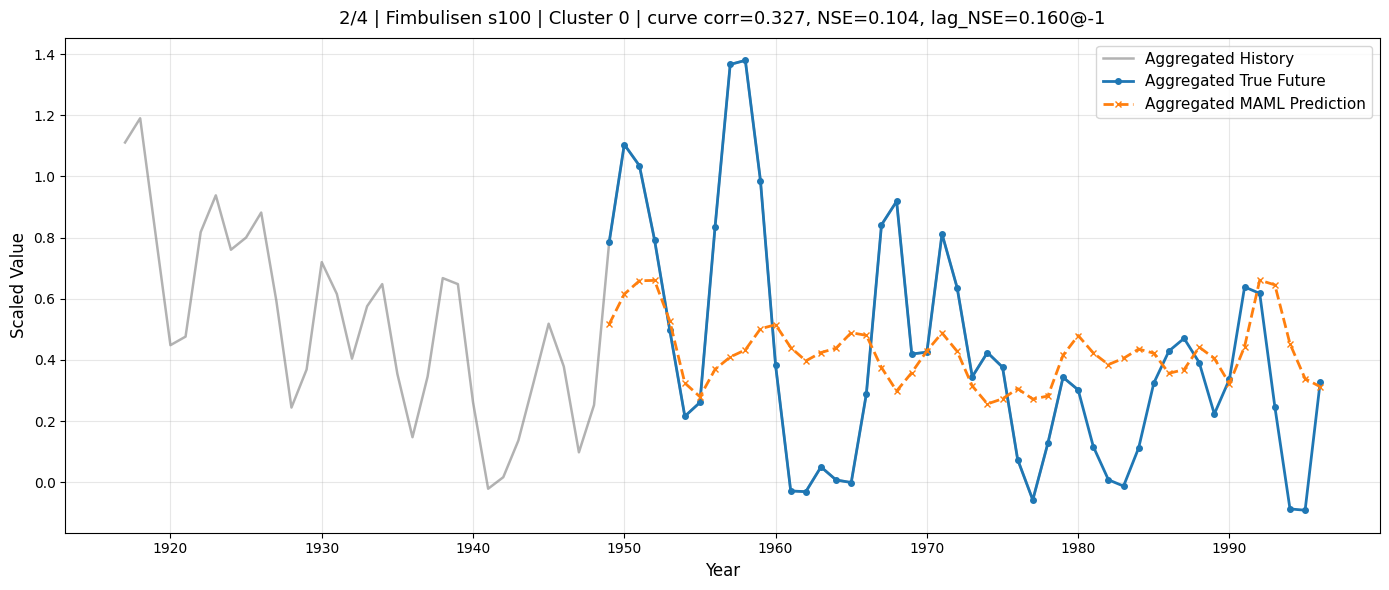

[ITASE-00-1 | window] N=528 | mse: 0.0624, mae: 0.1770 | corr: 0.3684 | corr_smooth_3: 0.4227 | lag_corr@±2: 0.3684, best_lag: 0 | NSE: 0.1246 | lag_NSE@±2: 0.1246, best_nse_lag: 0 | SMAPE(%): 105.17 | KS-D: 0.2424, KS-p: 5.043e-14
[ITASE-00-1 | curve] N=48 | mse: 0.0513, mae: 0.1575 | corr: 0.4607 | corr_smooth_3: 0.5223 | lag_corr@±2: 0.4607, best_lag: 0 | NSE: 0.1802 | lag_NSE@±2: 0.1802, best_nse_lag: 0 | SMAPE(%): 98.88 | KS-D: 0.2708, KS-p: 0.05876


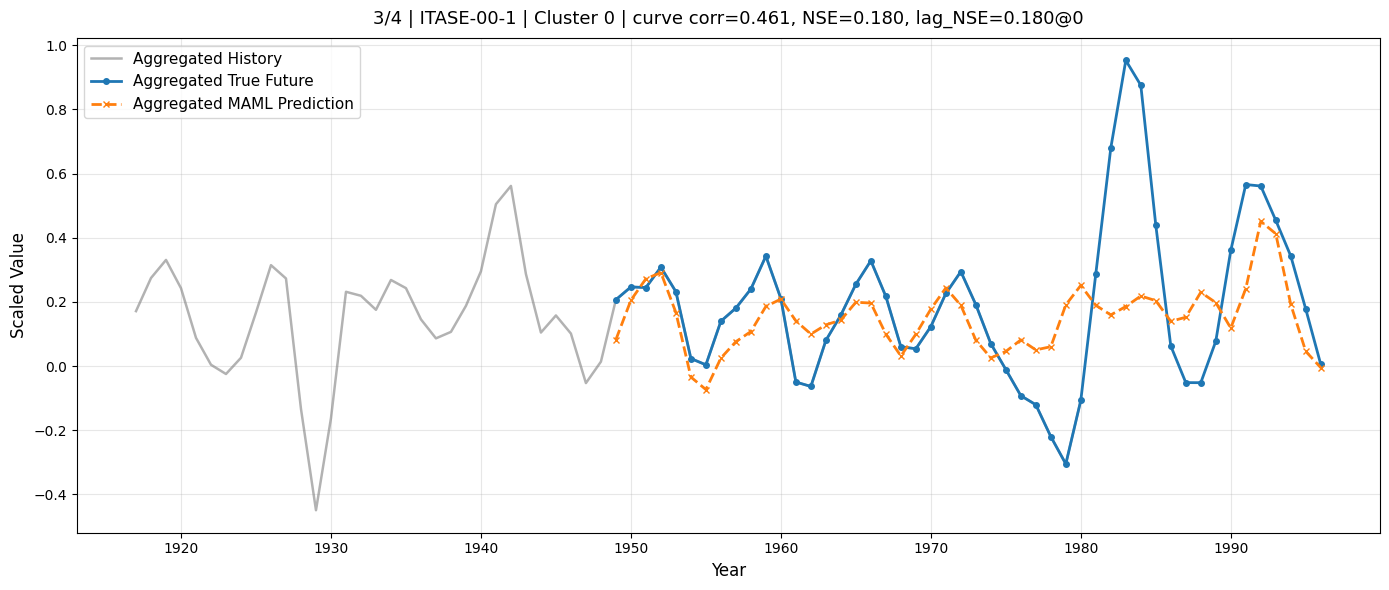

[WD05A 112.125W | window] N=528 | mse: 0.0069, mae: 0.0678 | corr: 0.6435 | corr_smooth_3: 0.6491 | lag_corr@±2: 0.6435, best_lag: 0 | NSE: 0.3798 | lag_NSE@±2: 0.3798, best_nse_lag: 0 | SMAPE(%): 110.31 | KS-D: 0.1610, KS-p: 2.178e-06
[WD05A 112.125W | curve] N=48 | mse: 0.0101, mae: 0.0810 | corr: 0.7072 | corr_smooth_3: 0.7181 | lag_corr@±2: 0.7072, best_lag: 0 | NSE: 0.4995 | lag_NSE@±2: 0.4995, best_nse_lag: 0 | SMAPE(%): 111.18 | KS-D: 0.1667, KS-p: 0.5221


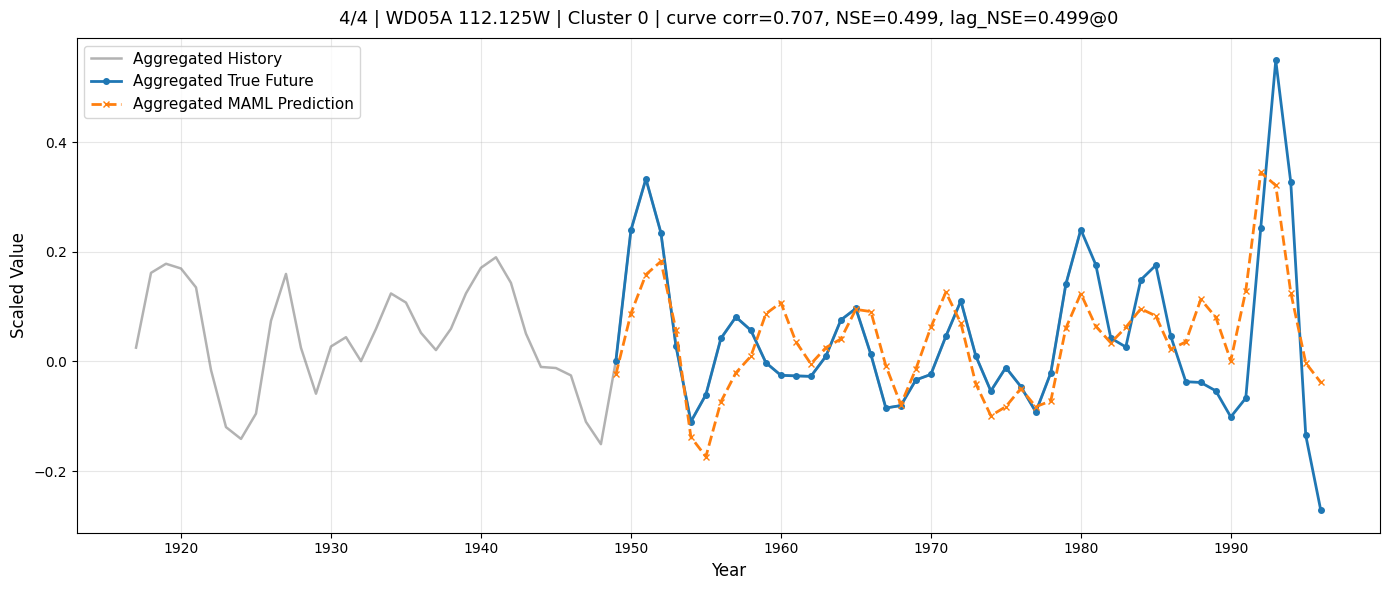


========== Summary over plotted single-variable sites ==========
sites plotted: 4
[overall test windows] N=7392 | mse: 0.0516, mae: 0.1452 | corr: 0.9534 | corr_smooth_3: 0.9676 | lag_corr@±2: 0.9534, best_lag: 0 | NSE: 0.9024 | lag_NSE@±2: 0.9024, best_nse_lag: 0 | SMAPE(%): 37.63 | KS-D: 0.0732, KS-p: 1.234e-17
[cluster 0 test windows] N=2112 | mse: 0.0954, mae: 0.2219 | corr: 0.6196 | corr_smooth_3: 0.6980 | lag_corr@±2: 0.6196, best_lag: 0 | NSE: 0.3422 | lag_NSE@±2: 0.3422, best_nse_lag: 0 | SMAPE(%): 88.98 | KS-D: 0.1510, KS-p: 1.997e-21
[cluster 0 aggregated curves] N=192 | mse: 0.0855, mae: 0.2106 | corr: 0.6499 | corr_smooth_3: 0.7097 | lag_corr@±2: 0.6511, best_lag: -1 | NSE: 0.3850 | lag_NSE@±2: 0.3901, best_nse_lag: -1 | SMAPE(%): 84.55 | KS-D: 0.1354, KS-p: 0.05905


{'scale': 'scaled',
 'overall_window': {'n': 7392,
  'mse': 0.0515647754073143,
  'mae': 0.14517705142498016,
  'corr': 0.9534235310055164,
  'corr_smooth_3': 0.96760218776572,
  'lag_corr': 0.9534235310055164,
  'best_lag': 0,
  'nse': 0.9024244009987432,
  'lag_nse': 0.9024244009987432,
  'best_nse_lag': 0,
  'smape': 37.63203048706055,
  'ks_stat': 0.07318722943722944,
  'ks_pvalue': 1.2337582496753165e-17},
 'cluster_window': {'n': 2112,
  'mse': 0.09541019797325134,
  'mae': 0.22190487384796143,
  'corr': 0.6196049751155377,
  'corr_smooth_3': 0.6980276859392298,
  'lag_corr': 0.6196049751155377,
  'best_lag': 0,
  'nse': 0.34216802544389735,
  'lag_nse': 0.34216802544389735,
  'best_nse_lag': 0,
  'smape': 88.97704315185547,
  'ks_stat': 0.15104166666666666,
  'ks_pvalue': 1.99727793521747e-21},
 'cluster_curve': {'n': 192,
  'mse': 0.08545718342065811,
  'mae': 0.21061937510967255,
  'corr': 0.649860667898878,
  'corr_smooth_3': 0.7097277218069914,
  'lag_corr': 0.65107798675899

In [3]:
# accum
visualise_icecore_s_with_history(
    npz_path=str(PROJECT_ROOT / "results/long_term_forecast_SEMPO_accum_s_protoprototypes/accum_s_encoder_site_pretrain_proto_k3.npz_ftS_sl32_ll16_pl16_pl16_dm256_nh2_el3_dl3_df128_fc1_ebtimeF_dtTrue_0/results.npz"),
    target_cluster=0,
    root_path=str(PROJECT_ROOT / "dataset/icecore/accum"),
    data_path="accum_100y.csv",
    cluster_result_path=str(PROJECT_ROOT / "cluster/accum/accum_100y_cluster_mapped.csv"),
    site_meta_path=str(PROJECT_ROOT / "dataset/icecore/data_sources.csv"),
    seq_len=32,
    label_len=16,
    pred_len=16,
    apply_pywt=True,
    residual_prediction=False,
    support_ratio=0.66,
    save_dir=None,
    show=True,
    inverse_transform_values=False,  
)


Scaled MSE:   0.074098
Scaled MAE:   0.162798
Physical MSE: 1904.154175
Physical MAE: 26.097433
Cluster 0: Samples=132  | Physical MSE=1488.228271 | Physical MAE=26.505301
Cluster 1: Samples=264  | Physical MSE=395.505615 | Physical MAE=14.134564
Cluster 2: Samples=66   | Physical MSE=8770.599609 | Physical MAE=73.133179


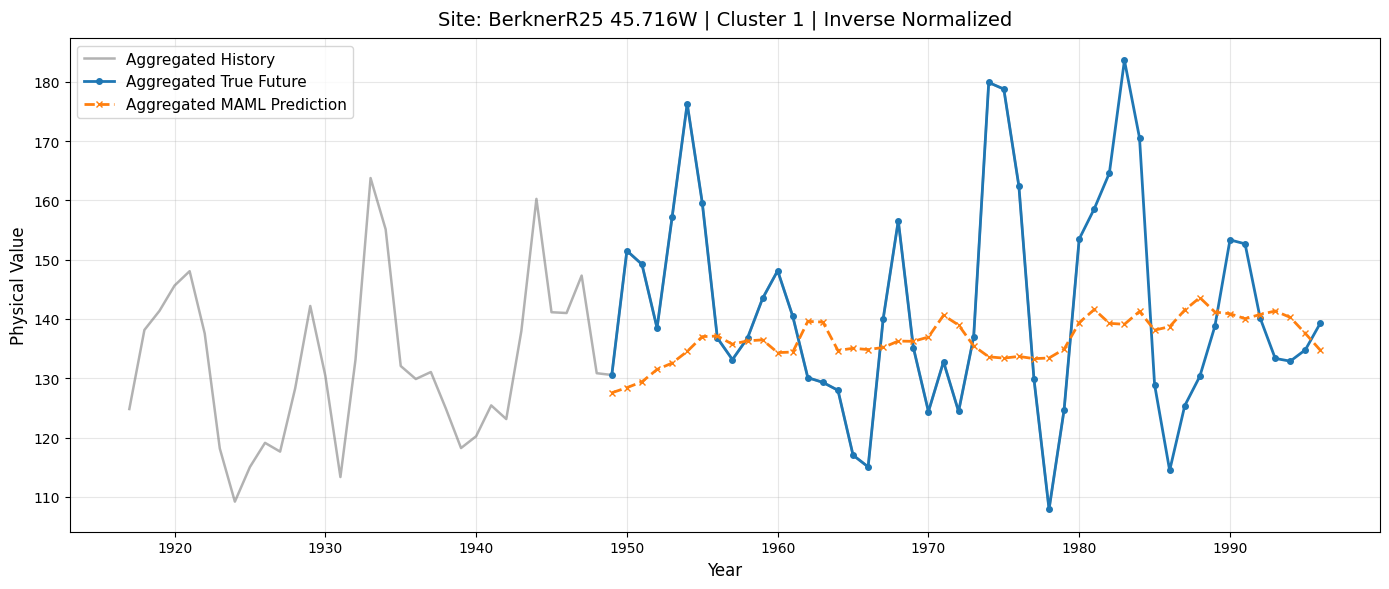

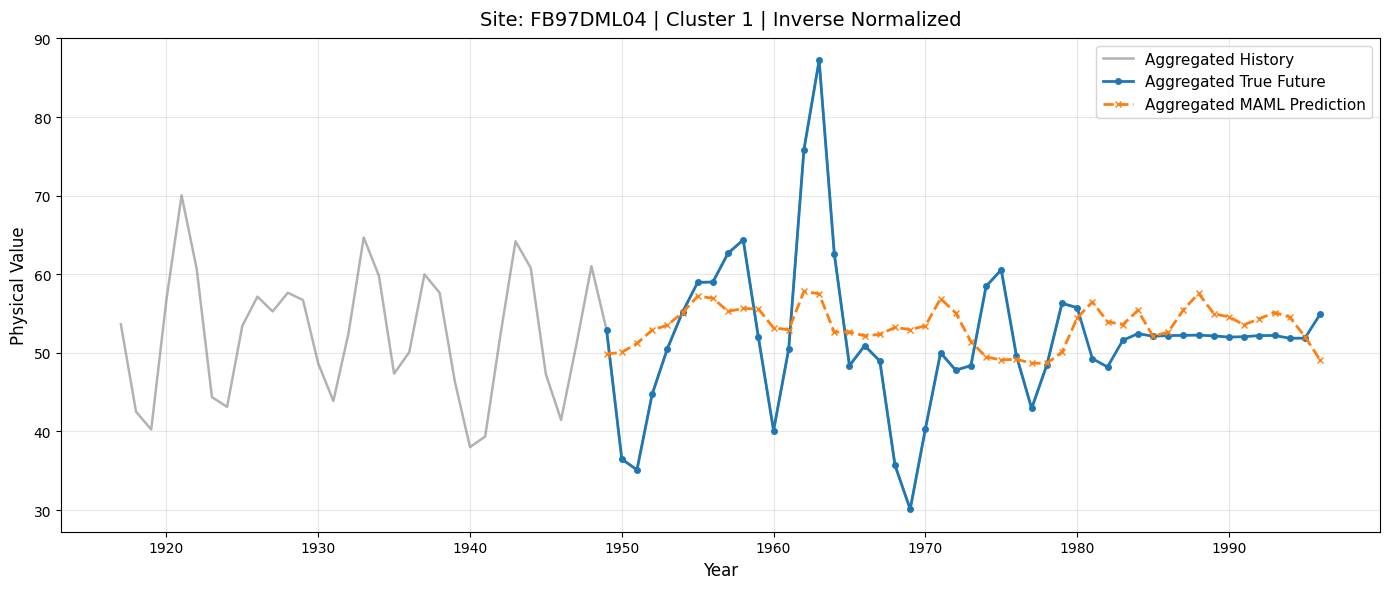

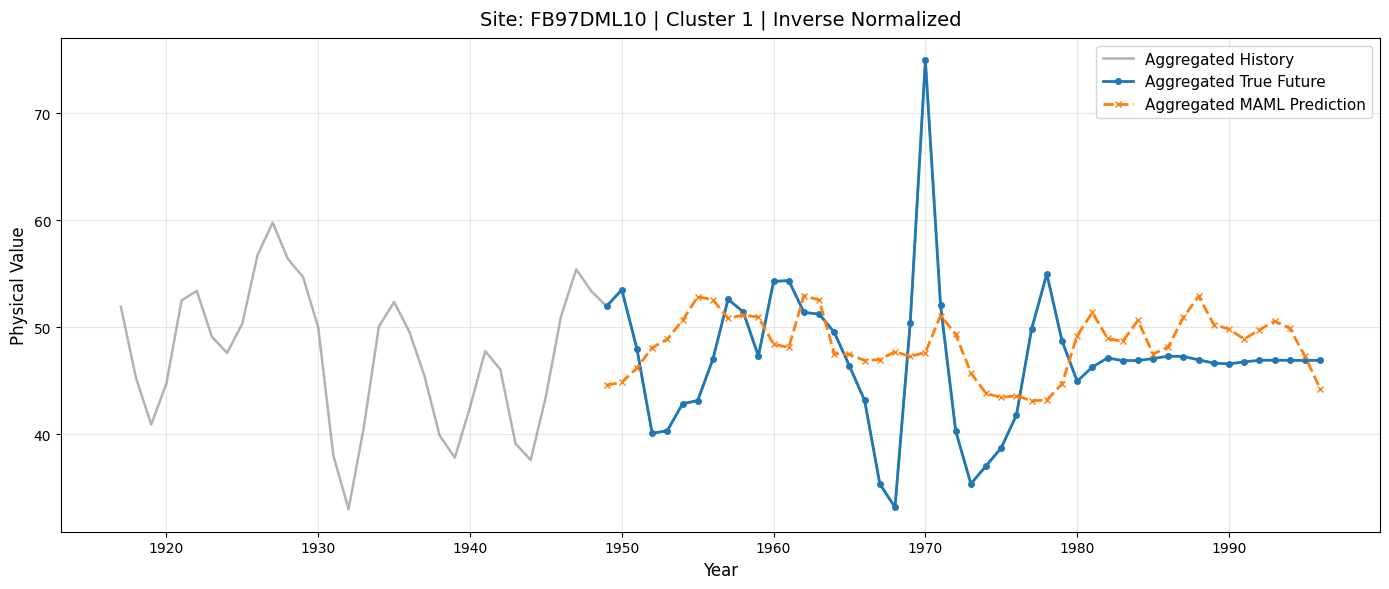

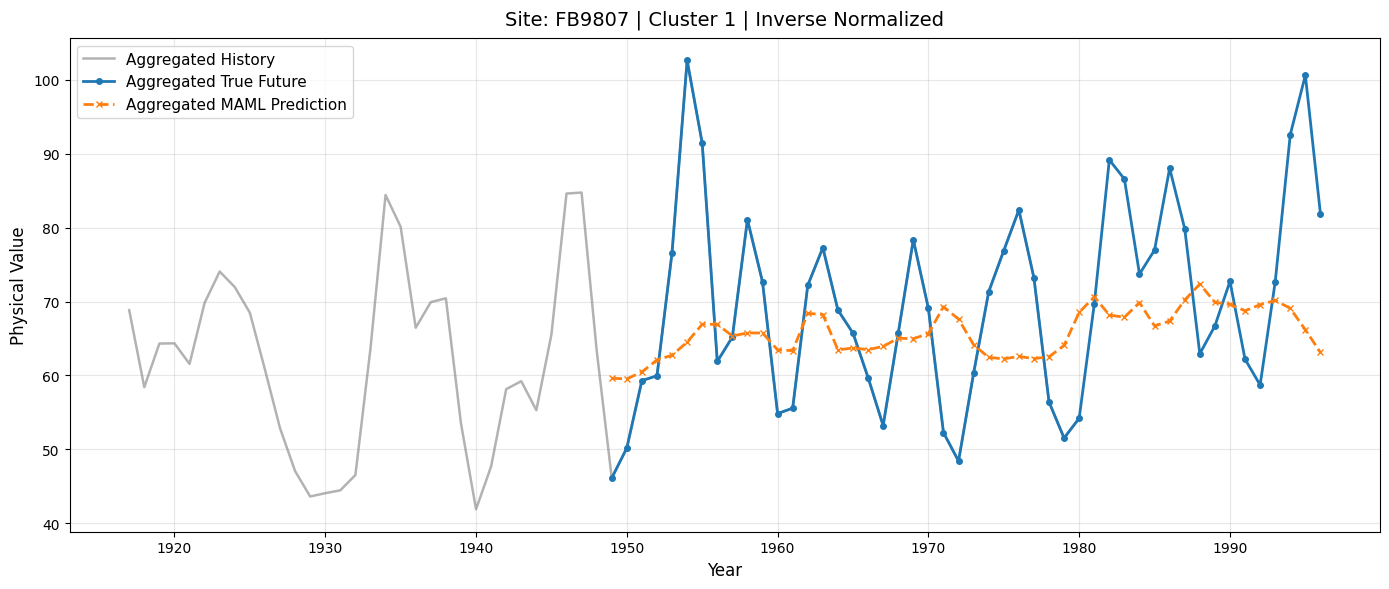

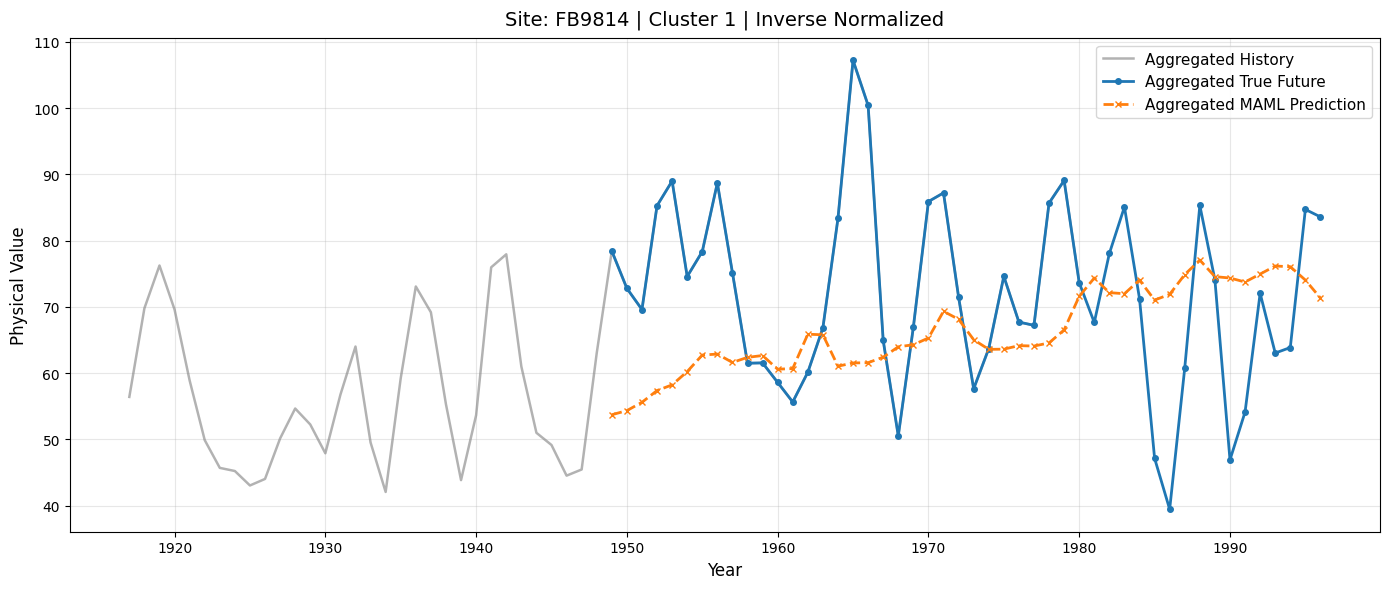

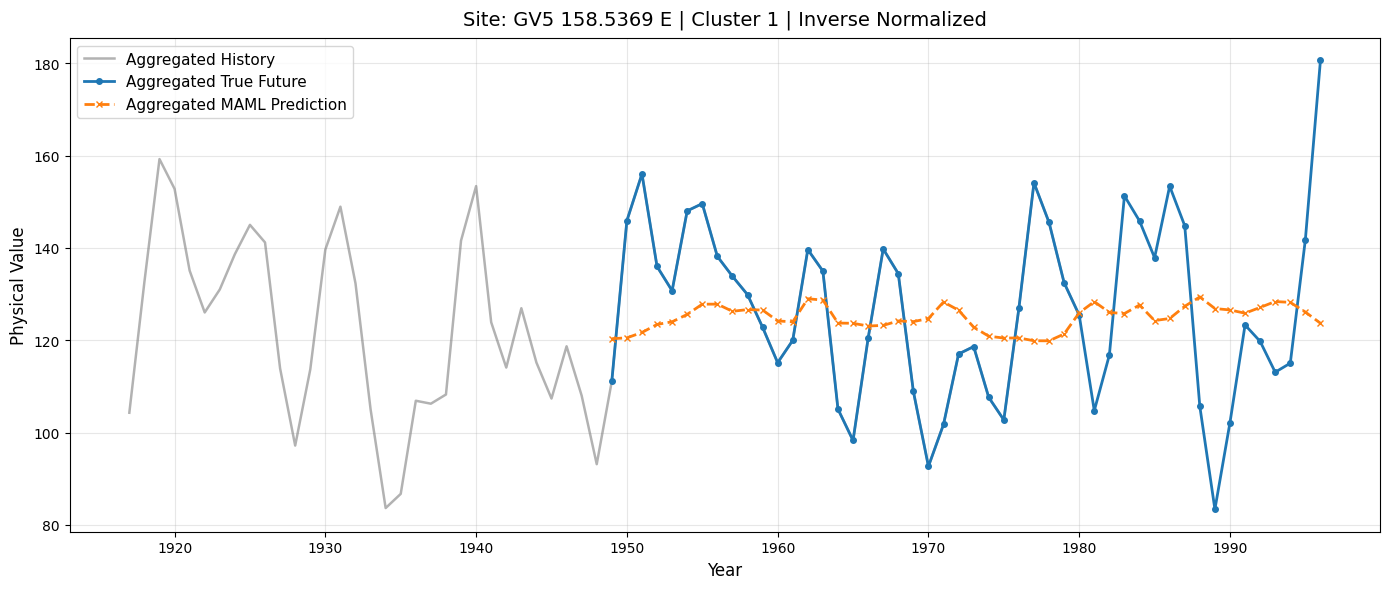

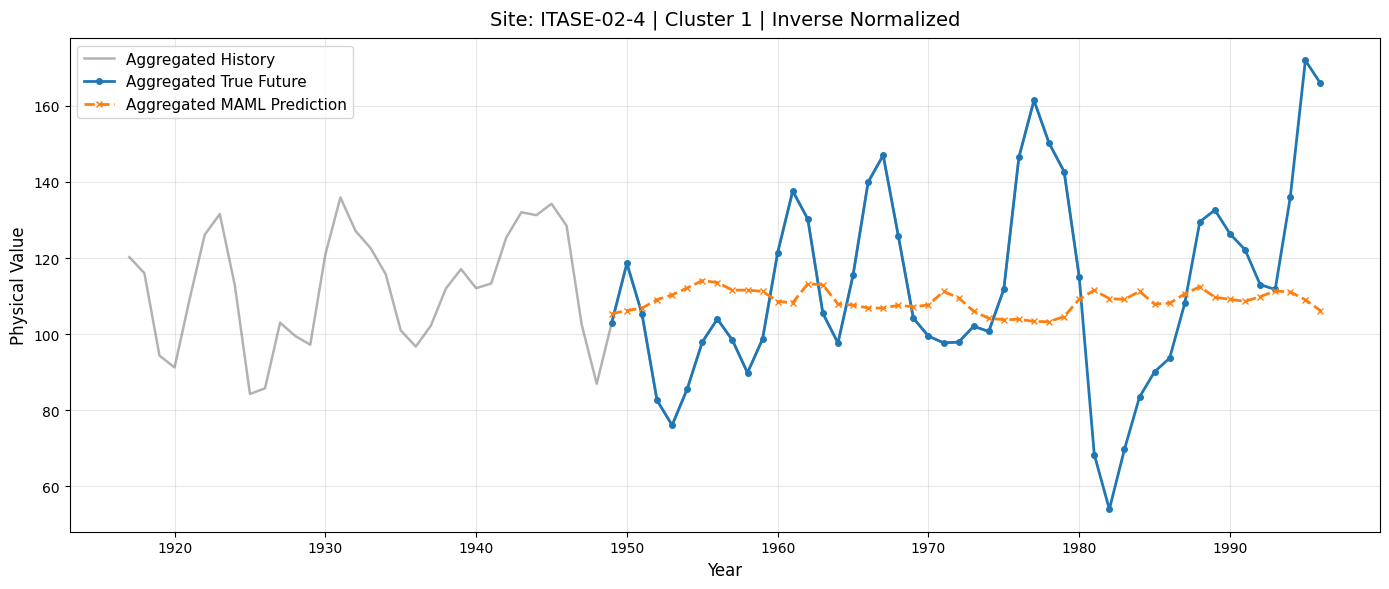

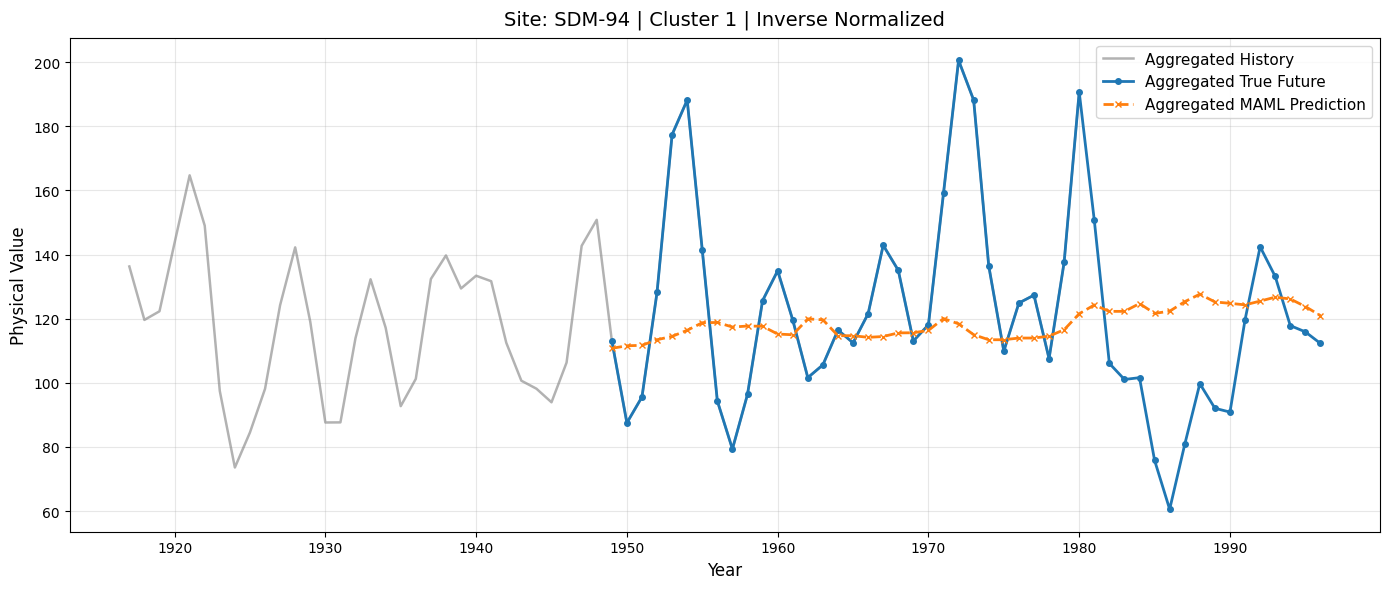

In [6]:
# accum
visualise_icecore_s_with_history(
    npz_path=str(PROJECT_ROOT / "results/long_term_forecast_SEMPO_accum_s_ftS_sl32_ll16_pl16_pl16_dm256_nh2_el3_dl3_df128_fc1_ebtimeF_dtTrue_0/results.npz"),
    target_cluster=1,
    root_path=str(PROJECT_ROOT / "dataset/icecore/accum"),
    data_path="accum_100y.csv",
    cluster_result_path=str(PROJECT_ROOT / "cluster/accum/accum_100y_cluster_mapped.csv"),
    site_meta_path=str(PROJECT_ROOT / "dataset/icecore/data_sources.csv"),
    seq_len=32,
    label_len=16,
    pred_len=16,
    apply_pywt=True,
    residual_prediction=False,
    support_ratio=0.66,
    save_dir=None,
    show=True,
)


Scaled MSE:   0.051670
Scaled MAE:   0.144894
Physical MSE: 1611.429443
Physical MAE: 25.588001
Cluster 0: Samples=132  | Physical MSE=3058.431396 | Physical MAE=39.804211
Cluster 1: Samples=264  | Physical MSE=288.608490 | Physical MAE=11.560992
Cluster 2: Samples=66   | Physical MSE=4008.708252 | Physical MAE=53.263611
Site FB96DML01 pre-aggregation window scaled metrics | mse=0.0010, mae=0.0260, corr=-0.1498, corr_smooth_3=-0.2377, a3_corr=-0.2527, trend_corr=-0.0124, direction_acc=50.3%, lag_corr@±2=0.2427, best_lag=2, PeakRecall@10%_±2=0.1970, PeakPrecision@10%_±2=0.1970, PeakF1@10%_±2=0.1970
Site FB96DML01 post-aggregation curve scaled metrics | mse=0.0009, mae=0.0243, corr=-0.1313, corr_smooth_3=-0.2325, a3_corr=-0.4176, trend_corr=0.0089, direction_acc=46.8%, lag_corr@±2=0.0601, best_lag=2, PeakRecall@10%_±2=0.0000, PeakPrecision@10%_±2=0.0000, PeakF1@10%_±2=0.0000


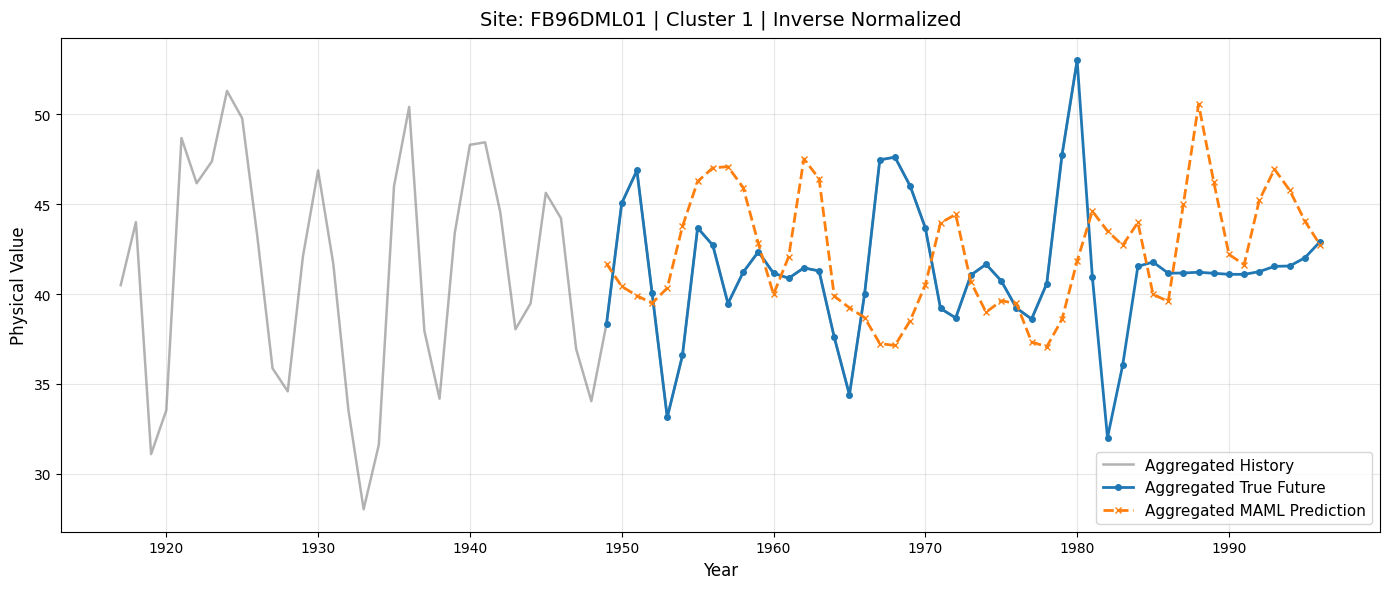

Site FB97DML06 pre-aggregation window scaled metrics | mse=0.0057, mae=0.0547, corr=0.1460, corr_smooth_3=0.2660, a3_corr=0.5430, trend_corr=-0.0696, direction_acc=54.7%, lag_corr@±2=0.4247, best_lag=-2, PeakRecall@10%_±2=0.3788, PeakPrecision@10%_±2=0.3788, PeakF1@10%_±2=0.3788
Site FB97DML06 post-aggregation curve scaled metrics | mse=0.0049, mae=0.0494, corr=0.0072, corr_smooth_3=0.0982, a3_corr=0.0280, trend_corr=-0.1985, direction_acc=51.1%, lag_corr@±2=0.2703, best_lag=-2, PeakRecall@10%_±2=0.4000, PeakPrecision@10%_±2=0.4000, PeakF1@10%_±2=0.4000


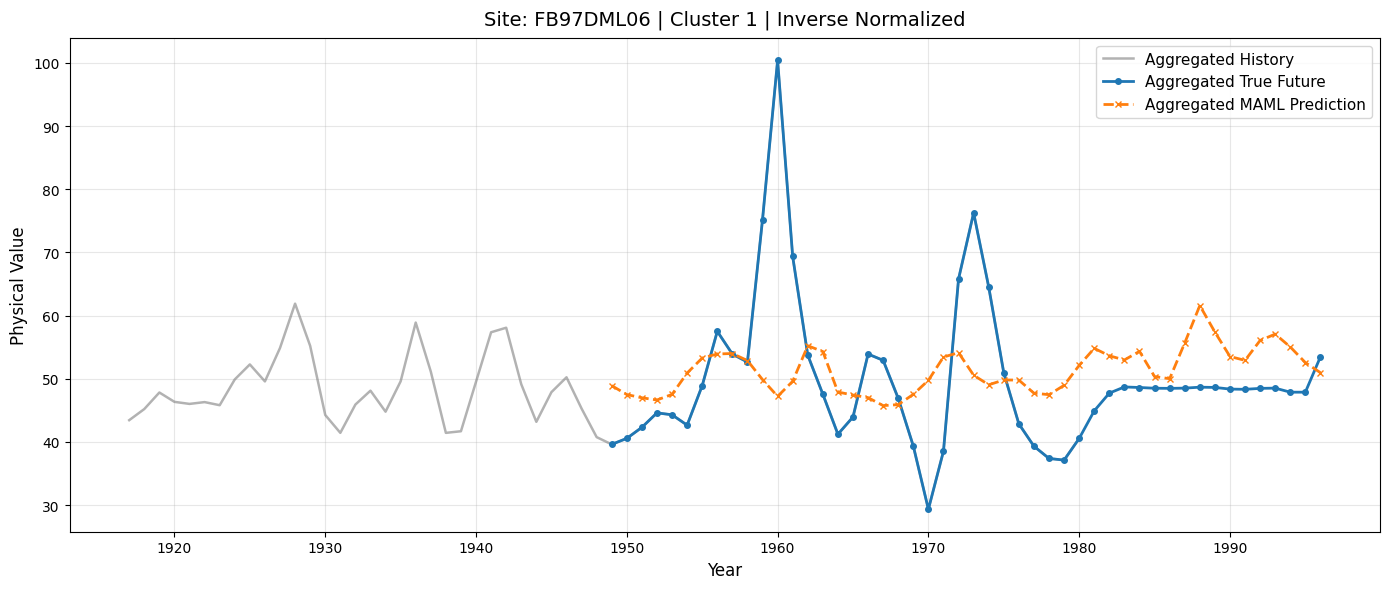

Site FB97DML09 pre-aggregation window scaled metrics | mse=0.0023, mae=0.0353, corr=-0.1335, corr_smooth_3=-0.1586, a3_corr=-0.2695, trend_corr=-0.0595, direction_acc=45.7%, lag_corr@±2=0.2514, best_lag=2, PeakRecall@10%_±2=0.3636, PeakPrecision@10%_±2=0.3636, PeakF1@10%_±2=0.3636
Site FB97DML09 post-aggregation curve scaled metrics | mse=0.0026, mae=0.0374, corr=-0.2864, corr_smooth_3=-0.3918, a3_corr=-0.6918, trend_corr=-0.0580, direction_acc=42.6%, lag_corr@±2=-0.0360, best_lag=2, PeakRecall@10%_±2=0.2000, PeakPrecision@10%_±2=0.2000, PeakF1@10%_±2=0.2000


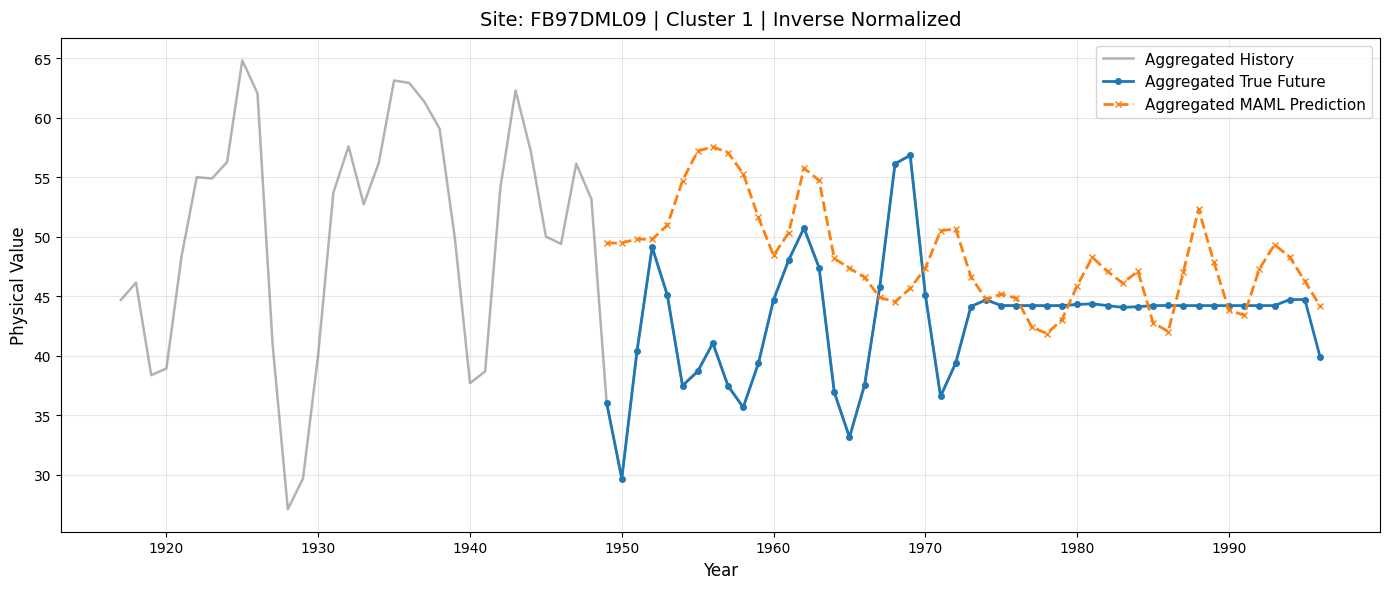

Site FB97DML10 pre-aggregation window scaled metrics | mse=0.0020, mae=0.0327, corr=0.0728, corr_smooth_3=0.1416, a3_corr=0.1549, trend_corr=-0.0667, direction_acc=56.2%, lag_corr@±2=0.2791, best_lag=2, PeakRecall@10%_±2=0.2727, PeakPrecision@10%_±2=0.2727, PeakF1@10%_±2=0.2727
Site FB97DML10 post-aggregation curve scaled metrics | mse=0.0016, mae=0.0313, corr=0.1277, corr_smooth_3=0.2014, a3_corr=0.4199, trend_corr=-0.0208, direction_acc=57.4%, lag_corr@±2=0.2286, best_lag=1, PeakRecall@10%_±2=0.0000, PeakPrecision@10%_±2=0.0000, PeakF1@10%_±2=0.0000


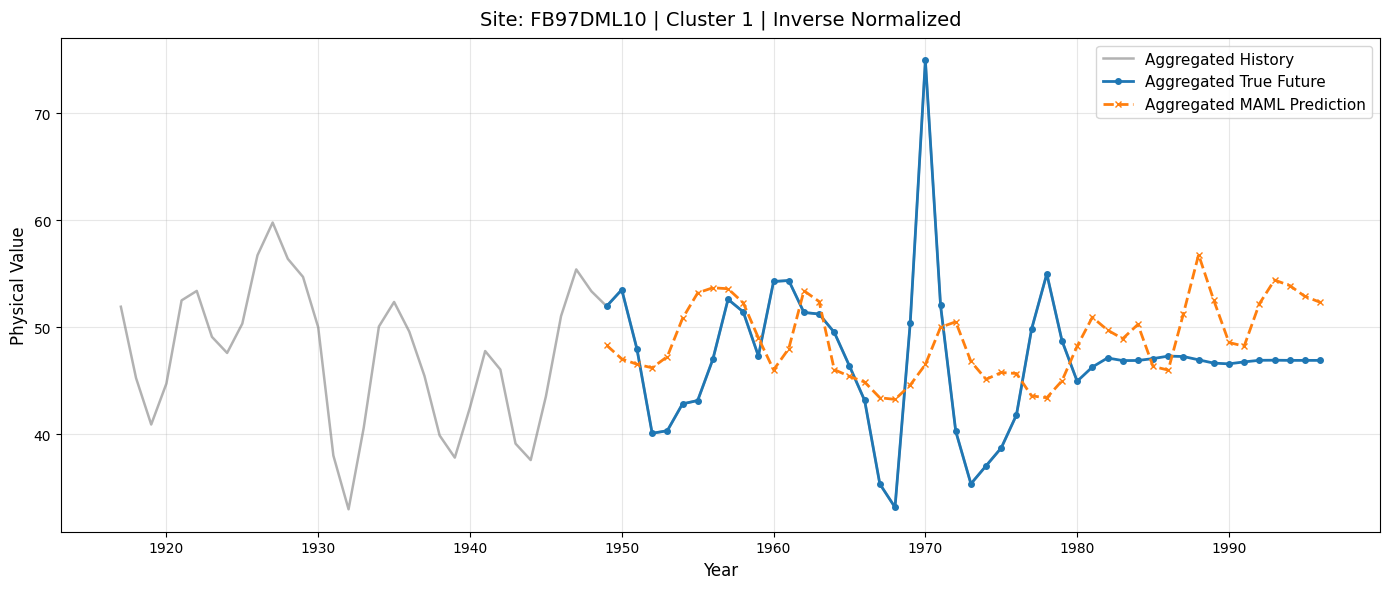

Site FB9802 pre-aggregation window scaled metrics | mse=0.0135, mae=0.0945, corr=0.0344, corr_smooth_3=-0.0862, a3_corr=0.0627, trend_corr=0.3788, direction_acc=56.8%, lag_corr@±2=0.0344, best_lag=0, PeakRecall@10%_±2=0.6515, PeakPrecision@10%_±2=0.6515, PeakF1@10%_±2=0.6515
Site FB9802 post-aggregation curve scaled metrics | mse=0.0149, mae=0.0993, corr=-0.1837, corr_smooth_3=-0.3121, a3_corr=-0.4673, trend_corr=0.4054, direction_acc=53.2%, lag_corr@±2=-0.1837, best_lag=0, PeakRecall@10%_±2=0.4000, PeakPrecision@10%_±2=0.4000, PeakF1@10%_±2=0.4000


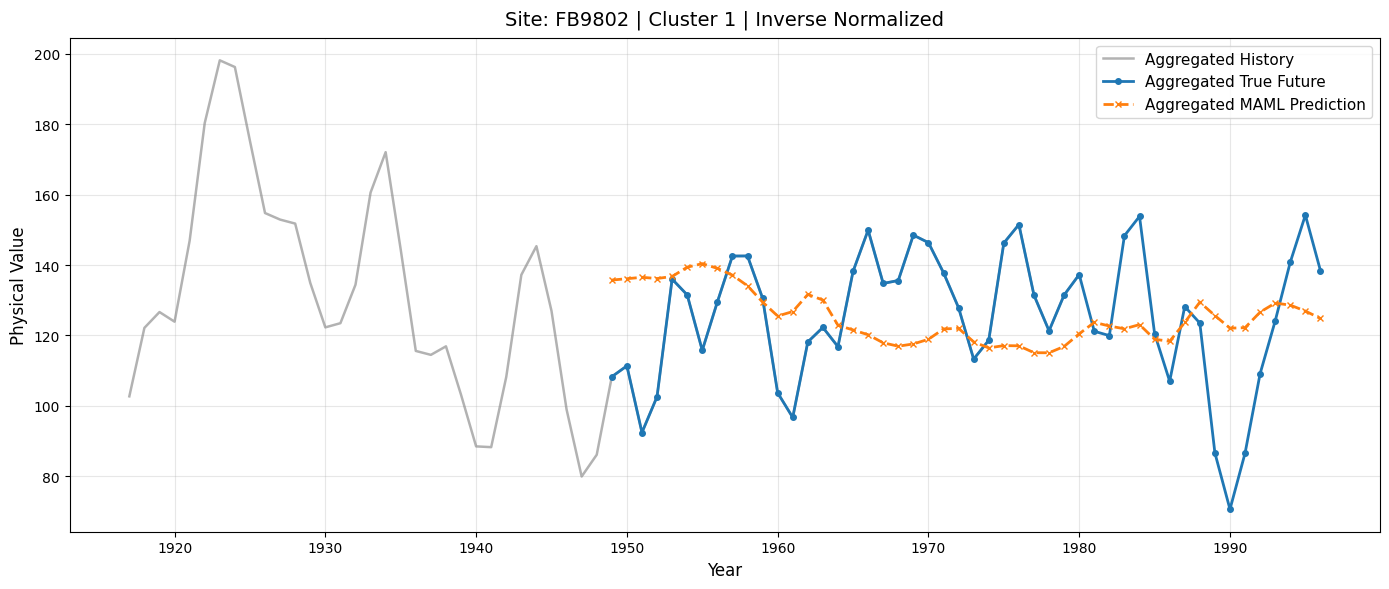

Site FB9813 pre-aggregation window scaled metrics | mse=0.0013, mae=0.0291, corr=-0.1401, corr_smooth_3=-0.2179, a3_corr=-0.1966, trend_corr=-0.0373, direction_acc=44.2%, lag_corr@±2=-0.0278, best_lag=-2, PeakRecall@10%_±2=0.2727, PeakPrecision@10%_±2=0.2727, PeakF1@10%_±2=0.2727
Site FB9813 post-aggregation curve scaled metrics | mse=0.0017, mae=0.0325, corr=-0.3530, corr_smooth_3=-0.5037, a3_corr=-0.6462, trend_corr=0.0841, direction_acc=44.7%, lag_corr@±2=-0.1704, best_lag=-2, PeakRecall@10%_±2=0.2000, PeakPrecision@10%_±2=0.2000, PeakF1@10%_±2=0.2000


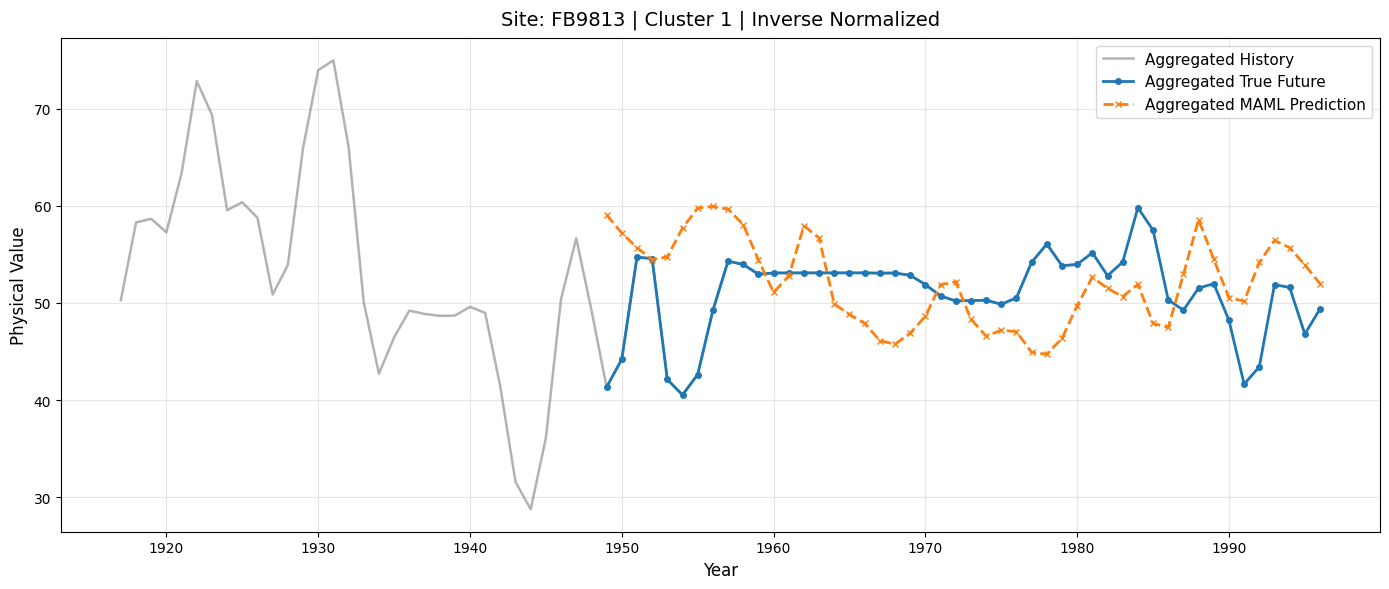

Site Hercules Neve 165.4 E pre-aggregation window scaled metrics | mse=0.0240, mae=0.1264, corr=0.0021, corr_smooth_3=0.0461, a3_corr=0.0249, trend_corr=-0.0641, direction_acc=52.7%, lag_corr@±2=0.1202, best_lag=2, PeakRecall@10%_±2=0.5455, PeakPrecision@10%_±2=0.5455, PeakF1@10%_±2=0.5455
Site Hercules Neve 165.4 E post-aggregation curve scaled metrics | mse=0.0251, mae=0.1345, corr=-0.2802, corr_smooth_3=-0.3266, a3_corr=-0.5599, trend_corr=-0.1859, direction_acc=48.9%, lag_corr@±2=-0.0574, best_lag=2, PeakRecall@10%_±2=0.2000, PeakPrecision@10%_±2=0.2000, PeakF1@10%_±2=0.2000


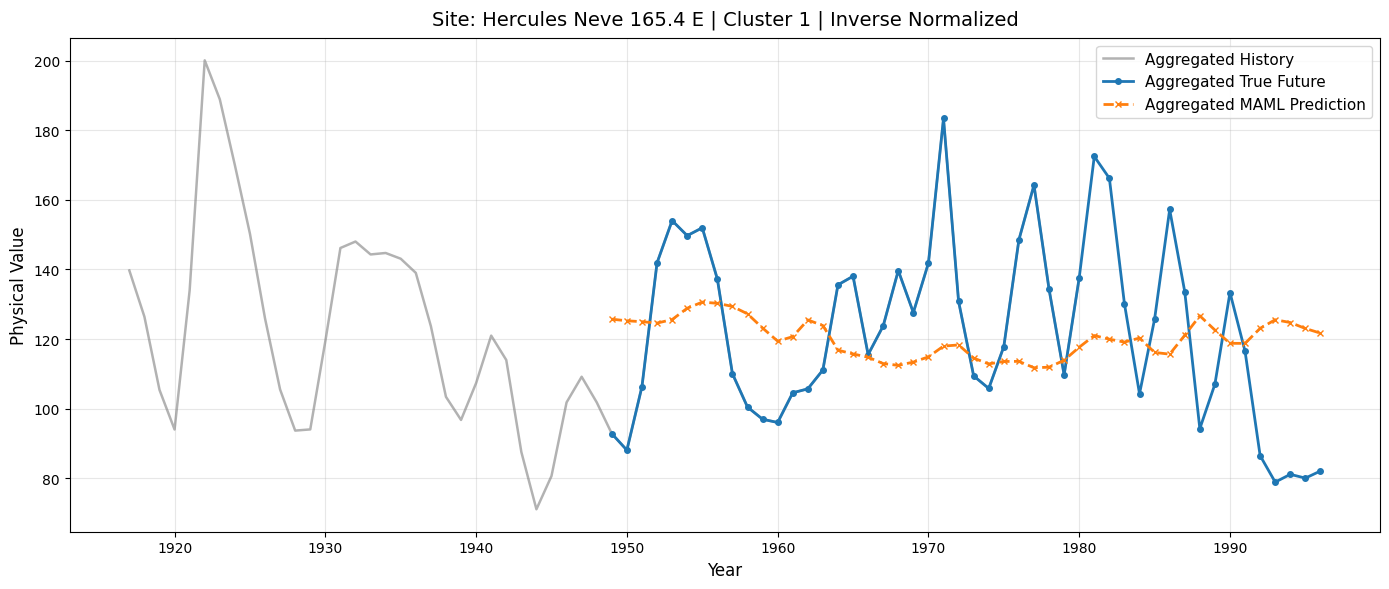

Site ITASE-02-4 pre-aggregation window scaled metrics | mse=0.0243, mae=0.1249, corr=-0.2835, corr_smooth_3=-0.3307, a3_corr=-0.3041, trend_corr=-0.1090, direction_acc=43.0%, lag_corr@±2=-0.1532, best_lag=2, PeakRecall@10%_±2=0.3788, PeakPrecision@10%_±2=0.3788, PeakF1@10%_±2=0.3788
Site ITASE-02-4 post-aggregation curve scaled metrics | mse=0.0257, mae=0.1267, corr=-0.4989, corr_smooth_3=-0.5814, a3_corr=-0.5319, trend_corr=-0.1333, direction_acc=46.8%, lag_corr@±2=-0.3315, best_lag=2, PeakRecall@10%_±2=0.2000, PeakPrecision@10%_±2=0.2000, PeakF1@10%_±2=0.2000


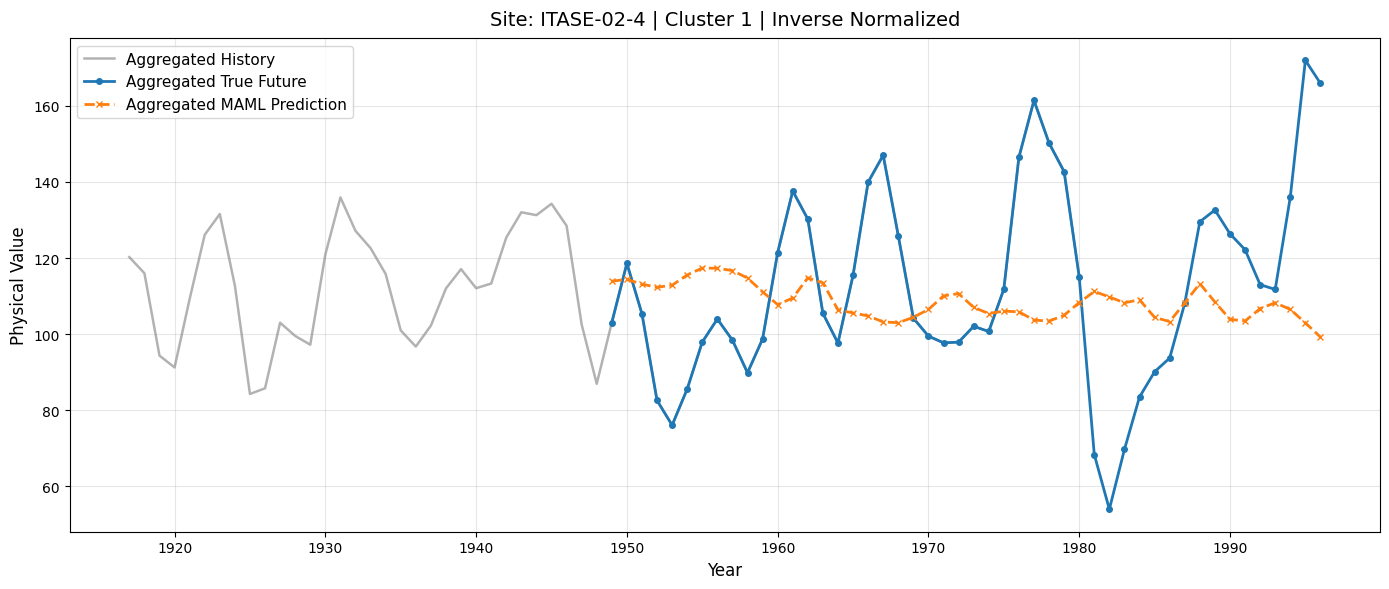

In [14]:
# accum
visualise_icecore_s_with_history(
    npz_path=str(PROJECT_ROOT / "results/long_term_forecast_SEMPO_accum_s_protoprototypes/accum_s_encoder_proto_k6.npz_ftS_sl32_ll16_pl16_pl16_dm256_nh2_el3_dl3_df128_fc1_ebtimeF_dtTrue_0/results.npz"),
    target_cluster=1,
    root_path=str(PROJECT_ROOT / "dataset/icecore/accum"),
    data_path="accum_100y.csv",
    cluster_result_path=str(PROJECT_ROOT / "cluster/accum/accum_100y_cluster_mapped.csv"),
    site_meta_path=str(PROJECT_ROOT / "dataset/icecore/data_sources.csv"),
    seq_len=32,
    label_len=16,
    pred_len=16,
    apply_pywt=True,
    residual_prediction=False,
    support_ratio=0.66,
    save_dir=None,
    show=True,
)


## CrossVar_pred


- crossvar / average / inverse_transform


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from data_provider.icecore_data_loader import Dataset_IceCore_CrossVar
from utils.metrics import (
    metric,
    pearson_corr,
    trend_corr,
    direction_accuracy,
    lag_aware_corr,
    smooth_corr,
    a3_corr,
    peak_event_metrics,
)
print("PROJECT_ROOT =", PROJECT_ROOT)

import numpy as np


def _to_str_array(arr):
    """
    把 npz 里保存的 sites 转成一维字符串数组。
    兼容 bytes / object / str。
    """
    arr = np.asarray(arr).reshape(-1)

    out = []
    for x in arr:
        if isinstance(x, bytes):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return np.asarray(out)




def _calc_prediction_metrics(pred_values, true_values):
    # 和 test() 使用同一套指标，输入保持为反归一化之前的值。
    # pred_values / true_values: [N, T] 或 [N, T, C]
    pred_values = np.asarray(pred_values)
    true_values = np.asarray(true_values)

    mae, mse, rmse, mape, mspe = metric(pred_values, true_values)
    corr = pearson_corr(pred_values, true_values)
    trend_corr_value = trend_corr(pred_values, true_values)
    direction_acc = direction_accuracy(pred_values, true_values)
    lag_corr, best_lag = lag_aware_corr(pred_values, true_values, max_lag=2)
    corr_smooth_3 = smooth_corr(pred_values, true_values, window=3)
    a3_corr_value = a3_corr(pred_values, true_values)
    peak_recall, peak_precision, peak_f1 = peak_event_metrics(
        pred_values,
        true_values,
        top_ratio=0.1,
        lag_window=2,
    )

    return {
        "mse": mse,
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "mspe": mspe,
        "corr": corr,
        "corr_smooth_3": corr_smooth_3,
        "a3_corr": a3_corr_value,
        "trend_corr": trend_corr_value,
        "direction_acc": direction_acc,
        "lag_corr": lag_corr,
        "best_lag": best_lag,
        "peak_recall_10_lag2": peak_recall,
        "peak_precision_10_lag2": peak_precision,
        "peak_f1_10_lag2": peak_f1,
    }


def _print_site_prediction_metrics(site_name, metrics, stage="metrics"):
    # 打印单个被绘制站点的指标，数值来自反归一化之前的 preds/trues。
    print(
        f"Site {site_name} {stage} | "
        f"mse={metrics['mse']:.4f}, mae={metrics['mae']:.4f}, "
        f"corr={metrics['corr']:.4f}, "
        f"corr_smooth_3={metrics['corr_smooth_3']:.4f}, "
        f"a3_corr={metrics['a3_corr']:.4f}, "
        f"trend_corr={metrics['trend_corr']:.4f}, "
        f"direction_acc={metrics['direction_acc'] * 100:.1f}%, "
        f"lag_corr@±2={metrics['lag_corr']:.4f}, "
        f"best_lag={metrics['best_lag']}, "
        f"PeakRecall@10%_±2={metrics['peak_recall_10_lag2']:.4f}, "
        f"PeakPrecision@10%_±2={metrics['peak_precision_10_lag2']:.4f}, "
        f"PeakF1@10%_±2={metrics['peak_f1_10_lag2']:.4f}"
    )

def _calc_mean_and_sort(agg_dict):
    """
    对 {year: [v1, v2, ...]} 按年份排序，并对同一年份的多个值取平均。

    Return:
        years: list[int]
        vals:  np.ndarray, shape [T]
    """
    if len(agg_dict) == 0:
        return [], np.array([])

    years = sorted(agg_dict.keys())
    vals = np.array(
        [np.nanmean(agg_dict[yr]) for yr in years],
        dtype=float
    )

    return years, vals


def _safe_inverse_transform_crossvar(dataset, values, var="y"):
    """
    CrossVar 可视化专用反归一化函数。

    参数:
        dataset: Dataset_IceCore_CrossVar 实例
        values: 一维数组/list，通常是聚合后的 input / true / pred
        var: "x" 或 "y"

    逻辑:
        1. 优先调用新版 dataset.inverse_transform(values, var="x"/"y")
        2. 如果旧版 Dataset 不支持 var 参数，则尝试 x_scaler / y_scaler
        3. 如果都失败，则返回原值，避免画图直接崩掉
    """
    values = np.asarray(values, dtype=float)

    if values.size == 0:
        return values

    original_shape = values.shape
    values_2d = values.reshape(-1, 1)

    # ---------------------------------------------------------
    # 1. 优先使用 Dataset 自带 inverse_transform
    # ---------------------------------------------------------
    if hasattr(dataset, "inverse_transform"):
        try:
            inv = dataset.inverse_transform(values_2d, var=var)
            return np.asarray(inv).reshape(original_shape)
        except TypeError:
            # 兼容旧版本：inverse_transform 不接受 var 参数
            try:
                inv = dataset.inverse_transform(values_2d)
                return np.asarray(inv).reshape(original_shape)
            except Exception:
                pass
        except Exception:
            pass

    # ---------------------------------------------------------
    # 2. 如果 Dataset 有 x_scaler / y_scaler，则手动反归一化
    # ---------------------------------------------------------
    scaler_attr_candidates = []

    if var == "x":
        scaler_attr_candidates = [
            "x_scaler",
            "scaler_x",
            "scaler",
        ]
    elif var == "y":
        scaler_attr_candidates = [
            "y_scaler",
            "scaler_y",
            "scaler",
        ]
    else:
        raise ValueError("var must be either 'x' or 'y'.")

    for attr in scaler_attr_candidates:
        if hasattr(dataset, attr):
            scaler = getattr(dataset, attr)

            if scaler is None:
                continue

            try:
                inv = scaler.inverse_transform(values_2d)
                return np.asarray(inv).reshape(original_shape)
            except Exception:
                continue

    # ---------------------------------------------------------
    # 3. 最后兜底：返回原值，避免画图中断
    # ---------------------------------------------------------
    print(
        f"⚠️ Warning: inverse_transform failed for var='{var}'. "
        "Return scaled values instead."
    )
    return values.reshape(original_shape)

def visualise_icecore_crossvar_with_history(
    npz_path,
    target_cluster,
    root_path,
    x_data_path,
    y_data_path,
    cluster_result_path,
    site_meta_path="dataset/icecore/data_sources.csv",
    seq_len=32,
    label_len=16,
    pred_len=32,
    apply_pywt=True,
    residual_prediction=False,
    support_ratio=0.66,
    filter_cid=None,
    x_label="Input variable",
    y_label="Target variable",
    show=True,
):
    """
    适配新版 Dataset_IceCore_CrossVar 的可视化函数。

    功能：
    1. 读取 results.npz 中的 preds / trues / inputs / sites / years / clusters
    2. 对同一站点、同一年份的多个预测样本求平均
    3. 输入变量 x 用 x_scaler 反归一化
    4. 目标变量 y 的 true / pred 用 y_scaler 反归一化
    5. 一张图上下两个子图：
       - 上图：输入变量 x
       - 下图：目标变量 y 的真实值和预测值
    6. 上下图年份对齐，共享 x 轴
    """

    # =========================================================
    # 1. 构造 Dataset_IceCore_CrossVar，用它的 x/y scaler 做 inverse_transform
    # =========================================================
    dataset = Dataset_IceCore_CrossVar(
        root_path=root_path,
        data_path=None,
        x_data_path=x_data_path,
        y_data_path=y_data_path,
        flag="train",
        size=[seq_len, label_len, pred_len],
        features="S",
        target="na",
        scale=True,
        timeenc=1,
        freq="y",
        percent=100,
        task_name="long_term_forecast",
        is_pretraining=0,
        apply_pywt=apply_pywt,
        site_meta_path=site_meta_path,
        cluster_result_path=cluster_result_path,
        residual_prediction=residual_prediction,
        support_ratio=support_ratio,
        filter_cid=filter_cid,
        verbose=False,
    )

    # =========================================================
    # 2. 读取 npz
    # =========================================================
    data = np.load(npz_path, allow_pickle=True)

    preds = data["preds"]       # expected: [N, seq_len, C] for CrossVar
    trues = data["trues"]       # expected: [N, seq_len, C] for CrossVar
    sites = _to_str_array(data["sites"])
    years = data["years"]
    clusters = np.asarray(data["clusters"]).reshape(-1)

    has_inputs = "inputs" in data
    inputs = data["inputs"] if has_inputs else None

    # =========================================================
    # 3. 打印 scaled 指标和反归一化后的目标变量指标
    # =========================================================
    scaled_mse = np.mean((preds - trues) ** 2)
    scaled_mae = np.mean(np.abs(preds - trues))

    preds_flat = preds[:, :, -1].reshape(-1, 1)
    trues_flat = trues[:, :, -1].reshape(-1, 1)

    preds_inv = dataset.inverse_transform(preds_flat, var="y")
    trues_inv = dataset.inverse_transform(trues_flat, var="y")

    physical_mse = np.mean((preds_inv - trues_inv) ** 2)
    physical_mae = np.mean(np.abs(preds_inv - trues_inv))

    print("=" * 60)
    print(f"CrossVar: {x_data_path} -> {y_data_path}")
    print(f"Scaled MSE:   {scaled_mse:.6f}")
    print(f"Scaled MAE:   {scaled_mae:.6f}")
    print(f"Physical MSE: {physical_mse:.6f}")
    print(f"Physical MAE: {physical_mae:.6f}")
    print("=" * 60)

    for cid in sorted(np.unique(clusters)):
        mask = clusters == cid
        if not np.any(mask):
            continue

        c_preds = preds[mask, :, -1].reshape(-1, 1)
        c_trues = trues[mask, :, -1].reshape(-1, 1)

        c_preds_inv = dataset.inverse_transform(c_preds, var="y")
        c_trues_inv = dataset.inverse_transform(c_trues, var="y")

        c_mse = np.mean((c_preds_inv - c_trues_inv) ** 2)
        c_mae = np.mean(np.abs(c_preds_inv - c_trues_inv))

        print(
            f"Cluster {cid}: "
            f"Samples={np.sum(mask):<4} | "
            f"Physical MSE={c_mse:.6f} | "
            f"Physical MAE={c_mae:.6f}"
        )

    print("=" * 60)

    # =========================================================
    # 4. 筛选目标 cluster
    # =========================================================
    target_indices = np.where(clusters == target_cluster)[0]

    if len(target_indices) == 0:
        print(f"❌ 未找到 Cluster {target_cluster} 的数据。")
        return

    unique_sites = np.unique(sites[target_indices])

    # =========================================================
    # 5. 按站点聚合：同一年份多个样本求平均
    # =========================================================
    for site_name in unique_sites:
        site_mask = (sites == site_name) & (clusters == target_cluster)
        site_idx_list = np.where(site_mask)[0]

        agg_inputs = defaultdict(list)
        agg_trues = defaultdict(list)
        agg_preds = defaultdict(list)

        site_metrics = _calc_prediction_metrics(
            preds[site_idx_list, :, -1],
            trues[site_idx_list, :, -1],
        )
        _print_site_prediction_metrics(
            site_name,
            site_metrics,
            stage="pre-aggregation window scaled metrics",
        )


        for idx in site_idx_list:
            # -------------------------------------------------
            # 5.1 解析年份
            # -------------------------------------------------
            year_item = years[idx]
            year_arr = np.asarray(year_item).reshape(-1)

            # CrossVar 可能保存：
            # A. 完整年份序列: [year_1, year_2, ..., year_seq_len]
            # B. 起始年份 scalar: year_start
            if len(year_arr) > 1:
                cur_years = year_arr.astype(int)
            else:
                start_year = int(year_arr[0])
                cur_years = np.arange(start_year, start_year + trues.shape[1])

            # -------------------------------------------------
            # 5.2 聚合输入变量 x
            # -------------------------------------------------
            if has_inputs:
                input_seq = inputs[idx, :, -1]
                usable_input_len = min(len(cur_years), len(input_seq))

                for j in range(usable_input_len):
                    yr = int(cur_years[j])
                    agg_inputs[yr].append(float(input_seq[j]))

            # -------------------------------------------------
            # 5.3 聚合目标变量 y 的真值和预测值
            # -------------------------------------------------
            y_true_seq = trues[idx, :, -1]
            y_pred_seq = preds[idx, :, -1]

            usable_len = min(len(cur_years), len(y_true_seq), len(y_pred_seq))

            for j in range(usable_len):
                yr = int(cur_years[j])
                agg_trues[yr].append(float(y_true_seq[j]))
                agg_preds[yr].append(float(y_pred_seq[j]))

        # =====================================================
        # 6. 同一年份样本求平均
        # =====================================================
        input_years, input_vals = _calc_mean_and_sort(agg_inputs)
        true_years, true_vals = _calc_mean_and_sort(agg_trues)
        pred_years, pred_vals = _calc_mean_and_sort(agg_preds)

        post_agg_metrics = _calc_prediction_metrics(
            np.asarray(pred_vals, dtype=np.float32)[None, :],
            np.asarray(true_vals, dtype=np.float32)[None, :],
        )
        _print_site_prediction_metrics(
            site_name,
            post_agg_metrics,
            stage="post-aggregation curve scaled metrics",
        )

        # =====================================================
        # 7. 反归一化
        # =====================================================
        input_vals_inv = _safe_inverse_transform_crossvar(
            dataset,
            input_vals,
            var="x"
        )

        true_vals_inv = _safe_inverse_transform_crossvar(
            dataset,
            true_vals,
            var="y"
        )

        pred_vals_inv = _safe_inverse_transform_crossvar(
            dataset,
            pred_vals,
            var="y"
        )

        # =====================================================
        # 8. 年份对齐：统一 x 轴范围和 ticks
        # =====================================================
        all_years = sorted(
            set(input_years)
            | set(true_years)
            | set(pred_years)
        )

        if len(all_years) == 0:
            print(f"⚠️ Site {site_name} 没有可画的年份数据。")
            continue

        x_min, x_max = min(all_years), max(all_years)

        # 年份太密时少显示一些 tick，避免堆在一起
        if len(all_years) > 20:
            step = max(1, len(all_years) // 10)
            tick_years = all_years[::step]
            if all_years[-1] not in tick_years:
                tick_years.append(all_years[-1])
        else:
            tick_years = all_years

        # =====================================================
        # 9. 一张图，上下两个子图
        # =====================================================
        fig, axes = plt.subplots(
            2,
            1,
            figsize=(14, 8),
            sharex=True,
            gridspec_kw={"height_ratios": [1, 1.25]}
        )

        ax_input = axes[0]
        ax_target = axes[1]

        # -------------------------
        # 上图：输入变量 x
        # -------------------------
        if has_inputs and len(input_years) > 0:
            ax_input.plot(
                input_years,
                input_vals_inv,
                label=f"{x_label} input",
                color="gray",
                linestyle="-",
                marker=".",
                markersize=4,
                alpha=0.8,
                linewidth=1.8,
            )
        else:
            ax_input.text(
                0.5,
                0.5,
                "No input sequence found in npz",
                ha="center",
                va="center",
                transform=ax_input.transAxes,
                fontsize=11,
            )

        ax_input.set_xlim(x_min, x_max)
        ax_input.set_ylabel(x_label, fontsize=11)
        ax_input.set_title(
            f"Site: {site_name} | Cluster {target_cluster} | CrossVar: {x_label} → {y_label}",
            fontsize=14,
            pad=10,
        )
        ax_input.legend(loc="best", fontsize=10)
        ax_input.grid(True, alpha=0.3)

        # -------------------------
        # 下图：目标变量 y true / pred
        # -------------------------
        ax_target.plot(
            true_years,
            true_vals_inv,
            label=f"True {y_label}",
            color="#1f77b4",
            marker="o",
            markersize=4,
            linewidth=2,
        )

        ax_target.plot(
            pred_years,
            pred_vals_inv,
            label=f"Predicted {y_label}",
            color="#ff7f0e",
            linestyle="--",
            marker="x",
            markersize=5,
            linewidth=2,
        )

        ax_target.set_xlim(x_min, x_max)
        ax_target.set_xlabel("Year", fontsize=12)
        ax_target.set_ylabel(y_label, fontsize=11)
        ax_target.legend(loc="best", fontsize=10)
        ax_target.grid(True, alpha=0.3)

        ax_target.set_xticks(tick_years)
        ax_target.set_xticklabels(tick_years, rotation=45)

        plt.tight_layout()

        if show:
            plt.show()
        else:
            plt.close()


PROJECT_ROOT = /sharedata/home/cyyang/SEMPO_copy0707


CrossVar: d18O/d18O_clean.csv -> accum/accum_100y.csv
Scaled MSE:   0.404853
Scaled MAE:   0.585645
Physical MSE: 19299.238281
Physical MAE: 127.866325
Cluster 0: Samples=3    | Physical MSE=18761.078125 | Physical MAE=123.657684
Cluster 1: Samples=6    | Physical MSE=19430.380859 | Physical MAE=134.122421
Cluster 2: Samples=3    | Physical MSE=19575.111328 | Physical MAE=119.562767
Site ITASE-00-1 pre-aggregation window scaled metrics | mse=0.3936, mae=0.5664, corr=-0.3832, corr_smooth_3=-0.3668, a3_corr=-0.2316, trend_corr=-0.4246, direction_acc=36.6%, lag_corr@±2=0.1056, best_lag=-2, PeakRecall@10%_±2=0.2500, PeakPrecision@10%_±2=0.2500, PeakF1@10%_±2=0.2500
Site ITASE-00-1 post-aggregation curve scaled metrics | mse=0.3801, mae=0.5570, corr=-0.3837, corr_smooth_3=-0.3644, a3_corr=-0.2694, trend_corr=-0.4407, direction_acc=30.3%, lag_corr@±2=0.1057, best_lag=-2, PeakRecall@10%_±2=0.2500, PeakPrecision@10%_±2=0.2500, PeakF1@10%_±2=0.2500


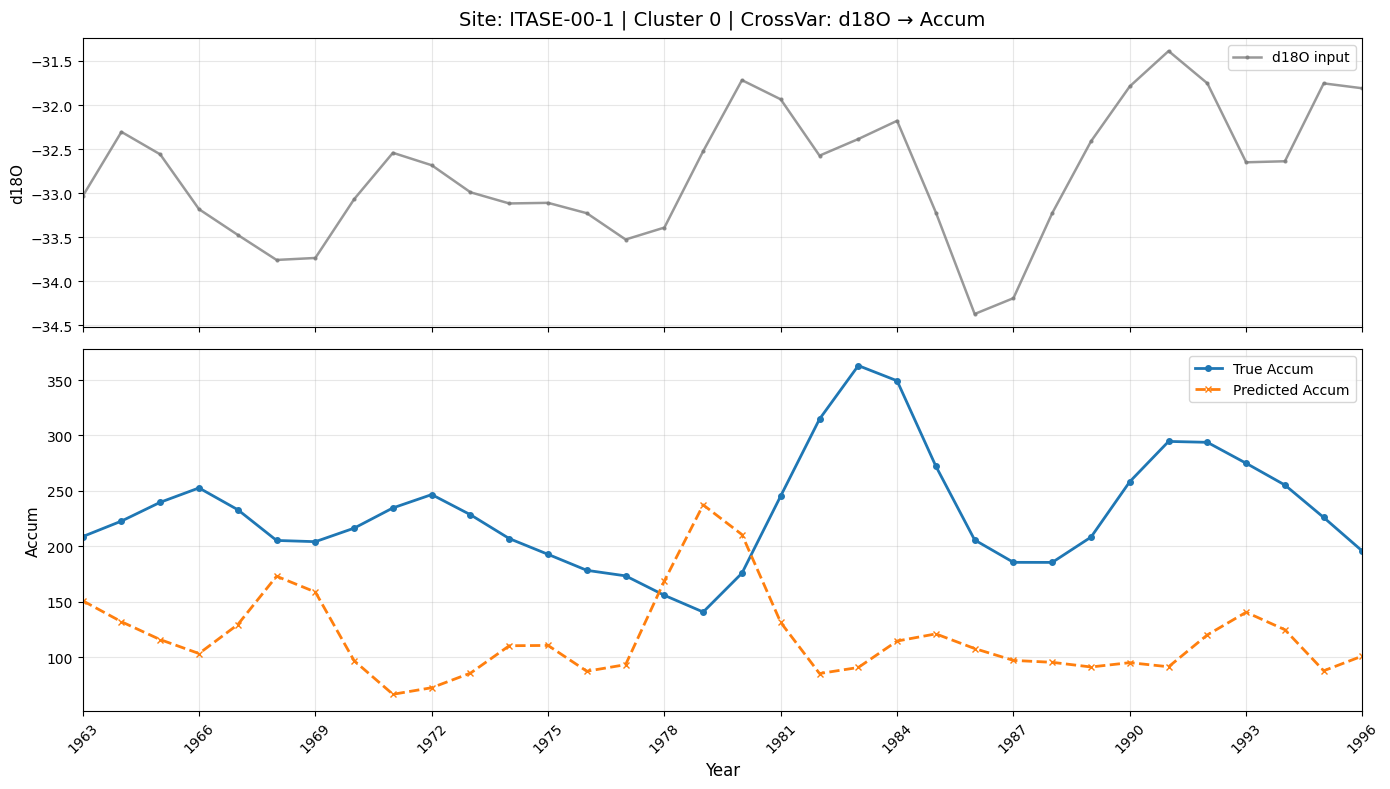

In [19]:
visualise_icecore_crossvar_with_history(
    npz_path=str(PROJECT_ROOT / "results/long_term_forecast_SEMPO_d18O_accum_crossvar_ftM_sl32_ll48_pl32_pl16_dm256_nh2_el3_dl3_df128_fc1_ebtimeF_dtTrue_0/results.npz"),
    target_cluster=0,
    root_path=str(PROJECT_ROOT / "dataset/icecore"),
    x_data_path="d18O/d18O_clean.csv",
    y_data_path="accum/accum_100y.csv",
    cluster_result_path=str(PROJECT_ROOT / "cluster/accum/accum_100y_cluster_mapped.csv"),
    site_meta_path=str(PROJECT_ROOT / "dataset/icecore/data_sources.csv"),
    seq_len=32,
    label_len=16,
    pred_len=32,
    apply_pywt=True,
    residual_prediction=True,
    support_ratio=0.66,
    x_label="d18O",
    y_label="Accum",
    show=True,
)


CrossVar: d18O/d18O_clean.csv -> accum/accum_100y.csv
Scaled MSE:   0.393532
Scaled MAE:   0.576805
Physical MSE: 18759.611328
Physical MAE: 125.936310
Cluster 0: Samples=3    | Physical MSE=17952.708984 | Physical MAE=121.030403
Cluster 1: Samples=6    | Physical MSE=18582.462891 | Physical MAE=131.091751
Cluster 2: Samples=3    | Physical MSE=19920.806641 | Physical MAE=120.531342
Site ITASE-01-2 pre-aggregation window scaled metrics | mse=0.4179, mae=0.5520, corr=0.3522, corr_smooth_3=0.4566, a3_corr=0.6600, trend_corr=0.0393, direction_acc=51.6%, lag_corr@±2=0.5088, best_lag=-2, PeakRecall@10%_±2=0.5833, PeakPrecision@10%_±2=0.5833, PeakF1@10%_±2=0.5833
Site ITASE-01-2 post-aggregation curve scaled metrics | mse=0.4111, mae=0.5495, corr=0.3444, corr_smooth_3=0.4474, a3_corr=0.6749, trend_corr=0.0172, direction_acc=51.5%, lag_corr@±2=0.4928, best_lag=-2, PeakRecall@10%_±2=0.5000, PeakPrecision@10%_±2=0.5000, PeakF1@10%_±2=0.5000


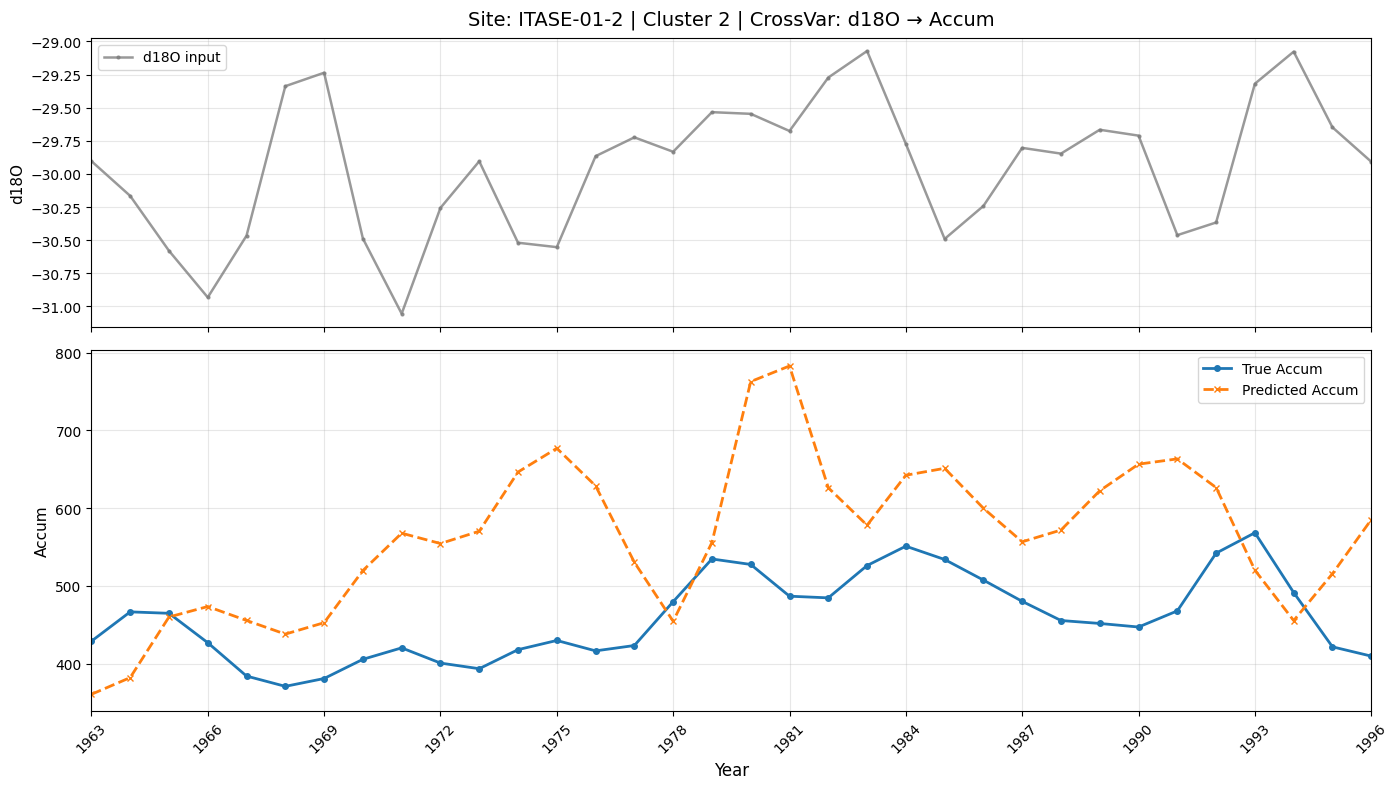

In [22]:
visualise_icecore_crossvar_with_history(
    npz_path=str(PROJECT_ROOT / "results/long_term_forecast_SEMPO_d18O_accum_crossvar_protoprototypes/d18O_accum_crossvar_encoder_proto_k6.npz_ftM_sl32_ll48_pl32_pl16_dm256_nh2_el3_dl3_df128_fc1_ebtimeF_dtTrue_0/results.npz"),
    target_cluster=2,
    root_path=str(PROJECT_ROOT / "dataset/icecore"),
    x_data_path="d18O/d18O_clean.csv",
    y_data_path="accum/accum_100y.csv",
    cluster_result_path=str(PROJECT_ROOT / "cluster/accum/accum_100y_cluster_mapped.csv"),
    site_meta_path=str(PROJECT_ROOT / "dataset/icecore/data_sources.csv"),
    seq_len=32,
    label_len=16,
    pred_len=32,
    apply_pywt=True,
    residual_prediction=True,
    support_ratio=0.66,
    x_label="d18O",
    y_label="Accum",
    show=True,
)


## CrossVar_full


In [3]:
import os
import re
import csv
import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy import stats
except Exception:
    stats = None


# ====== 只需要改这里 ======
npz_path = "results/你的setting/results.npz"
save_dir = "vis_prediction_all_test_sites"
show_fig = False   # True: 每个站点都在 notebook 里显示；False: 只保存图片
inverse_transform_values = False  # True: 反归一化后计算指标和画图
# =========================


def _safe_filename(name):
    name = str(name)
    name = re.sub(r"[^\w\-.]+", "_", name)
    return name.strip("_") or "site"


def _squeeze_target_array(arr, name):
    arr = np.asarray(arr)
    if arr.ndim == 3 and arr.shape[-1] == 1:
        return arr[..., 0]
    if arr.ndim == 2:
        return arr
    raise ValueError(f"{name} 应为 [N, T] 或 [N, T, 1]，实际 {arr.shape}")


def _as_1d_float(arr):
    arr = np.asarray(arr, dtype=np.float32)
    if arr.ndim == 2 and arr.shape[-1] == 1:
        arr = arr[:, 0]
    return arr.reshape(-1)


def _npz_scalar_str(data, key, default=None):
    if key not in data:
        return default
    val = data[key]
    if isinstance(val, np.ndarray):
        if val.shape == ():
            val = val.item()
        elif val.size == 1:
            val = val.reshape(-1)[0]
    if isinstance(val, bytes):
        val = val.decode("utf-8")
    return str(val)


def _aggregate_window_series(values, start_years):
    values = _squeeze_target_array(values, "window_values")
    start_years = np.asarray(start_years).reshape(-1)

    if len(values) != len(start_years):
        raise ValueError(f"窗口数量和 years 数量不一致: {values.shape} vs {start_years.shape}")

    sums = {}
    counts = {}
    horizon = values.shape[1]

    for row, start in zip(values, start_years):
        start = float(start)
        for offset in range(horizon):
            if not np.isfinite(row[offset]):
                continue
            year = start + offset
            sums[year] = sums.get(year, 0.0) + float(row[offset])
            counts[year] = counts.get(year, 0) + 1

    out_years = np.asarray(sorted(sums.keys()), dtype=np.float32)
    out_vals = np.asarray([sums[y] / counts[y] for y in out_years], dtype=np.float32)
    return out_years, out_vals


def _moving_average_1d(x, window=3):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if window <= 1 or len(x) < window:
        return x
    kernel = np.ones(window, dtype=np.float32) / float(window)
    return np.convolve(x, kernel, mode="valid")


def _corr_1d(pred, true):
    pred = np.asarray(pred, dtype=np.float32).reshape(-1)
    true = np.asarray(true, dtype=np.float32).reshape(-1)
    mask = np.isfinite(pred) & np.isfinite(true)
    pred = pred[mask]
    true = true[mask]
    if len(pred) < 2 or np.std(pred) <= 1e-8 or np.std(true) <= 1e-8:
        return np.nan
    return float(np.corrcoef(pred, true)[0, 1])


def _smooth_corr_1d(pred, true, window=3):
    pred_s = _moving_average_1d(pred, window=window)
    true_s = _moving_average_1d(true, window=window)
    n = min(len(pred_s), len(true_s))
    if n == 0:
        return np.nan
    return _corr_1d(pred_s[:n], true_s[:n])


def _lag_aware_corr_1d(pred, true, max_lag=2):
    pred = np.asarray(pred, dtype=np.float32).reshape(-1)
    true = np.asarray(true, dtype=np.float32).reshape(-1)
    best_corr = np.nan
    best_lag = 0

    for lag in range(-max_lag, max_lag + 1):
        if lag < 0:
            p = pred[-lag:]
            t = true[:len(p)]
        elif lag > 0:
            p = pred[:-lag]
            t = true[lag:]
        else:
            p = pred
            t = true

        n = min(len(p), len(t))
        if n < 2:
            continue
        corr = _corr_1d(p[:n], t[:n])
        if np.isfinite(corr) and (not np.isfinite(best_corr) or corr > best_corr):
            best_corr = corr
            best_lag = lag

    return float(best_corr) if np.isfinite(best_corr) else np.nan, int(best_lag)


def _calc_prediction_metrics(pred, true):
    pred = np.asarray(pred, dtype=np.float32).reshape(-1)
    true = np.asarray(true, dtype=np.float32).reshape(-1)

    mask = np.isfinite(pred) & np.isfinite(true)
    pred = pred[mask]
    true = true[mask]

    if len(pred) == 0:
        return {
            "n": 0,
            "mse": np.nan,
            "mae": np.nan,
            "corr": np.nan,
            "corr_smooth_3": np.nan,
            "lag_corr": np.nan,
            "best_lag": np.nan,
            "nse": np.nan,
            "smape": np.nan,
            "ks_stat": np.nan,
            "ks_pvalue": np.nan,
        }

    err = pred - true
    mse = float(np.mean(err ** 2))
    mae = float(np.mean(np.abs(err)))
    corr = _corr_1d(pred, true)
    corr_smooth_3 = _smooth_corr_1d(pred, true, window=3)
    lag_corr, best_lag = _lag_aware_corr_1d(pred, true, max_lag=2)

    nse_denominator = float(np.sum((true - np.mean(true)) ** 2))
    nse = np.nan if nse_denominator <= 1e-12 else float(1.0 - np.sum((true - pred) ** 2) / nse_denominator)
    smape = float(np.mean(200.0 * np.abs(pred - true) / (np.abs(true) + np.abs(pred) + 1e-8)))

    if stats is not None and len(pred) > 0 and len(true) > 0:
        ks_stat, ks_pvalue = stats.ks_2samp(true, pred)
        ks_stat = float(ks_stat)
        ks_pvalue = float(ks_pvalue)
    else:
        ks_stat = np.nan
        ks_pvalue = np.nan

    return {
        "n": int(len(pred)),
        "mse": mse,
        "mae": mae,
        "corr": corr,
        "corr_smooth_3": corr_smooth_3,
        "lag_corr": lag_corr,
        "best_lag": best_lag,
        "nse": nse,
        "smape": smape,
        "ks_stat": ks_stat,
        "ks_pvalue": ks_pvalue,
    }


def _format_metrics(metrics):
    return (
        f"N={metrics['n']} | "
        f"mse: {metrics['mse']:.4f}, mae: {metrics['mae']:.4f} | "
        f"corr: {metrics['corr']:.4f} | "
        f"corr_smooth_3: {metrics['corr_smooth_3']:.4f} | "
        f"lag_corr@±2: {metrics['lag_corr']:.4f}, best_lag: {metrics['best_lag']} | "
        f"NSE: {metrics['nse']:.4f} | "
        f"SMAPE(%): {metrics['smape']:.2f} | "
        f"KS-D: {metrics['ks_stat']:.4f}, KS-p: {metrics['ks_pvalue']:.4g}"
    )


def _print_prediction_metrics(label, metrics):
    print(f"[{label}] {_format_metrics(metrics)}")


def _metric_ready_curve(arr):
    return np.asarray(arr, dtype=np.float32).reshape(1, -1, 1)


def _build_inverse_dataset(
    data,
    root_path=None,
    x_data_path=None,
    y_data_path=None,
    cluster_result_path=None,
    site_meta_path=None,
    seq_len=32,
    label_len=16,
    pred_len=32,
    apply_pywt=True,
    support_ratio=0.66,
    target_anchor_residual=True,
    target_anchor_len=16,
):
    from data_provider.icecore_data_loader import Dataset_IceCore_CrossVar

    project_root = globals().get("PROJECT_ROOT", None)
    project_root = str(project_root) if project_root is not None else os.getcwd()

    if root_path is None:
        root_path = os.path.join(project_root, "dataset", "icecore")
    if x_data_path is None:
        x_data_path = _npz_scalar_str(data, "crossvar_x_path", "d18O/d18O_clean.csv")
    if y_data_path is None:
        y_data_path = _npz_scalar_str(data, "crossvar_y_path", "accum/accum_100y.csv")
    if cluster_result_path is None:
        cluster_result_path = os.path.join(project_root, "cluster", "accum", "accum_100y_cluster_mapped.csv")
    if site_meta_path is None:
        site_meta_path = os.path.join(project_root, "dataset", "icecore", "data_sources.csv")

    return Dataset_IceCore_CrossVar(
        root_path=root_path,
        flag="test",
        size=[seq_len, label_len, pred_len],
        features="M",
        x_data_path=x_data_path,
        y_data_path=y_data_path,
        scale=True,
        timeenc=0,
        freq="y",
        percent=100,
        task_name="long_term_forecast",
        is_pretraining=0,
        apply_pywt=apply_pywt,
        site_meta_path=site_meta_path,
        cluster_result_path=cluster_result_path,
        support_ratio=support_ratio,
        target_anchor_residual=target_anchor_residual,
        target_anchor_len=target_anchor_len,
        verbose=False,
    )


def _inverse_array(dataset, arr, var):
    arr = np.asarray(arr, dtype=np.float32)
    original_shape = arr.shape
    flat = arr.reshape(-1, 1)
    inv = dataset.inverse_transform(flat, var=var)
    return np.asarray(inv, dtype=np.float32).reshape(original_shape)


def _inverse_object_series(dataset, series, var):
    return np.asarray([
        _inverse_array(dataset, _as_1d_float(row), var=var)
        for row in series
    ], dtype=object)


def _write_metrics_csv(path, rows):
    if not rows:
        return
    fieldnames = list(rows[0].keys())
    with open(path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def visualise_all_crossvar_test_sites(
    npz_path,
    save_dir=None,
    show=False,
    inverse_transform_values=False,
    root_path=None,
    x_data_path=None,
    y_data_path=None,
    cluster_result_path=None,
    site_meta_path=None,
    seq_len=32,
    label_len=16,
    pred_len=32,
    apply_pywt=True,
    support_ratio=0.66,
    target_anchor_residual=True,
    target_anchor_len=16,
):
    """
    一次性画所有 test 点位，并计算整体 test / 每站点指标。

    inverse_transform_values=False:
        使用 results.npz 里的 scaled 值。
    inverse_transform_values=True:
        重建 Dataset_IceCore_CrossVar，使用 x/y scaler 反归一化后再画图和算指标。

    保留旧核心指标:
        mse, mae, corr, corr_smooth_3, lag_corr@±2, best_lag
    新增:
        NSE, SMAPE, K-S two-sample test
    """
    data = np.load(npz_path, allow_pickle=True)

    required = [
        "preds",
        "trues",
        "sites",
        "years",
        "crossvar_full_sites",
        "crossvar_full_x",
        "crossvar_full_y",
        "crossvar_full_years",
        "crossvar_full_support_lens",
    ]
    missing = [k for k in required if k not in data]
    if missing:
        raise KeyError(
            f"results.npz 缺少字段: {missing}。"
            "需要用新版 maml_exp_long_term_forecasting.py 重新跑 test。"
        )

    preds = _squeeze_target_array(data["preds"], "preds")
    trues = _squeeze_target_array(data["trues"], "trues")
    sites = np.asarray(data["sites"]).astype(str)
    years = np.asarray(data["years"]).reshape(-1)

    full_sites = np.asarray(data["crossvar_full_sites"]).astype(str)
    full_x = data["crossvar_full_x"]
    full_y = data["crossvar_full_y"]
    full_years = data["crossvar_full_years"]
    support_lens = np.asarray(data["crossvar_full_support_lens"]).astype(int)

    scale_label = "scaled"
    if inverse_transform_values:
        inv_dataset = _build_inverse_dataset(
            data,
            root_path=root_path,
            x_data_path=x_data_path,
            y_data_path=y_data_path,
            cluster_result_path=cluster_result_path,
            site_meta_path=site_meta_path,
            seq_len=seq_len,
            label_len=label_len,
            pred_len=pred_len,
            apply_pywt=apply_pywt,
            support_ratio=support_ratio,
            target_anchor_residual=target_anchor_residual,
            target_anchor_len=target_anchor_len,
        )
        preds = _inverse_array(inv_dataset, preds, var="y")
        trues = _inverse_array(inv_dataset, trues, var="y")
        full_x = _inverse_object_series(inv_dataset, full_x, var="x")
        full_y = _inverse_object_series(inv_dataset, full_y, var="y")
        scale_label = "inverse-transformed"

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    selected_sites = list(full_sites)

    print(f"Loaded results: preds={preds.shape}, trues={trues.shape}, scale={scale_label}")
    print(f"Total test sites to plot: {len(selected_sites)}")
    if stats is None:
        print("[warn] scipy 不可用，K-S Test 指标会是 NaN")

    overall_window_metrics = _calc_prediction_metrics(preds, trues)
    _print_prediction_metrics("overall test windows", overall_window_metrics)

    site_metric_rows = []
    all_curve_pred = []
    all_curve_true = []

    for site_idx, s in enumerate(selected_sites):
        full_idx_arr = np.where(full_sites == s)[0]
        if len(full_idx_arr) == 0:
            print(f"[skip] {s}: not found in crossvar_full_sites")
            continue

        full_idx = int(full_idx_arr[0])

        x_years = _as_1d_float(full_years[full_idx])
        x_full = _as_1d_float(full_x[full_idx])
        y_full = _as_1d_float(full_y[full_idx])

        support_len = int(support_lens[full_idx])
        support_len = max(0, min(support_len, len(x_years)))
        split_year = x_years[support_len] if support_len < len(x_years) else x_years[-1]

        site_mask = sites == s
        if not site_mask.any():
            print(f"[skip] {s}: no prediction windows in results")
            continue

        pred_years, pred_vals = _aggregate_window_series(preds[site_mask], years[site_mask])
        true_years, true_vals = _aggregate_window_series(trues[site_mask], years[site_mask])

        window_metrics = _calc_prediction_metrics(preds[site_mask], trues[site_mask])
        curve_metrics = _calc_prediction_metrics(
            _metric_ready_curve(pred_vals),
            _metric_ready_curve(true_vals),
        )

        all_curve_pred.append(pred_vals)
        all_curve_true.append(true_vals)

        _print_prediction_metrics(f"{s} | window", window_metrics)
        _print_prediction_metrics(f"{s} | curve", curve_metrics)

        row = {"site": s}
        for prefix, metrics in [("window", window_metrics), ("curve", curve_metrics)]:
            for key, value in metrics.items():
                row[f"{prefix}_{key}"] = value
        site_metric_rows.append(row)

        fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

        true_gray = "gray"
        true_blue = "#1f77b4"
        pred_orange = "#ff7f0e"

        axes[0].plot(
            x_years,
            x_full,
            color=true_gray,
            linestyle="-",
            marker=".",
            alpha=0.8,
            linewidth=1.8,
            label="non-target true full",
        )
        axes[0].axvline(split_year, color="0.35", linestyle="--", linewidth=1.0)
        axes[0].set_ylabel("non-target" + (" (original scale)" if inverse_transform_values else " (scaled)"))
        axes[0].set_title(f"{site_idx + 1}/{len(selected_sites)} | {s}")
        axes[0].legend(loc="best")
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(
            x_years,
            y_full,
            color=true_gray,
            linestyle="-",
            alpha=0.6,
            linewidth=1.8,
            label="target true full",
        )

        if support_len > 0:
            axes[1].plot(
                x_years[:support_len],
                y_full[:support_len],
                color="black",
                linestyle="-",
                alpha=0.75,
                linewidth=2.0,
                label="target support/history",
            )

        axes[1].plot(
            true_years,
            true_vals,
            color=true_blue,
            marker="o",
            linewidth=2,
            label="query true avg",
        )
        axes[1].plot(
            pred_years,
            pred_vals,
            color=pred_orange,
            linestyle="--",
            marker="x",
            linewidth=2,
            label="query pred avg",
        )
        axes[1].axvline(split_year, color="0.35", linestyle="--", linewidth=1.0)
        axes[1].set_ylabel("target" + (" (original scale)" if inverse_transform_values else " (scaled)"))
        axes[1].set_xlabel("year")
        axes[1].legend(loc="best")
        axes[1].grid(True, alpha=0.3)

        metric_text = (
            f"curve corr={curve_metrics['corr']:.3f}, "
            f"NSE={curve_metrics['nse']:.3f}, "
            f"SMAPE={curve_metrics['smape']:.1f}%, "
            f"KS-D={curve_metrics['ks_stat']:.3f}"
        )
        fig.suptitle(metric_text, y=1.02, fontsize=11)
        fig.tight_layout()

        if save_dir is not None:
            out_path = os.path.join(save_dir, f"{site_idx + 1:03d}_{_safe_filename(s)}.png")
            fig.savefig(out_path, dpi=180, bbox_inches="tight")

        if show:
            plt.show()
        else:
            plt.close(fig)

    if all_curve_pred and all_curve_true:
        overall_curve_metrics = _calc_prediction_metrics(
            np.concatenate(all_curve_pred),
            np.concatenate(all_curve_true),
        )
    else:
        overall_curve_metrics = _calc_prediction_metrics([], [])

    print("\n========== Summary over plotted test sites ==========")
    print(f"sites plotted: {len(site_metric_rows)}")
    _print_prediction_metrics("overall test windows", overall_window_metrics)
    _print_prediction_metrics("overall aggregated curves", overall_curve_metrics)

    if save_dir is not None:
        _write_metrics_csv(os.path.join(save_dir, "site_metrics.csv"), site_metric_rows)
        with open(os.path.join(save_dir, "overall_metrics.txt"), "w") as f:
            f.write(f"scale={scale_label}\n")
            f.write("overall test windows | " + _format_metrics(overall_window_metrics) + "\n")
            f.write("overall aggregated curves | " + _format_metrics(overall_curve_metrics) + "\n")
        print(f"\nSaved figures and metrics to: {os.path.abspath(save_dir)}")

    return {
        "scale": scale_label,
        "overall_window": overall_window_metrics,
        "overall_curve": overall_curve_metrics,
        "site_rows": site_metric_rows,
    }



In [4]:
import os
import re
import csv
import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy import stats
except Exception:
    stats = None


# ====== 只需要改这里 ======
npz_path = "results/你的setting/results.npz"
save_dir = "vis_prediction_all_test_sites"
show_fig = False   # True: 每个站点都在 notebook 里显示；False: 只保存图片
inverse_transform_values = False  # True: 反归一化后计算指标和画图
# =========================


def _safe_filename(name):
    name = str(name)
    name = re.sub(r"[^\w\-.]+", "_", name)
    return name.strip("_") or "site"


def _squeeze_target_array(arr, name):
    arr = np.asarray(arr)
    if arr.ndim == 3 and arr.shape[-1] == 1:
        return arr[..., 0]
    if arr.ndim == 2:
        return arr
    raise ValueError(f"{name} 应为 [N, T] 或 [N, T, 1]，实际 {arr.shape}")


def _as_1d_float(arr):
    arr = np.asarray(arr, dtype=np.float32)
    if arr.ndim == 2 and arr.shape[-1] == 1:
        arr = arr[:, 0]
    return arr.reshape(-1)


def _npz_scalar_str(data, key, default=None):
    if key not in data:
        return default
    val = data[key]
    if isinstance(val, np.ndarray):
        if val.shape == ():
            val = val.item()
        elif val.size == 1:
            val = val.reshape(-1)[0]
    if isinstance(val, bytes):
        val = val.decode("utf-8")
    return str(val)


def _aggregate_window_series(values, start_years):
    values = _squeeze_target_array(values, "window_values")
    start_years = np.asarray(start_years).reshape(-1)

    if len(values) != len(start_years):
        raise ValueError(f"窗口数量和 years 数量不一致: {values.shape} vs {start_years.shape}")

    sums = {}
    counts = {}
    horizon = values.shape[1]

    for row, start in zip(values, start_years):
        start = float(start)
        for offset in range(horizon):
            if not np.isfinite(row[offset]):
                continue
            year = start + offset
            sums[year] = sums.get(year, 0.0) + float(row[offset])
            counts[year] = counts.get(year, 0) + 1

    out_years = np.asarray(sorted(sums.keys()), dtype=np.float32)
    out_vals = np.asarray([sums[y] / counts[y] for y in out_years], dtype=np.float32)
    return out_years, out_vals


def _moving_average_1d(x, window=3):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if window <= 1 or len(x) < window:
        return x
    kernel = np.ones(window, dtype=np.float32) / float(window)
    return np.convolve(x, kernel, mode="valid")


def _corr_1d(pred, true):
    pred = np.asarray(pred, dtype=np.float32).reshape(-1)
    true = np.asarray(true, dtype=np.float32).reshape(-1)
    mask = np.isfinite(pred) & np.isfinite(true)
    pred = pred[mask]
    true = true[mask]
    if len(pred) < 2 or np.std(pred) <= 1e-8 or np.std(true) <= 1e-8:
        return np.nan
    return float(np.corrcoef(pred, true)[0, 1])


def _smooth_corr_1d(pred, true, window=3):
    pred_s = _moving_average_1d(pred, window=window)
    true_s = _moving_average_1d(true, window=window)
    n = min(len(pred_s), len(true_s))
    if n == 0:
        return np.nan
    return _corr_1d(pred_s[:n], true_s[:n])


def _align_by_lag(pred, true, lag):
    pred = np.asarray(pred, dtype=np.float32).reshape(-1)
    true = np.asarray(true, dtype=np.float32).reshape(-1)

    if lag < 0:
        p = pred[-lag:]
        t = true[:len(p)]
    elif lag > 0:
        p = pred[:-lag]
        t = true[lag:]
    else:
        p = pred
        t = true

    n = min(len(p), len(t))
    return p[:n], t[:n]


def _lag_aware_corr_1d(pred, true, max_lag=2):
    best_corr = np.nan
    best_lag = 0

    for lag in range(-max_lag, max_lag + 1):
        p, t = _align_by_lag(pred, true, lag)
        if len(p) < 2:
            continue

        corr = _corr_1d(p, t)
        if np.isfinite(corr) and (not np.isfinite(best_corr) or corr > best_corr):
            best_corr = corr
            best_lag = lag

    return float(best_corr) if np.isfinite(best_corr) else np.nan, int(best_lag)


def _nse_1d(pred, true):
    pred = np.asarray(pred, dtype=np.float32).reshape(-1)
    true = np.asarray(true, dtype=np.float32).reshape(-1)

    mask = np.isfinite(pred) & np.isfinite(true)
    pred = pred[mask]
    true = true[mask]

    if len(pred) == 0:
        return np.nan

    denominator = float(np.sum((true - np.mean(true)) ** 2))
    if denominator <= 1e-12:
        return np.nan

    return float(1.0 - np.sum((true - pred) ** 2) / denominator)


def _lag_aware_nse_1d(pred, true, max_lag=2):
    best_nse = np.nan
    best_lag = 0

    for lag in range(-max_lag, max_lag + 1):
        p, t = _align_by_lag(pred, true, lag)
        if len(p) < 2:
            continue

        nse = _nse_1d(p, t)
        if np.isfinite(nse) and (not np.isfinite(best_nse) or nse > best_nse):
            best_nse = nse
            best_lag = lag

    return float(best_nse) if np.isfinite(best_nse) else np.nan, int(best_lag)


def _calc_prediction_metrics(pred, true):
    pred = np.asarray(pred, dtype=np.float32).reshape(-1)
    true = np.asarray(true, dtype=np.float32).reshape(-1)

    mask = np.isfinite(pred) & np.isfinite(true)
    pred = pred[mask]
    true = true[mask]

    if len(pred) == 0:
        return {
            "n": 0,
            "mse": np.nan,
            "mae": np.nan,
            "corr": np.nan,
            "corr_smooth_3": np.nan,
            "lag_corr": np.nan,
            "best_lag": np.nan,
            "nse": np.nan,
            "lag_nse": np.nan,
            "best_nse_lag": np.nan,
            "smape": np.nan,
            "ks_stat": np.nan,
            "ks_pvalue": np.nan,
        }

    err = pred - true
    mse = float(np.mean(err ** 2))
    mae = float(np.mean(np.abs(err)))
    corr = _corr_1d(pred, true)
    corr_smooth_3 = _smooth_corr_1d(pred, true, window=3)
    lag_corr, best_lag = _lag_aware_corr_1d(pred, true, max_lag=2)
    nse = _nse_1d(pred, true)
    lag_nse, best_nse_lag = _lag_aware_nse_1d(pred, true, max_lag=2)
    smape = float(np.mean(200.0 * np.abs(pred - true) / (np.abs(true) + np.abs(pred) + 1e-8)))

    if stats is not None and len(pred) > 0 and len(true) > 0:
        ks_stat, ks_pvalue = stats.ks_2samp(true, pred)
        ks_stat = float(ks_stat)
        ks_pvalue = float(ks_pvalue)
    else:
        ks_stat = np.nan
        ks_pvalue = np.nan

    return {
        "n": int(len(pred)),
        "mse": mse,
        "mae": mae,
        "corr": corr,
        "corr_smooth_3": corr_smooth_3,
        "lag_corr": lag_corr,
        "best_lag": best_lag,
        "nse": nse,
        "lag_nse": lag_nse,
        "best_nse_lag": best_nse_lag,
        "smape": smape,
        "ks_stat": ks_stat,
        "ks_pvalue": ks_pvalue,
    }


def _format_metrics(metrics):
    return (
        f"N={metrics['n']} | "
        f"mse: {metrics['mse']:.4f}, mae: {metrics['mae']:.4f} | "
        f"corr: {metrics['corr']:.4f} | "
        f"corr_smooth_3: {metrics['corr_smooth_3']:.4f} | "
        f"lag_corr@±2: {metrics['lag_corr']:.4f}, best_lag: {metrics['best_lag']} | "
        f"NSE: {metrics['nse']:.4f} | "
        f"lag_NSE@±2: {metrics['lag_nse']:.4f}, best_nse_lag: {metrics['best_nse_lag']} | "
        f"SMAPE(%): {metrics['smape']:.2f} | "
        f"KS-D: {metrics['ks_stat']:.4f}, KS-p: {metrics['ks_pvalue']:.4g}"
    )


def _print_prediction_metrics(label, metrics):
    print(f"[{label}] {_format_metrics(metrics)}")


def _metric_ready_curve(arr):
    return np.asarray(arr, dtype=np.float32).reshape(1, -1, 1)


def _build_inverse_dataset(
    data,
    root_path=None,
    x_data_path=None,
    y_data_path=None,
    cluster_result_path=None,
    site_meta_path=None,
    seq_len=32,
    label_len=16,
    pred_len=32,
    apply_pywt=True,
    support_ratio=0.66,
    target_anchor_residual=True,
    target_anchor_len=16,
):
    from data_provider.icecore_data_loader import Dataset_IceCore_CrossVar

    project_root = globals().get("PROJECT_ROOT", None)
    project_root = str(project_root) if project_root is not None else os.getcwd()

    if root_path is None:
        root_path = os.path.join(project_root, "dataset", "icecore")
    if x_data_path is None:
        x_data_path = _npz_scalar_str(data, "crossvar_x_path", "d18O/d18O_clean.csv")
    if y_data_path is None:
        y_data_path = _npz_scalar_str(data, "crossvar_y_path", "accum/accum_100y.csv")
    if cluster_result_path is None:
        cluster_result_path = os.path.join(project_root, "cluster", "accum", "accum_100y_cluster_mapped.csv")
    if site_meta_path is None:
        site_meta_path = os.path.join(project_root, "dataset", "icecore", "data_sources.csv")

    return Dataset_IceCore_CrossVar(
        root_path=root_path,
        flag="test",
        size=[seq_len, label_len, pred_len],
        features="M",
        x_data_path=x_data_path,
        y_data_path=y_data_path,
        scale=True,
        timeenc=0,
        freq="y",
        percent=100,
        task_name="long_term_forecast",
        is_pretraining=0,
        apply_pywt=apply_pywt,
        site_meta_path=site_meta_path,
        cluster_result_path=cluster_result_path,
        support_ratio=support_ratio,
        target_anchor_residual=target_anchor_residual,
        target_anchor_len=target_anchor_len,
        verbose=False,
    )


def _inverse_array(dataset, arr, var):
    arr = np.asarray(arr, dtype=np.float32)
    original_shape = arr.shape
    flat = arr.reshape(-1, 1)
    inv = dataset.inverse_transform(flat, var=var)
    return np.asarray(inv, dtype=np.float32).reshape(original_shape)


def _inverse_object_series(dataset, series, var):
    return np.asarray([
        _inverse_array(dataset, _as_1d_float(row), var=var)
        for row in series
    ], dtype=object)


def _write_metrics_csv(path, rows):
    if not rows:
        return
    fieldnames = list(rows[0].keys())
    with open(path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def visualise_all_crossvar_test_sites(
    npz_path,
    save_dir=None,
    show=False,
    inverse_transform_values=False,
    root_path=None,
    x_data_path=None,
    y_data_path=None,
    cluster_result_path=None,
    site_meta_path=None,
    seq_len=32,
    label_len=16,
    pred_len=32,
    apply_pywt=True,
    support_ratio=0.66,
    target_anchor_residual=True,
    target_anchor_len=16,
):
    """
    一次性画所有 test 点位，并计算整体 test / 每站点指标。

    inverse_transform_values=False:
        使用 results.npz 里的 scaled 值。
    inverse_transform_values=True:
        重建 Dataset_IceCore_CrossVar，使用 x/y scaler 反归一化后再画图和算指标。

    指标:
        mse, mae, corr, corr_smooth_3, lag_corr@±2, best_lag
        NSE, lag_NSE@±2, best_nse_lag
        SMAPE, K-S two-sample test
    """
    data = np.load(npz_path, allow_pickle=True)

    required = [
        "preds",
        "trues",
        "sites",
        "years",
        "crossvar_full_sites",
        "crossvar_full_x",
        "crossvar_full_y",
        "crossvar_full_years",
        "crossvar_full_support_lens",
    ]
    missing = [k for k in required if k not in data]
    if missing:
        raise KeyError(
            f"results.npz 缺少字段: {missing}。"
            "需要用新版 maml_exp_long_term_forecasting.py 重新跑 test。"
        )

    preds = _squeeze_target_array(data["preds"], "preds")
    trues = _squeeze_target_array(data["trues"], "trues")
    sites = np.asarray(data["sites"]).astype(str)
    years = np.asarray(data["years"]).reshape(-1)

    full_sites = np.asarray(data["crossvar_full_sites"]).astype(str)
    full_x = data["crossvar_full_x"]
    full_y = data["crossvar_full_y"]
    full_years = data["crossvar_full_years"]
    support_lens = np.asarray(data["crossvar_full_support_lens"]).astype(int)

    scale_label = "scaled"
    if inverse_transform_values:
        inv_dataset = _build_inverse_dataset(
            data,
            root_path=root_path,
            x_data_path=x_data_path,
            y_data_path=y_data_path,
            cluster_result_path=cluster_result_path,
            site_meta_path=site_meta_path,
            seq_len=seq_len,
            label_len=label_len,
            pred_len=pred_len,
            apply_pywt=apply_pywt,
            support_ratio=support_ratio,
            target_anchor_residual=target_anchor_residual,
            target_anchor_len=target_anchor_len,
        )
        preds = _inverse_array(inv_dataset, preds, var="y")
        trues = _inverse_array(inv_dataset, trues, var="y")
        full_x = _inverse_object_series(inv_dataset, full_x, var="x")
        full_y = _inverse_object_series(inv_dataset, full_y, var="y")
        scale_label = "inverse-transformed"

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    selected_sites = list(full_sites)

    print(f"Loaded results: preds={preds.shape}, trues={trues.shape}, scale={scale_label}")
    print(f"Total test sites to plot: {len(selected_sites)}")
    if stats is None:
        print("[warn] scipy 不可用，K-S Test 指标会是 NaN")

    overall_window_metrics = _calc_prediction_metrics(preds, trues)
    _print_prediction_metrics("overall test windows", overall_window_metrics)

    site_metric_rows = []
    all_curve_pred = []
    all_curve_true = []

    for site_idx, s in enumerate(selected_sites):
        full_idx_arr = np.where(full_sites == s)[0]
        if len(full_idx_arr) == 0:
            print(f"[skip] {s}: not found in crossvar_full_sites")
            continue

        full_idx = int(full_idx_arr[0])

        x_years = _as_1d_float(full_years[full_idx])
        x_full = _as_1d_float(full_x[full_idx])
        y_full = _as_1d_float(full_y[full_idx])

        support_len = int(support_lens[full_idx])
        support_len = max(0, min(support_len, len(x_years)))
        split_year = x_years[support_len] if support_len < len(x_years) else x_years[-1]

        site_mask = sites == s
        if not site_mask.any():
            print(f"[skip] {s}: no prediction windows in results")
            continue

        pred_years, pred_vals = _aggregate_window_series(preds[site_mask], years[site_mask])
        true_years, true_vals = _aggregate_window_series(trues[site_mask], years[site_mask])

        window_metrics = _calc_prediction_metrics(preds[site_mask], trues[site_mask])
        curve_metrics = _calc_prediction_metrics(
            _metric_ready_curve(pred_vals),
            _metric_ready_curve(true_vals),
        )

        all_curve_pred.append(pred_vals)
        all_curve_true.append(true_vals)

        _print_prediction_metrics(f"{s} | window", window_metrics)
        _print_prediction_metrics(f"{s} | curve", curve_metrics)

        row = {"site": s}
        for prefix, metrics in [("window", window_metrics), ("curve", curve_metrics)]:
            for key, value in metrics.items():
                row[f"{prefix}_{key}"] = value
        site_metric_rows.append(row)

        fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

        true_gray = "gray"
        true_blue = "#1f77b4"
        pred_orange = "#ff7f0e"

        axes[0].plot(
            x_years,
            x_full,
            color=true_gray,
            linestyle="-",
            marker=".",
            alpha=0.8,
            linewidth=1.8,
            label="non-target true full",
        )
        axes[0].axvline(split_year, color="0.35", linestyle="--", linewidth=1.0)
        axes[0].set_ylabel("non-target" + (" (original scale)" if inverse_transform_values else " (scaled)"))
        axes[0].set_title(f"{site_idx + 1}/{len(selected_sites)} | {s}")
        axes[0].legend(loc="best")
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(
            x_years,
            y_full,
            color=true_gray,
            linestyle="-",
            alpha=0.6,
            linewidth=1.8,
            label="target true full",
        )

        if support_len > 0:
            axes[1].plot(
                x_years[:support_len],
                y_full[:support_len],
                color="black",
                linestyle="-",
                alpha=0.75,
                linewidth=2.0,
                label="target support/history",
            )

        axes[1].plot(
            true_years,
            true_vals,
            color=true_blue,
            marker="o",
            linewidth=2,
            label="query true avg",
        )
        axes[1].plot(
            pred_years,
            pred_vals,
            color=pred_orange,
            linestyle="--",
            marker="x",
            linewidth=2,
            label="query pred avg",
        )
        axes[1].axvline(split_year, color="0.35", linestyle="--", linewidth=1.0)
        axes[1].set_ylabel("target" + (" (original scale)" if inverse_transform_values else " (scaled)"))
        axes[1].set_xlabel("year")
        axes[1].legend(loc="best")
        axes[1].grid(True, alpha=0.3)

        metric_text = (
            f"curve corr={curve_metrics['corr']:.3f}, "
            f"NSE={curve_metrics['nse']:.3f}, "
            f"lag_NSE={curve_metrics['lag_nse']:.3f}@{curve_metrics['best_nse_lag']}, "
            f"SMAPE={curve_metrics['smape']:.1f}%, "
            f"KS-D={curve_metrics['ks_stat']:.3f}"
        )
        fig.suptitle(metric_text, y=1.02, fontsize=11)
        fig.tight_layout()

        if save_dir is not None:
            out_path = os.path.join(save_dir, f"{site_idx + 1:03d}_{_safe_filename(s)}.png")
            fig.savefig(out_path, dpi=180, bbox_inches="tight")

        if show:
            plt.show()
        else:
            plt.close(fig)

    if all_curve_pred and all_curve_true:
        overall_curve_metrics = _calc_prediction_metrics(
            np.concatenate(all_curve_pred),
            np.concatenate(all_curve_true),
        )
    else:
        overall_curve_metrics = _calc_prediction_metrics([], [])

    print("\n========== Summary over plotted test sites ==========")
    print(f"sites plotted: {len(site_metric_rows)}")
    _print_prediction_metrics("overall test windows", overall_window_metrics)
    _print_prediction_metrics("overall aggregated curves", overall_curve_metrics)

    if save_dir is not None:
        _write_metrics_csv(os.path.join(save_dir, "site_metrics.csv"), site_metric_rows)
        with open(os.path.join(save_dir, "overall_metrics.txt"), "w") as f:
            f.write(f"scale={scale_label}\n")
            f.write("overall test windows | " + _format_metrics(overall_window_metrics) + "\n")
            f.write("overall aggregated curves | " + _format_metrics(overall_curve_metrics) + "\n")
        print(f"\nSaved figures and metrics to: {os.path.abspath(save_dir)}")

    return {
        "scale": scale_label,
        "overall_window": overall_window_metrics,
        "overall_curve": overall_curve_metrics,
        "site_rows": site_metric_rows,
    }


Loaded results: preds=(12, 32), trues=(12, 32), scale=inverse-transformed
Total test sites to plot: 4
[overall test windows] N=384 | mse: 4558.1440, mae: 53.6772 | corr: 0.9193 | corr_smooth_3: 0.9612 | lag_corr@±2: 0.9193, best_lag: 0 | NSE: 0.8273 | lag_NSE@±2: 0.8273, best_nse_lag: 0 | SMAPE(%): 45.95 | KS-D: 0.1328, KS-p: 0.002262
[ITASE-00-1 | window] N=96 | mse: 5302.2612, mae: 57.3950 | corr: 0.1640 | corr_smooth_3: 0.2583 | lag_corr@±2: 0.2141, best_lag: 2 | NSE: -0.9993 | lag_NSE@±2: -0.8864, best_nse_lag: 2 | SMAPE(%): 25.25 | KS-D: 0.2708, KS-p: 0.001663
[ITASE-00-1 | curve] N=34 | mse: 3272.1777, mae: 41.8501 | corr: 0.2491 | corr_smooth_3: 0.3023 | lag_corr@±2: 0.3212, best_lag: 2 | NSE: -0.2922 | lag_NSE@±2: -0.1732, best_nse_lag: 2 | SMAPE(%): 18.41 | KS-D: 0.1765, KS-p: 0.6727


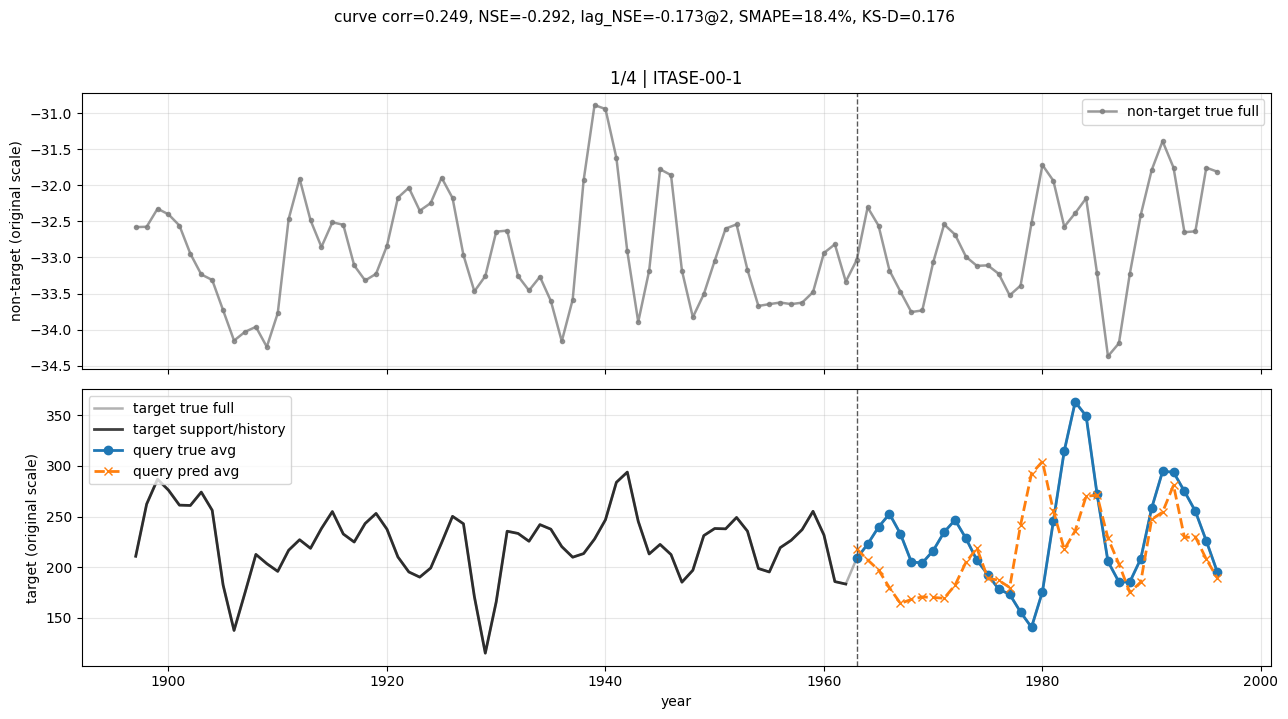

[ITASE-02-4 | window] N=96 | mse: 4083.4329, mae: 50.4160 | corr: 0.0935 | corr_smooth_3: 0.1029 | lag_corr@±2: 0.3636, best_lag: -2 | NSE: -4.7508 | lag_NSE@±2: -3.8919, best_nse_lag: -2 | SMAPE(%): 51.47 | KS-D: 0.3750, KS-p: 2.114e-06
[ITASE-02-4 | curve] N=34 | mse: 2492.9353, mae: 40.0687 | corr: 0.1643 | corr_smooth_3: 0.1411 | lag_corr@±2: 0.4556, best_lag: -2 | NSE: -2.3014 | lag_NSE@±2: -1.7307, best_nse_lag: -1 | SMAPE(%): 40.58 | KS-D: 0.2941, KS-p: 0.1057


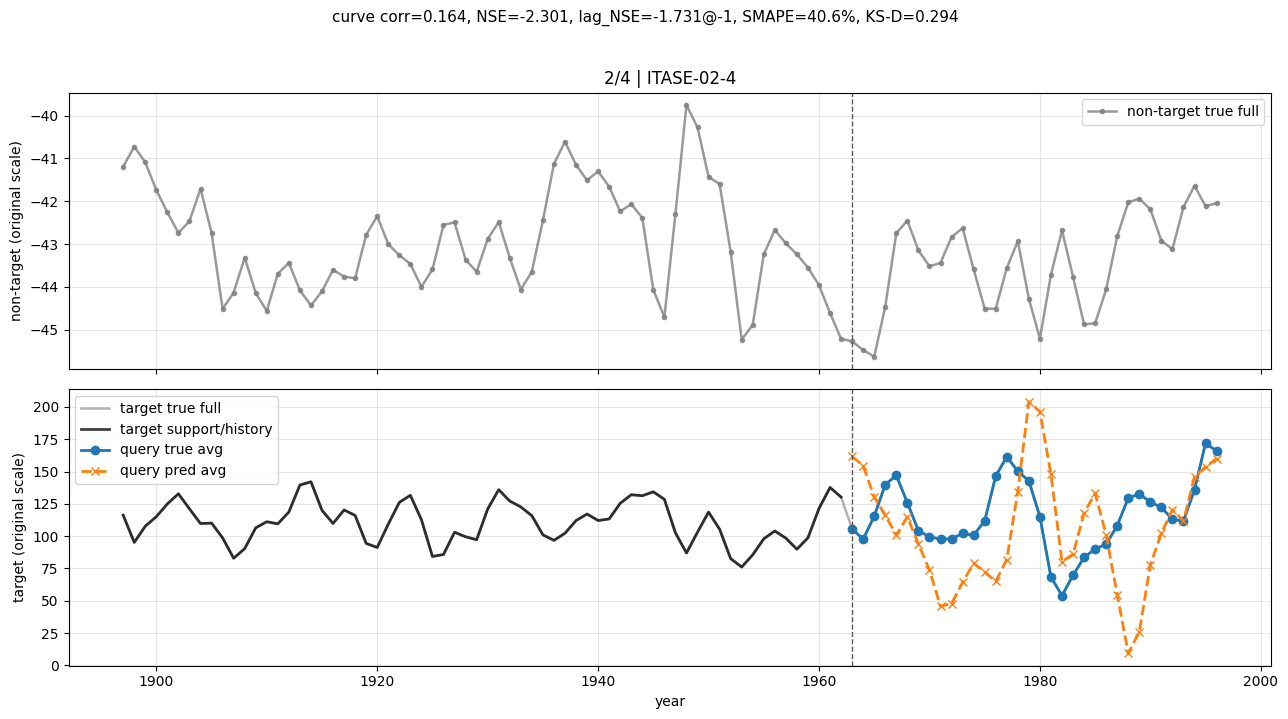

[FB97DML10 | window] N=96 | mse: 2943.0527, mae: 41.7210 | corr: -0.0071 | corr_smooth_3: 0.0479 | lag_corr@±2: 0.1816, best_lag: -2 | NSE: -57.6396 | lag_NSE@±2: -54.7251, best_nse_lag: -2 | SMAPE(%): 91.96 | KS-D: 0.4375, KS-p: 1.232e-08
[FB97DML10 | curve] N=34 | mse: 971.8660, mae: 26.1111 | corr: -0.0088 | corr_smooth_3: 0.0603 | lag_corr@±2: 0.3078, best_lag: -2 | NSE: -19.3267 | lag_NSE@±2: -16.4689, best_nse_lag: -2 | SMAPE(%): 63.27 | KS-D: 0.4412, KS-p: 0.002356


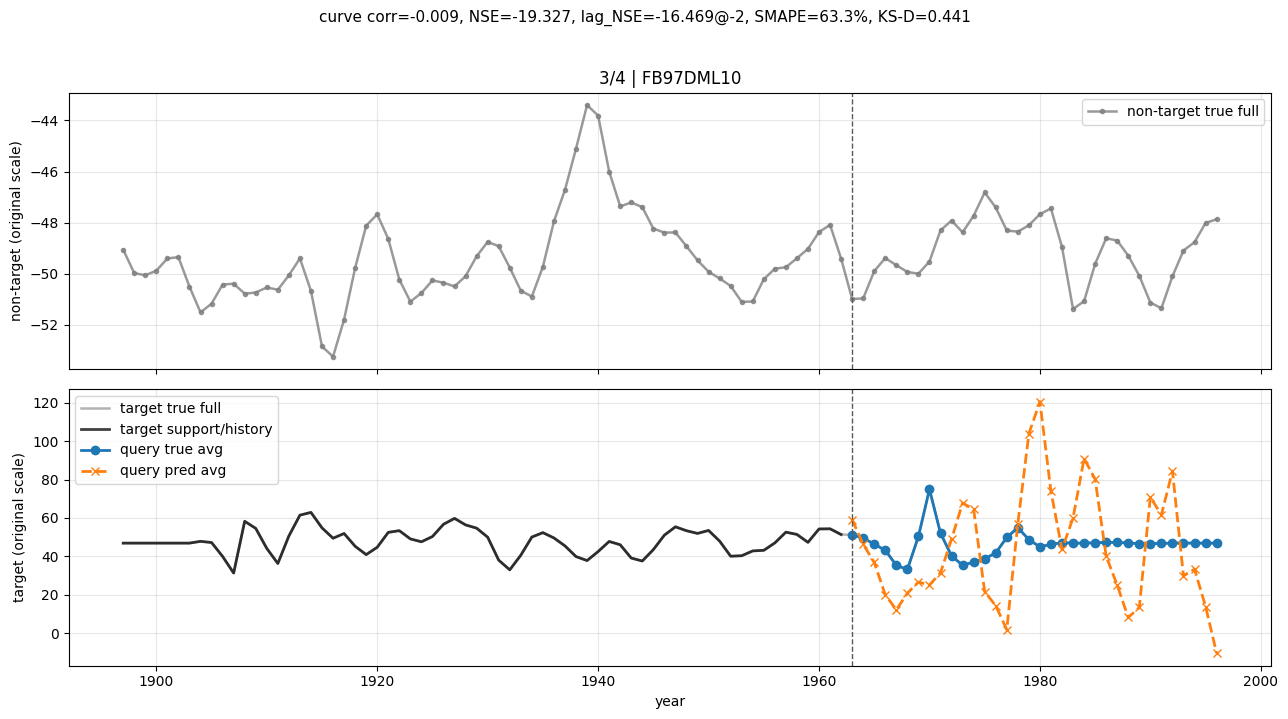

[ITASE-01-2 | window] N=96 | mse: 5903.8301, mae: 65.1767 | corr: 0.6061 | corr_smooth_3: 0.7940 | lag_corr@±2: 0.6061, best_lag: 0 | NSE: -1.0094 | lag_NSE@±2: -1.0094, best_nse_lag: 0 | SMAPE(%): 15.10 | KS-D: 0.5312, KS-p: 9.519e-13
[ITASE-01-2 | curve] N=34 | mse: 4095.0068, mae: 55.7262 | corr: 0.8089 | corr_smooth_3: 0.8860 | lag_corr@±2: 0.8089, best_lag: 0 | NSE: -0.4380 | lag_NSE@±2: -0.4380, best_nse_lag: 0 | SMAPE(%): 12.86 | KS-D: 0.4412, KS-p: 0.002356


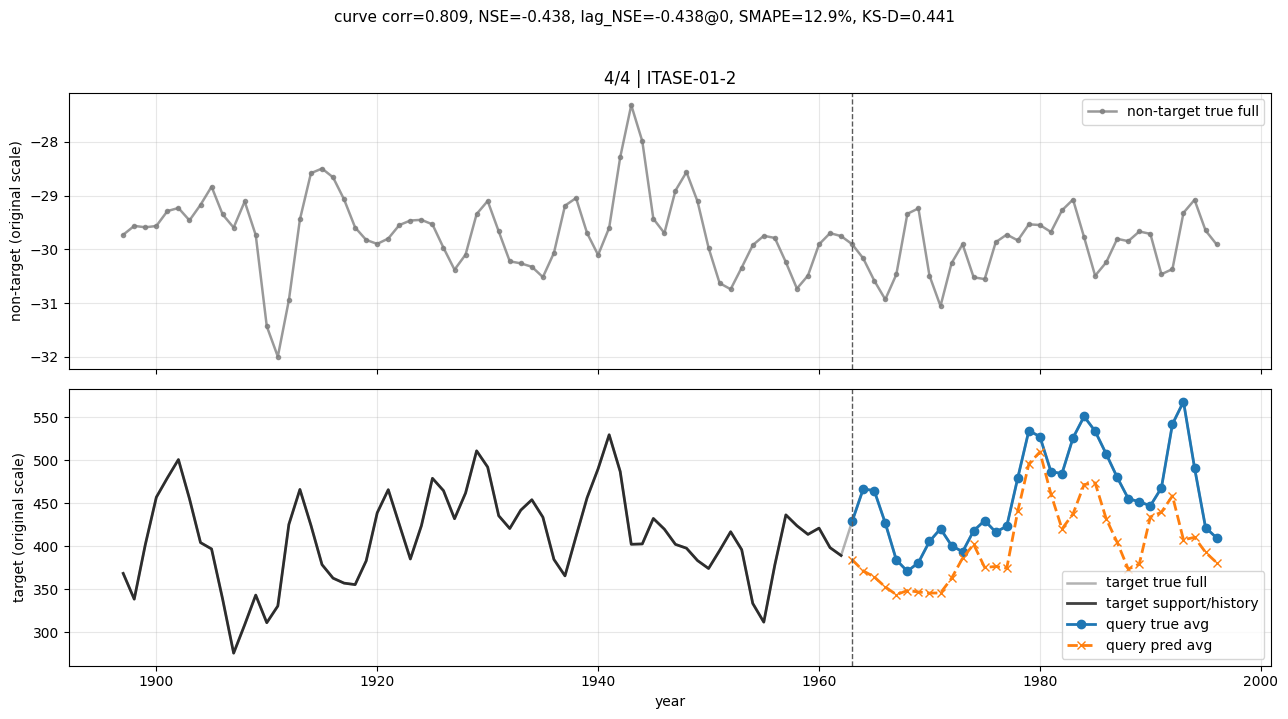


========== Summary over plotted test sites ==========
sites plotted: 4
[overall test windows] N=384 | mse: 4558.1440, mae: 53.6772 | corr: 0.9193 | corr_smooth_3: 0.9612 | lag_corr@±2: 0.9193, best_lag: 0 | NSE: 0.8273 | lag_NSE@±2: 0.8273, best_nse_lag: 0 | SMAPE(%): 45.95 | KS-D: 0.1328, KS-p: 0.002262
[overall aggregated curves] N=136 | mse: 2707.9966, mae: 40.9390 | corr: 0.9585 | corr_smooth_3: 0.9709 | lag_corr@±2: 0.9585, best_lag: 0 | NSE: 0.8960 | lag_NSE@±2: 0.8960, best_nse_lag: 0 | SMAPE(%): 33.78 | KS-D: 0.1250, KS-p: 0.239


{'scale': 'inverse-transformed',
 'overall_window': {'n': 384,
  'mse': 4558.14404296875,
  'mae': 53.677181243896484,
  'corr': 0.9192559213430822,
  'corr_smooth_3': 0.9612301195782789,
  'lag_corr': 0.9192559213430822,
  'best_lag': 0,
  'nse': 0.8273286809254004,
  'lag_nse': 0.8273286809254004,
  'best_nse_lag': 0,
  'smape': 45.946712493896484,
  'ks_stat': 0.1328125,
  'ks_pvalue': 0.0022621159977387045},
 'overall_curve': {'n': 136,
  'mse': 2707.99658203125,
  'mae': 40.939029693603516,
  'corr': 0.9585452962671188,
  'corr_smooth_3': 0.9708569591362002,
  'lag_corr': 0.9585452962671188,
  'best_lag': 0,
  'nse': 0.895971306189013,
  'lag_nse': 0.895971306189013,
  'best_nse_lag': 0,
  'smape': 33.78094482421875,
  'ks_stat': 0.125,
  'ks_pvalue': 0.23902885539778176},
 'site_rows': [{'site': 'ITASE-00-1',
   'window_n': 96,
   'window_mse': 5302.26123046875,
   'window_mae': 57.39497756958008,
   'window_corr': 0.163976701825673,
   'window_corr_smooth_3': 0.25828225193184756

In [4]:
visualise_all_crossvar_test_sites(
    npz_path=str(PROJECT_ROOT / "results/long_term_forecast_SEMPO_d18O_accum_crossvar_protoprototypes/d18O_accum_crossvar_relation_pretrain_proto_k3_fixed_sum.npz_ftM_sl32_ll48_pl32_pl16_dm256_nh2_el3_dl3_df128_fc1_ebtimeF_dtTrue_0/results.npz"),
    show=True,
    inverse_transform_values=True,
)


Loaded results: preds=(18, 32), trues=(18, 32), scale=inverse-transformed
Total test sites to plot: 6
[overall test windows] N=576 | mse: 1935.6501, mae: 33.4883 | corr: 0.9121 | corr_smooth_3: 0.9418 | lag_corr@±2: 0.9121, best_lag: 0 | NSE: 0.8006 | lag_NSE@±2: 0.8006, best_nse_lag: 0 | SMAPE(%): 22.28 | KS-D: 0.0972, KS-p: 0.008607
[ITASE-02-4 | window] N=96 | mse: 1511.6128, mae: 31.6270 | corr: -0.1931 | corr_smooth_3: -0.2431 | lag_corr@±2: -0.0927, best_lag: 2 | NSE: -1.1288 | lag_NSE@±2: -0.9491, best_nse_lag: 2 | SMAPE(%): 27.46 | KS-D: 0.2396, KS-p: 0.007893
[ITASE-02-4 | curve] N=34 | mse: 1318.0027, mae: 29.2370 | corr: -0.2178 | corr_smooth_3: -0.2487 | lag_corr@±2: -0.0712, best_lag: 2 | NSE: -0.7454 | lag_NSE@±2: -0.5457, best_nse_lag: 2 | SMAPE(%): 25.21 | KS-D: 0.2353, KS-p: 0.3068


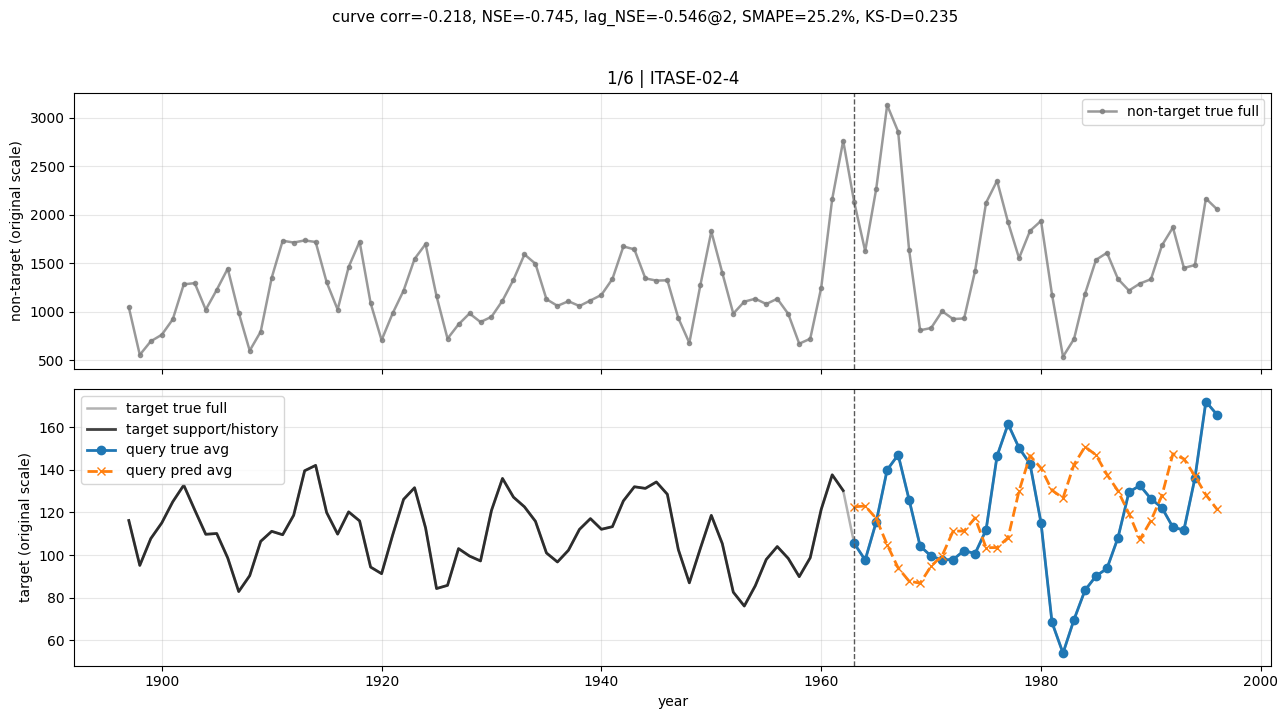

[Talos Dome 159.07575E | window] N=96 | mse: 1249.3632, mae: 26.7906 | corr: 0.0888 | corr_smooth_3: 0.1312 | lag_corr@±2: 0.0888, best_lag: 0 | NSE: -2.3437 | lag_NSE@±2: -2.3437, best_nse_lag: 0 | SMAPE(%): 29.08 | KS-D: 0.3021, KS-p: 0.0002864
[Talos Dome 159.07575E | curve] N=34 | mse: 699.7582, mae: 21.0219 | corr: 0.1861 | corr_smooth_3: 0.1764 | lag_corr@±2: 0.1861, best_lag: 0 | NSE: -0.8394 | lag_NSE@±2: -0.8070, best_nse_lag: -1 | SMAPE(%): 23.34 | KS-D: 0.2941, KS-p: 0.1057


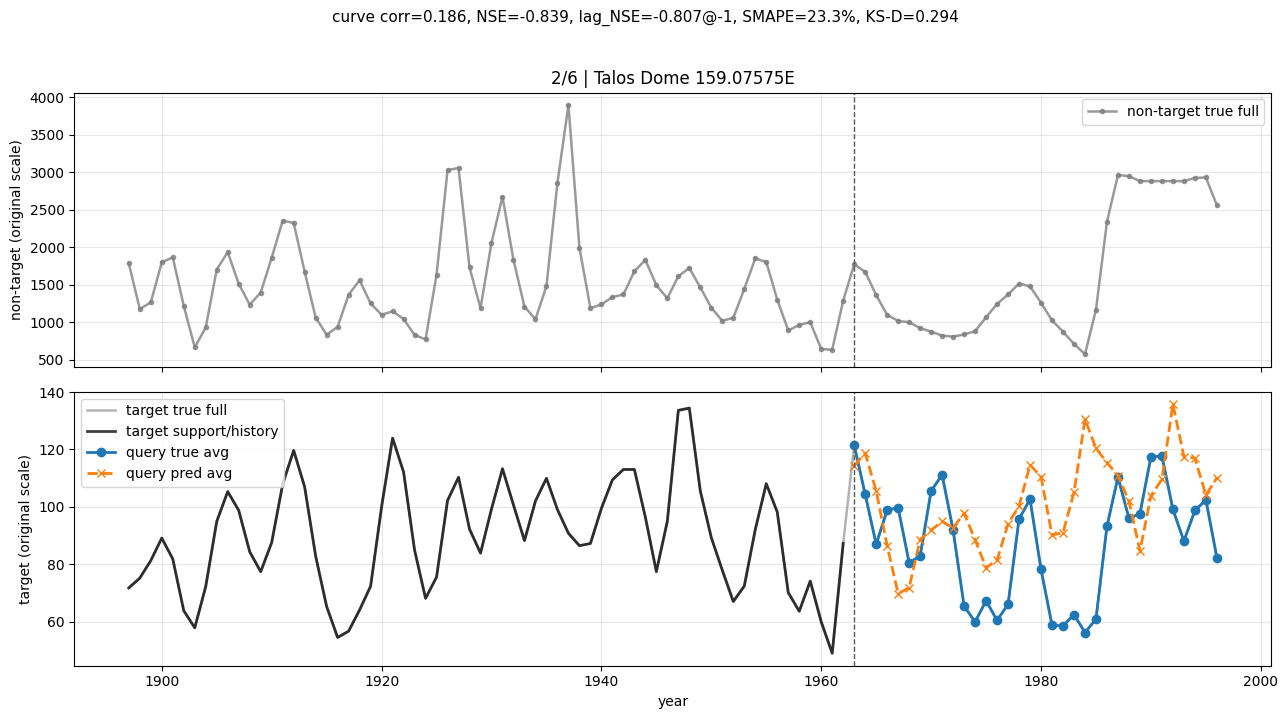

[FB9814 | window] N=96 | mse: 892.5037, mae: 24.1243 | corr: -0.2268 | corr_smooth_3: -0.4033 | lag_corr@±2: 0.0134, best_lag: 2 | NSE: -2.8801 | lag_NSE@±2: -2.1539, best_nse_lag: 2 | SMAPE(%): 33.08 | KS-D: 0.2812, KS-p: 0.0009463
[FB9814 | curve] N=34 | mse: 652.3485, mae: 20.1049 | corr: -0.2784 | corr_smooth_3: -0.4431 | lag_corr@±2: -0.0122, best_lag: 2 | NSE: -1.9281 | lag_NSE@±2: -1.2856, best_nse_lag: 2 | SMAPE(%): 27.03 | KS-D: 0.2353, KS-p: 0.3068


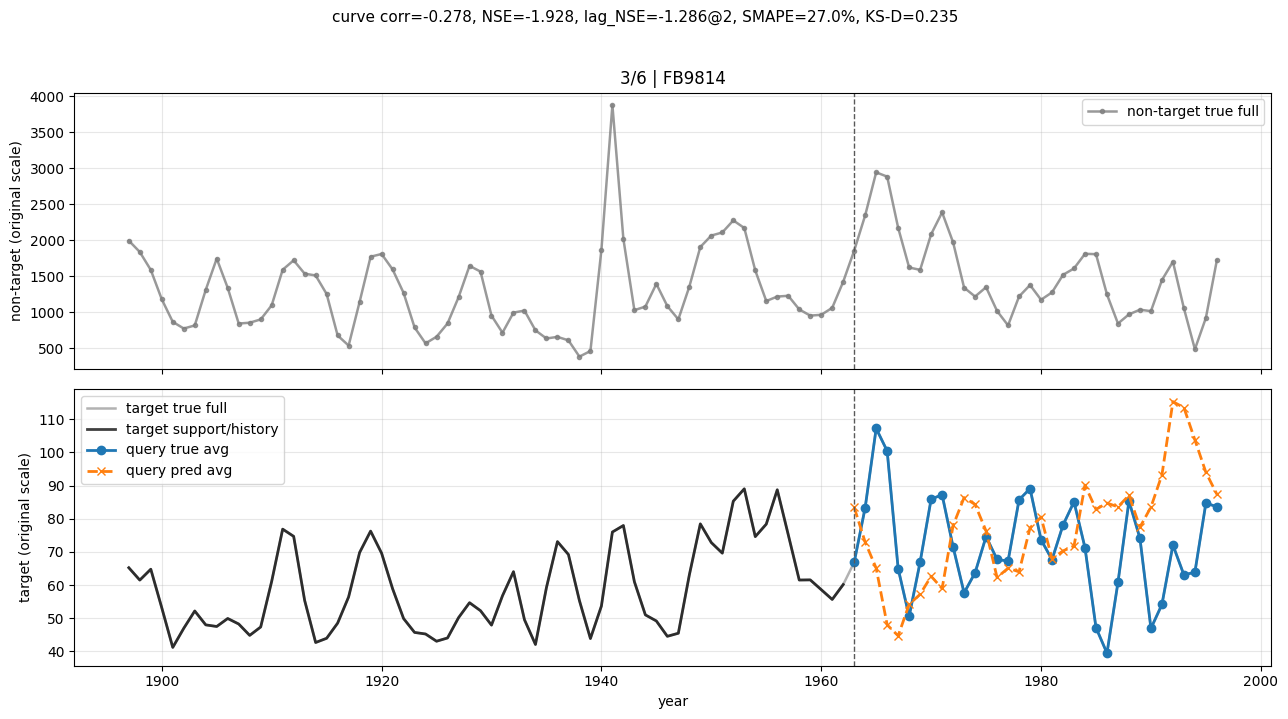

[WD05A 112.125W | window] N=96 | mse: 722.1848, mae: 20.9890 | corr: 0.5108 | corr_smooth_3: 0.6208 | lag_corr@±2: 0.5108, best_lag: 0 | NSE: -0.0959 | lag_NSE@±2: -0.0959, best_nse_lag: 0 | SMAPE(%): 9.98 | KS-D: 0.3854, KS-p: 9.536e-07
[WD05A 112.125W | curve] N=34 | mse: 682.1214, mae: 20.2821 | corr: 0.5586 | corr_smooth_3: 0.6699 | lag_corr@±2: 0.5586, best_lag: 0 | NSE: 0.0136 | lag_NSE@±2: 0.0136, best_nse_lag: 0 | SMAPE(%): 9.80 | KS-D: 0.4118, KS-p: 0.005772


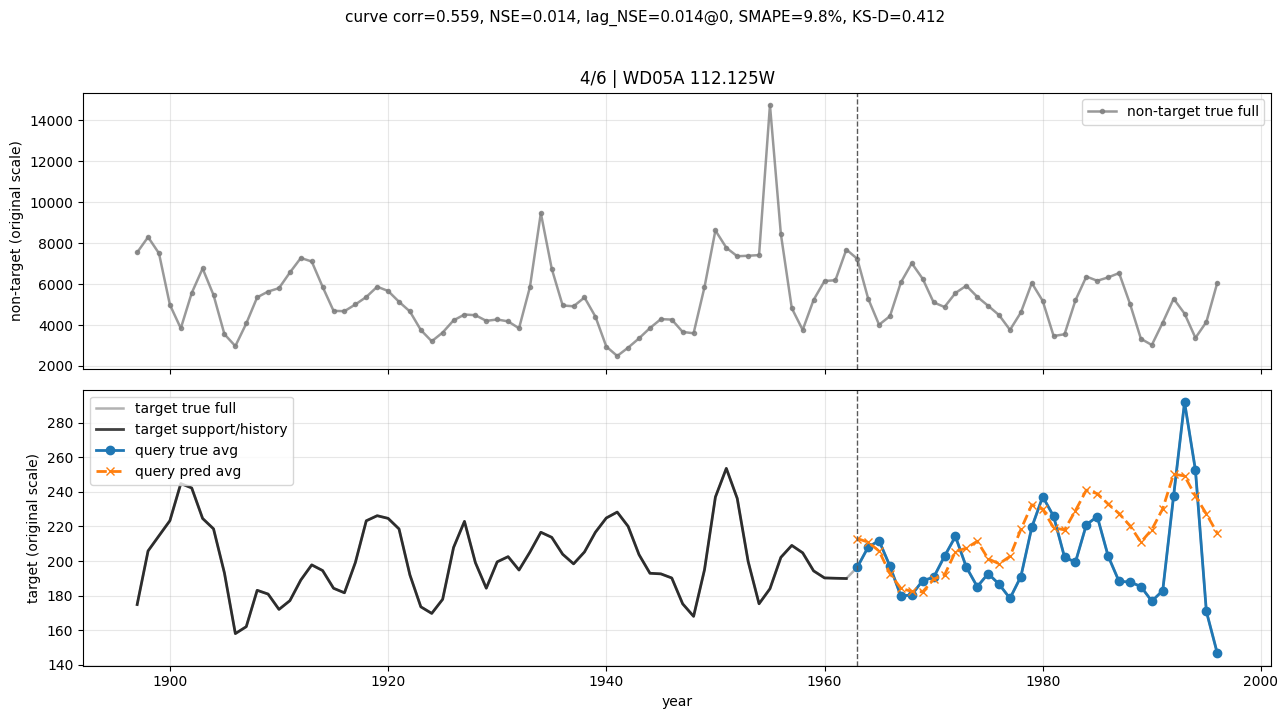

[ITASE-00-1 | window] N=96 | mse: 2514.6487, mae: 38.3997 | corr: 0.2834 | corr_smooth_3: 0.3603 | lag_corr@±2: 0.3310, best_lag: -1 | NSE: 0.0518 | lag_NSE@±2: 0.0945, best_nse_lag: -1 | SMAPE(%): 16.57 | KS-D: 0.2708, KS-p: 0.001663
[ITASE-00-1 | curve] N=34 | mse: 2268.6736, mae: 36.3457 | corr: 0.3357 | corr_smooth_3: 0.3869 | lag_corr@±2: 0.3963, best_lag: -1 | NSE: 0.1041 | lag_NSE@±2: 0.1522, best_nse_lag: -1 | SMAPE(%): 15.72 | KS-D: 0.3235, KS-p: 0.05637


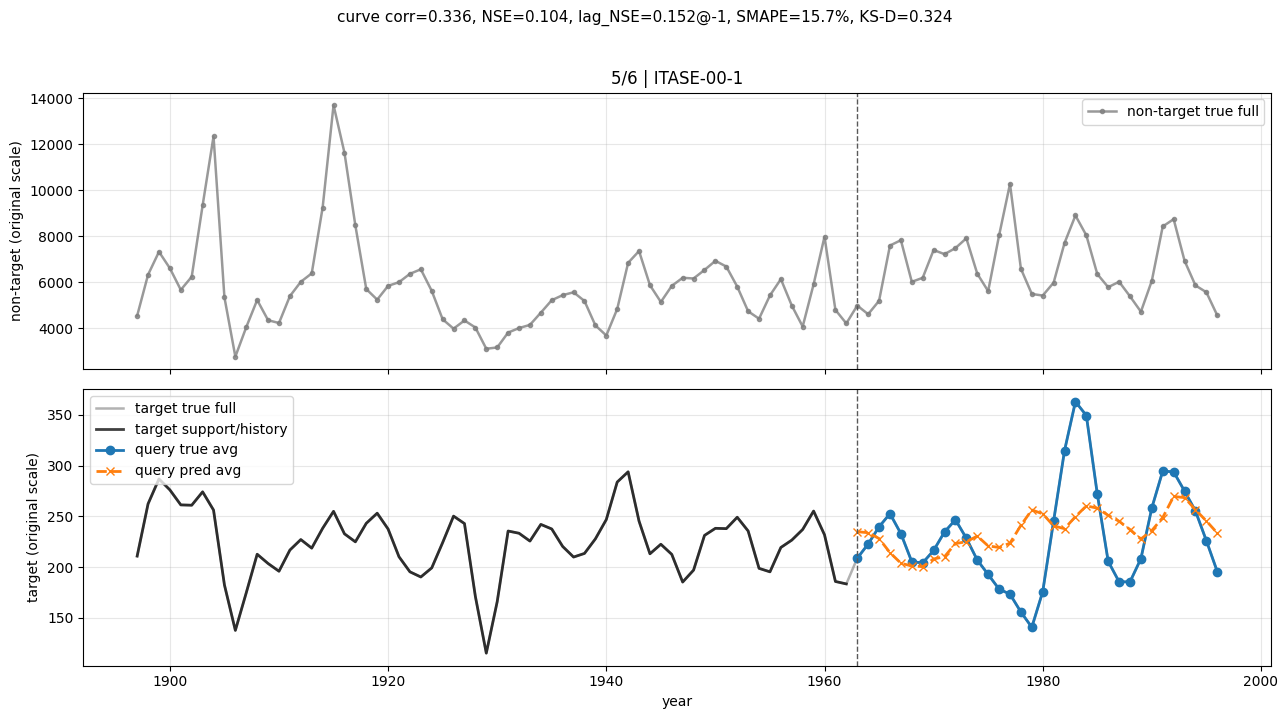

[ITASE-01-5 | window] N=96 | mse: 4723.5874, mae: 58.9994 | corr: -0.0954 | corr_smooth_3: 0.0080 | lag_corr@±2: 0.2750, best_lag: -2 | NSE: -0.5592 | lag_NSE@±2: -0.3489, best_nse_lag: -2 | SMAPE(%): 17.51 | KS-D: 0.5312, KS-p: 9.519e-13
[ITASE-01-5 | curve] N=34 | mse: 4612.4639, mae: 58.7472 | corr: -0.2352 | corr_smooth_3: -0.1038 | lag_corr@±2: 0.3908, best_lag: -2 | NSE: -0.5448 | lag_NSE@±2: -0.3258, best_nse_lag: -2 | SMAPE(%): 17.42 | KS-D: 0.6176, KS-p: 2.205e-06


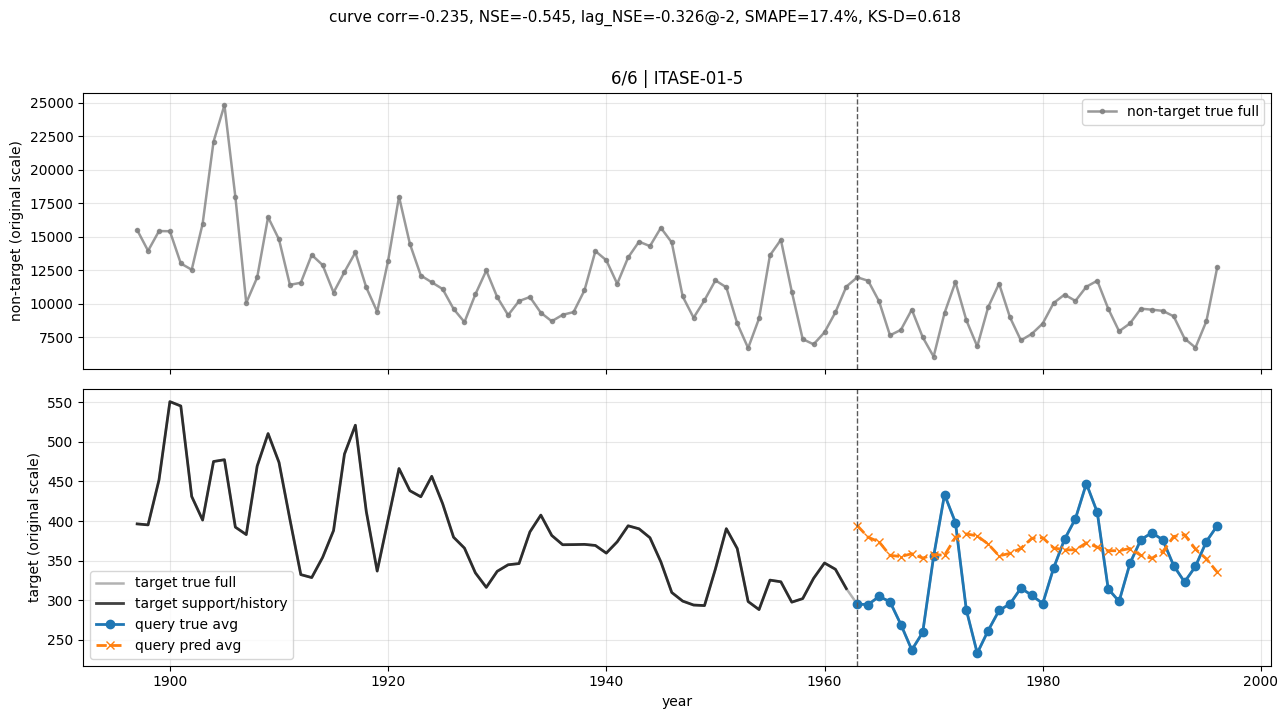


========== Summary over plotted test sites ==========
sites plotted: 6
[overall test windows] N=576 | mse: 1935.6501, mae: 33.4883 | corr: 0.9121 | corr_smooth_3: 0.9418 | lag_corr@±2: 0.9121, best_lag: 0 | NSE: 0.8006 | lag_NSE@±2: 0.8006, best_nse_lag: 0 | SMAPE(%): 22.28 | KS-D: 0.0972, KS-p: 0.008607
[overall aggregated curves] N=204 | mse: 1705.5615, mae: 30.9565 | corr: 0.9221 | corr_smooth_3: 0.9432 | lag_corr@±2: 0.9221, best_lag: 0 | NSE: 0.8228 | lag_NSE@±2: 0.8228, best_nse_lag: 0 | SMAPE(%): 19.75 | KS-D: 0.1127, KS-p: 0.1496


{'scale': 'inverse-transformed',
 'overall_window': {'n': 576,
  'mse': 1935.650146484375,
  'mae': 33.488319396972656,
  'corr': 0.9121409322215365,
  'corr_smooth_3': 0.9418291626357961,
  'lag_corr': 0.9121409322215365,
  'best_lag': 0,
  'nse': 0.8006479946602708,
  'lag_nse': 0.8006479946602708,
  'best_nse_lag': 0,
  'smape': 22.27967071533203,
  'ks_stat': 0.09722222222222222,
  'ks_pvalue': 0.008607158029691685},
 'overall_curve': {'n': 204,
  'mse': 1705.5615234375,
  'mae': 30.95646095275879,
  'corr': 0.9221466244233933,
  'corr_smooth_3': 0.9432106975383555,
  'lag_corr': 0.9221466244233933,
  'best_lag': 0,
  'nse': 0.8227507607581199,
  'lag_nse': 0.8227507607581199,
  'best_nse_lag': 0,
  'smape': 19.752819061279297,
  'ks_stat': 0.11274509803921569,
  'ks_pvalue': 0.1496406995031548},
 'site_rows': [{'site': 'ITASE-02-4',
   'window_n': 96,
   'window_mse': 1511.61279296875,
   'window_mae': 31.62699317932129,
   'window_corr': -0.1931202451846576,
   'window_corr_smoot

In [5]:
visualise_all_crossvar_test_sites(
    npz_path=str(PROJECT_ROOT / "./results/long_term_forecast_SEMPO_chem_accum_crossvar_protoprototypes/chem_accum_crossvar_relation_pretrain_proto_k3.npz_ftM_sl32_ll48_pl32_pl16_dm256_nh2_el3_dl3_df128_fc1_ebtimeF_dtTrue_0/results.npz"),
    show=True,
    inverse_transform_values=True,
)

## CrossVar_zoom


## MS


- ms / average / inverse_transform


In [10]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from data_provider.icecore_data_loader import Dataset_IceCore_MS

print("PROJECT_ROOT =", PROJECT_ROOT)

try:
    from scipy import stats
except Exception:
    stats = None


def _to_str_array(arr):
    out = []
    for x in np.asarray(arr).reshape(-1):
        if isinstance(x, bytes):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return np.asarray(out)


def _as_1d_float(arr):
    arr = np.asarray(arr, dtype=np.float32)
    if arr.ndim == 2 and arr.shape[-1] == 1:
        arr = arr[:, 0]
    return arr.reshape(-1)


def _squeeze_target_array(arr, name="values"):
    arr = np.asarray(arr)
    if arr.ndim == 3 and arr.shape[-1] == 1:
        return arr[..., 0]
    if arr.ndim == 3:
        return arr[..., -1]
    if arr.ndim == 2:
        return arr
    raise ValueError(f"{name} 应为 [N,T] 或 [N,T,C]，实际 {arr.shape}")


def _calc_mean_and_sort(data_dict):
    if not data_dict:
        return np.asarray([], dtype=np.float32), np.asarray([], dtype=np.float32)
    sorted_years = sorted(data_dict.keys())
    mean_vals = [np.mean(data_dict[y]) for y in sorted_years]
    return np.asarray(sorted_years, dtype=np.float32), np.asarray(mean_vals, dtype=np.float32)


def _moving_average_1d(x, window=3):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if window <= 1 or len(x) < window:
        return x
    kernel = np.ones(window, dtype=np.float32) / float(window)
    return np.convolve(x, kernel, mode="valid")


def _corr_1d(pred, true):
    pred = np.asarray(pred, dtype=np.float32).reshape(-1)
    true = np.asarray(true, dtype=np.float32).reshape(-1)
    mask = np.isfinite(pred) & np.isfinite(true)
    pred = pred[mask]
    true = true[mask]
    if len(pred) < 2 or np.std(pred) <= 1e-8 or np.std(true) <= 1e-8:
        return np.nan
    return float(np.corrcoef(pred, true)[0, 1])


def _smooth_corr_1d(pred, true, window=3):
    pred_s = _moving_average_1d(pred, window=window)
    true_s = _moving_average_1d(true, window=window)
    n = min(len(pred_s), len(true_s))
    if n == 0:
        return np.nan
    return _corr_1d(pred_s[:n], true_s[:n])


def _align_by_lag(pred, true, lag):
    pred = np.asarray(pred, dtype=np.float32).reshape(-1)
    true = np.asarray(true, dtype=np.float32).reshape(-1)
    if lag < 0:
        p = pred[-lag:]
        t = true[:len(p)]
    elif lag > 0:
        p = pred[:-lag]
        t = true[lag:]
    else:
        p = pred
        t = true
    n = min(len(p), len(t))
    return p[:n], t[:n]


def _lag_aware_corr_1d(pred, true, max_lag=2):
    best_corr = np.nan
    best_lag = 0
    for lag in range(-max_lag, max_lag + 1):
        p, t = _align_by_lag(pred, true, lag)
        if len(p) < 2:
            continue
        corr = _corr_1d(p, t)
        if np.isfinite(corr) and (not np.isfinite(best_corr) or corr > best_corr):
            best_corr = corr
            best_lag = lag
    return float(best_corr) if np.isfinite(best_corr) else np.nan, int(best_lag)


def _nse_1d(pred, true):
    pred = np.asarray(pred, dtype=np.float32).reshape(-1)
    true = np.asarray(true, dtype=np.float32).reshape(-1)
    mask = np.isfinite(pred) & np.isfinite(true)
    pred = pred[mask]
    true = true[mask]
    if len(pred) == 0:
        return np.nan
    denominator = float(np.sum((true - np.mean(true)) ** 2))
    if denominator <= 1e-12:
        return np.nan
    return float(1.0 - np.sum((true - pred) ** 2) / denominator)


def _lag_aware_nse_1d(pred, true, max_lag=2):
    best_nse = np.nan
    best_lag = 0
    for lag in range(-max_lag, max_lag + 1):
        p, t = _align_by_lag(pred, true, lag)
        if len(p) < 2:
            continue
        nse = _nse_1d(p, t)
        if np.isfinite(nse) and (not np.isfinite(best_nse) or nse > best_nse):
            best_nse = nse
            best_lag = lag
    return float(best_nse) if np.isfinite(best_nse) else np.nan, int(best_lag)


def _calc_prediction_metrics(pred, true):
    pred = np.asarray(pred, dtype=np.float32).reshape(-1)
    true = np.asarray(true, dtype=np.float32).reshape(-1)
    mask = np.isfinite(pred) & np.isfinite(true)
    pred = pred[mask]
    true = true[mask]
    if len(pred) == 0:
        return {
            "n": 0, "mse": np.nan, "mae": np.nan, "corr": np.nan,
            "corr_smooth_3": np.nan, "lag_corr": np.nan, "best_lag": np.nan,
            "nse": np.nan, "lag_nse": np.nan, "best_nse_lag": np.nan,
            "smape": np.nan, "ks_stat": np.nan, "ks_pvalue": np.nan,
        }
    err = pred - true
    mse = float(np.mean(err ** 2))
    mae = float(np.mean(np.abs(err)))
    corr = _corr_1d(pred, true)
    corr_smooth_3 = _smooth_corr_1d(pred, true, window=3)
    lag_corr, best_lag = _lag_aware_corr_1d(pred, true, max_lag=2)
    nse = _nse_1d(pred, true)
    lag_nse, best_nse_lag = _lag_aware_nse_1d(pred, true, max_lag=2)
    smape = float(np.mean(200.0 * np.abs(pred - true) / (np.abs(true) + np.abs(pred) + 1e-8)))
    if stats is not None:
        ks_stat, ks_pvalue = stats.ks_2samp(true, pred)
        ks_stat = float(ks_stat)
        ks_pvalue = float(ks_pvalue)
    else:
        ks_stat = np.nan
        ks_pvalue = np.nan
    return {
        "n": int(len(pred)), "mse": mse, "mae": mae, "corr": corr,
        "corr_smooth_3": corr_smooth_3, "lag_corr": lag_corr, "best_lag": best_lag,
        "nse": nse, "lag_nse": lag_nse, "best_nse_lag": best_nse_lag,
        "smape": smape, "ks_stat": ks_stat, "ks_pvalue": ks_pvalue,
    }


def _format_metrics(metrics):
    return (
        f"N={metrics['n']} | "
        f"mse: {metrics['mse']:.4f}, mae: {metrics['mae']:.4f} | "
        f"corr: {metrics['corr']:.4f} | "
        f"corr_smooth_3: {metrics['corr_smooth_3']:.4f} | "
        f"lag_corr@±2: {metrics['lag_corr']:.4f}, best_lag: {metrics['best_lag']} | "
        f"NSE: {metrics['nse']:.4f} | "
        f"lag_NSE@±2: {metrics['lag_nse']:.4f}, best_nse_lag: {metrics['best_nse_lag']} | "
        f"SMAPE(%): {metrics['smape']:.2f} | "
        f"KS-D: {metrics['ks_stat']:.4f}, KS-p: {metrics['ks_pvalue']:.4g}"
    )


def _print_prediction_metrics(label, metrics):
    print(f"[{label}] {_format_metrics(metrics)}")


def _metric_ready_curve(arr):
    return np.asarray(arr, dtype=np.float32).reshape(1, -1, 1)



def _safe_inverse_transform_ms(dataset, vals, var):
    vals = np.asarray(vals, dtype=np.float32).reshape(-1)
    if len(vals) == 0:
        return vals
    return dataset.inverse_transform(vals.reshape(-1, 1), var=var).reshape(-1)


def _label_for_ms_var(var_name, var_labels):
    return var_labels.get(var_name, var_name)


def _write_metrics_csv(path, rows):
    if not rows:
        return
    fieldnames = list(rows[0].keys())
    with open(path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def visualise_icecore_ms_with_history(
    npz_path,
    target_cluster,
    root_path,
    x_data_path,
    y_data_path,
    cluster_result_path,
    site_meta_path="dataset/icecore/data_sources.csv",
    target_var="accum",
    seq_len=32,
    label_len=16,
    pred_len=32,
    apply_pywt=True,
    residual_prediction=False,
    support_ratio=0.66,
    filter_cid=None,
    accum_label="Accumulation",
    chem_label="Chem",
    x_label=None,
    y_label=None,
    show=True,
    save_dir=None,
    inverse_transform_values=False,
):
    """
    MS 可视化。inverse_transform_values=True 时，图和指标都使用 target 变量反归一化值；
    False 时使用 results.npz 中的 scaled 值。
    """
    dataset = Dataset_IceCore_MS(
        root_path=root_path,
        data_path=None,
        x_data_path=x_data_path,
        y_data_path=y_data_path,
        flag="train",
        size=[seq_len, label_len, pred_len],
        features="MS",
        target=target_var,
        scale=True,
        timeenc=1,
        freq="y",
        percent=100,
        task_name="long_term_forecast",
        is_pretraining=0,
        apply_pywt=apply_pywt,
        site_meta_path=site_meta_path,
        cluster_result_path=cluster_result_path,
        residual_prediction=residual_prediction,
        support_ratio=support_ratio,
        filter_cid=filter_cid,
        verbose=False,
    )

    var_names = list(dataset.var_names)
    target_var = dataset.target_var
    target_idx = int(dataset.target_idx)
    var_labels = {
        "accum": accum_label,
        "chem": chem_label,
        var_names[0]: x_label or var_names[0],
        var_names[1]: y_label or var_names[1],
    }
    target_label = _label_for_ms_var(target_var, var_labels)

    data = np.load(npz_path, allow_pickle=True)
    preds_raw = np.asarray(data["preds"])
    trues_raw = np.asarray(data["trues"])
    sites = _to_str_array(data["sites"])
    years = np.asarray(data["years"])
    clusters = np.asarray(data["clusters"]).reshape(-1)
    inputs = np.asarray(data["inputs"]) if "inputs" in data else None
    has_inputs = inputs is not None

    if preds_raw.ndim == 3:
        pred_target = preds_raw[:, :, target_idx]
    elif preds_raw.ndim == 2:
        pred_target = preds_raw
    else:
        raise ValueError(f"Unsupported preds shape: {preds_raw.shape}")

    if trues_raw.ndim == 3:
        true_target = trues_raw[:, :, target_idx]
    elif trues_raw.ndim == 2:
        true_target = trues_raw
    else:
        raise ValueError(f"Unsupported trues shape: {trues_raw.shape}")

    if has_inputs:
        if inputs.ndim == 3:
            input_target = inputs[:, :, target_idx]
        elif inputs.ndim == 2:
            input_target = inputs
        else:
            raise ValueError(f"Unsupported inputs shape: {inputs.shape}")
    else:
        input_target = None

    scale_label = "scaled"
    if inverse_transform_values:
        pred_target = _safe_inverse_transform_ms(dataset, pred_target.reshape(-1), target_var).reshape(pred_target.shape)
        true_target = _safe_inverse_transform_ms(dataset, true_target.reshape(-1), target_var).reshape(true_target.shape)
        if input_target is not None:
            input_target = _safe_inverse_transform_ms(dataset, input_target.reshape(-1), target_var).reshape(input_target.shape)
        scale_label = "inverse-transformed"

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    print(f"Loaded MS results: preds={pred_target.shape}, trues={true_target.shape}, scale={scale_label}")
    print(f"MS vars: {var_names} -> target={target_var}, target_idx={target_idx}")
    if stats is None:
        print("[warn] scipy 不可用，K-S Test 指标会是 NaN")

    overall_metrics = _calc_prediction_metrics(pred_target, true_target)
    _print_prediction_metrics("overall test windows", overall_metrics)

    target_mask = clusters == target_cluster
    if not np.any(target_mask):
        print(f"No data found for Cluster {target_cluster}.")
        return None

    cluster_metrics = _calc_prediction_metrics(pred_target[target_mask], true_target[target_mask])
    _print_prediction_metrics(f"cluster {target_cluster} test windows", cluster_metrics)

    unique_sites = np.unique(sites[target_mask])
    site_metric_rows = []
    all_curve_pred = []
    all_curve_true = []

    for site_idx, site_name in enumerate(unique_sites):
        site_mask = (sites == site_name) & target_mask
        site_idx_list = np.where(site_mask)[0]

        agg_history = defaultdict(list)
        agg_trues = defaultdict(list)
        agg_preds = defaultdict(list)

        window_metrics = _calc_prediction_metrics(pred_target[site_idx_list], true_target[site_idx_list])
        _print_prediction_metrics(f"{site_name} | window", window_metrics)

        for idx in site_idx_list:
            year_item = years[idx]
            year_arr = np.asarray(year_item).reshape(-1)
            if len(year_arr) > 1:
                pred_years = year_arr.astype(int)
                first_pred_year = int(pred_years[0])
            else:
                first_pred_year = int(year_arr[0])
                pred_years = np.arange(first_pred_year, first_pred_year + pred_target.shape[1])

            if input_target is not None:
                history_seq = input_target[idx]
                hist_years = np.arange(first_pred_year - len(history_seq), first_pred_year)
                for yr, val in zip(hist_years, history_seq):
                    agg_history[int(yr)].append(float(val))

            y_true_seq = true_target[idx]
            y_pred_seq = pred_target[idx]
            usable_len = min(len(pred_years), len(y_true_seq), len(y_pred_seq))
            for j in range(usable_len):
                yr = int(pred_years[j])
                agg_trues[yr].append(float(y_true_seq[j]))
                agg_preds[yr].append(float(y_pred_seq[j]))

        hist_years, hist_vals = _calc_mean_and_sort(agg_history)
        true_years, true_vals = _calc_mean_and_sort(agg_trues)
        pred_years, pred_vals = _calc_mean_and_sort(agg_preds)

        curve_metrics = _calc_prediction_metrics(_metric_ready_curve(pred_vals), _metric_ready_curve(true_vals))
        _print_prediction_metrics(f"{site_name} | curve", curve_metrics)

        all_curve_pred.append(pred_vals)
        all_curve_true.append(true_vals)

        row = {"site": site_name}
        for prefix, metrics in [("window", window_metrics), ("curve", curve_metrics)]:
            for key, value in metrics.items():
                row[f"{prefix}_{key}"] = value
        site_metric_rows.append(row)

        plt.figure(figsize=(14, 6))
        if input_target is not None and len(hist_years) > 0:
            plt.plot(hist_years, hist_vals, label=f"Aggregated History {target_label}", color="gray", linestyle="-", alpha=0.6, linewidth=1.8)
        plt.plot(true_years, true_vals, label=f"Aggregated True {target_label}", color="#1f77b4", marker="o", markersize=4, linewidth=2)
        plt.plot(pred_years, pred_vals, label=f"Aggregated Predicted {target_label}", color="#ff7f0e", linestyle="--", marker="x", markersize=5, linewidth=2)
        plt.title(
            f"{site_idx + 1}/{len(unique_sites)} | {site_name} | Cluster {target_cluster} | MS {target_label} | "
            f"curve corr={curve_metrics['corr']:.3f}, NSE={curve_metrics['nse']:.3f}, "
            f"lag_NSE={curve_metrics['lag_nse']:.3f}@{curve_metrics['best_nse_lag']}",
            fontsize=13,
            pad=10,
        )
        plt.xlabel("Year", fontsize=12)
        plt.ylabel((target_label + " original scale") if inverse_transform_values else (target_label + " scaled"), fontsize=12)
        plt.legend(loc="best", fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        if save_dir is not None:
            safe_site = str(site_name).replace("/", "_").replace("\\", "_").replace(" ", "_").replace(":", "_")
            save_path = os.path.join(save_dir, f"cluster{target_cluster}_{safe_site}.png")
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"Saved: {save_path}")

        if show:
            plt.show()
        else:
            plt.close()

    overall_curve_metrics = _calc_prediction_metrics(np.concatenate(all_curve_pred), np.concatenate(all_curve_true)) if all_curve_pred else _calc_prediction_metrics([], [])
    print("\n========== Summary over plotted MS sites ==========")
    print(f"sites plotted: {len(site_metric_rows)}")
    _print_prediction_metrics("overall test windows", overall_metrics)
    _print_prediction_metrics(f"cluster {target_cluster} test windows", cluster_metrics)
    _print_prediction_metrics(f"cluster {target_cluster} aggregated curves", overall_curve_metrics)

    if save_dir is not None:
        _write_metrics_csv(os.path.join(save_dir, "site_metrics.csv"), site_metric_rows)
        with open(os.path.join(save_dir, "overall_metrics.txt"), "w") as f:
            f.write(f"scale={scale_label}\n")
            f.write("overall test windows | " + _format_metrics(overall_metrics) + "\n")
            f.write(f"cluster {target_cluster} test windows | " + _format_metrics(cluster_metrics) + "\n")
            f.write(f"cluster {target_cluster} aggregated curves | " + _format_metrics(overall_curve_metrics) + "\n")

    return {
        "scale": scale_label,
        "overall_window": overall_metrics,
        "cluster_window": cluster_metrics,
        "cluster_curve": overall_curve_metrics,
        "site_rows": site_metric_rows,
    }


PROJECT_ROOT = /sharedata/home/cyyang/SEMPO_copy


preds shape: (165, 16)
trues shape: (165, 16)
inputs shape: (165, 32, 2)
years shape: (165, 16)
clusters shape: (165,)
MS task: [accum, chem] -> chem
Scaled MSE (chem):   0.249305
Scaled MAE (chem):   0.338338
Physical MSE (chem): 3945426.500000
Physical MAE (chem): 1345.958862
Cluster 0: Samples=66   | Physical MSE=5724856.000000 | Physical MAE=1748.159790
Cluster 1: Samples=66   | Physical MSE=333142.187500 | Physical MAE=453.929565
Cluster 2: Samples=33   | Physical MSE=7611137.000000 | Physical MAE=2325.615479


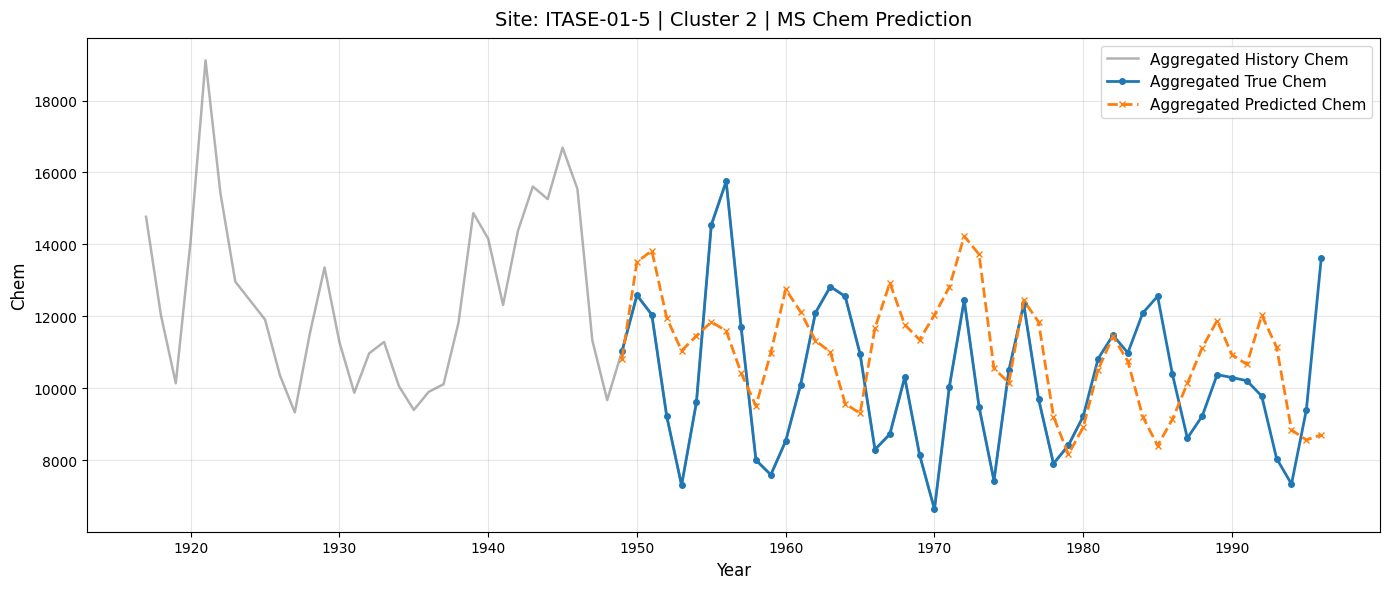

In [37]:
visualise_icecore_ms_with_history(
    npz_path=str(PROJECT_ROOT / "results/long_term_forecast_SEMPO_accum_chem_ms_ftMS_sl32_ll16_pl16_pl16_dm256_nh2_el3_dl3_df128_fc1_ebtimeF_dtTrue_0/results.npz"),
    target_cluster=2,
    root_path=str(PROJECT_ROOT / "dataset/icecore"),
    x_data_path="accum/accum_100y.csv",
    y_data_path="chem/chem_clean.csv",
    cluster_result_path=str(PROJECT_ROOT / "cluster/chem_cluster_mapped.csv"),
    site_meta_path=str(PROJECT_ROOT / "dataset/icecore/data_sources.csv"),
    target_var="chem",
    seq_len=32,
    label_len=16,
    pred_len=16,
    apply_pywt=True,
    residual_prediction=True,
    support_ratio=0.66,
    accum_label="Accumulation",
    chem_label="Chem",
    show=True,
)


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def visualise_loso_results(loso_config_path):
    """
    可视化新版 masked LOSO 结果。

    支持：
    - M0/M1：单通道 own d18O
    - M2/M3：own d18O + Gaussian regional d18O
    - 使用 yearly_* 字段绘制按年份聚合后的 query
    - 使用 observation mask 区分真实观测和计算占位值
    - 指标只在真实观测年份上计算
    """

    config_path = Path(loso_config_path).expanduser().resolve()
    results_root = config_path / "results"

    if not results_root.exists():
        raise FileNotFoundError(f"找不到结果目录：{results_root}")

    if config_path.parent.name != "loso_runs":
        raise ValueError(
            "传入路径应为：SEMPO_copy/loso_runs/<配置名>"
        )

    project_root = config_path.parent.parent

    metadata_path = (
        project_root
        / "dataset"
        / "icecore"
        / "data_sources.csv"
    )
    x_mask_path = (
        project_root
        / "dataset"
        / "icecore"
        / "d18O"
        / "d18O_observed_mask_100y.csv"
    )
    y_mask_path = (
        project_root
        / "dataset"
        / "icecore"
        / "accum"
        / "accum_observed_mask_100y.csv"
    )

    for path in [
        metadata_path,
        x_mask_path,
        y_mask_path,
    ]:
        if not path.exists():
            raise FileNotFoundError(f"找不到文件：{path}")

    def clean_site_name(value):
        if isinstance(value, bytes):
            value = value.decode("utf-8")

        value = str(value).strip().strip('"')
        value = re.sub(
            r"\s*\(.*?\)\s*",
            "",
            value,
        )
        value = re.sub(r"\s+", " ", value)
        return value.strip().lower()

    def clean_dataframe_columns(frame):
        frame = frame.copy()
        frame.columns = [
            re.sub(
                r"\s+",
                " ",
                str(column).strip().strip('"'),
            )
            for column in frame.columns
        ]
        return frame

    def as_float_array(values):
        return np.asarray(
            values,
            dtype=np.float32,
        )

    def as_1d(values):
        return as_float_array(values).reshape(-1)

    def region_of(longitude, elevation):
        if -130 <= longitude <= -70:
            return "WAIS"

        if -20 <= longitude <= 25:
            if elevation > 1500:
                return "DML plateau"
            return "DML coast"

        return "East Antarctica"

    def calculate_metrics(pred, true):
        pred = as_1d(pred)
        true = as_1d(true)

        if len(pred) != len(true):
            raise ValueError(
                "逐年预测和真实值长度不一致："
                f"{len(pred)} vs {len(true)}"
            )

        valid = (
            np.isfinite(pred)
            & np.isfinite(true)
        )

        pred = pred[valid]
        true = true[valid]

        if len(true) == 0:
            return {
                "corr": np.nan,
                "mse": np.nan,
                "mae": np.nan,
                "rmse": np.nan,
                "nse": np.nan,
            }

        error = pred - true

        mse = float(np.mean(error ** 2))
        mae = float(np.mean(np.abs(error)))
        rmse = float(np.sqrt(mse))

        if (
            len(true) >= 2
            and np.std(pred) > 1e-8
            and np.std(true) > 1e-8
        ):
            corr = float(
                np.corrcoef(pred, true)[0, 1]
            )
        else:
            corr = np.nan

        denominator = float(
            np.sum(
                (true - np.mean(true)) ** 2
            )
        )

        if denominator > 1e-12:
            nse = float(
                1.0
                - np.sum((true - pred) ** 2)
                / denominator
            )
        else:
            nse = np.nan

        return {
            "corr": corr,
            "mse": mse,
            "mae": mae,
            "rmse": rmse,
            "nse": nse,
        }

    def format_metric(value):
        if np.isfinite(value):
            return f"{value:.3f}"
        return "nan"

    def find_site_column(frame, site):
        target = clean_site_name(site)

        matches = [
            column
            for column in frame.columns
            if column != "year"
            and clean_site_name(column) == target
        ]

        if len(matches) != 1:
            raise ValueError(
                f"站点 {site!r} 在 mask CSV 中的匹配数"
                f"不是1：{matches}"
            )

        return matches[0]

    def align_site_mask(mask_frame, site, years):
        column = find_site_column(
            mask_frame,
            site,
        )

        indexed = (
            mask_frame
            .set_index("year")[column]
        )

        aligned = indexed.reindex(
            np.asarray(years).astype(int)
        )

        if aligned.isna().any():
            missing_years = np.asarray(years)[
                aligned.isna().to_numpy()
            ]
            raise ValueError(
                f"{site} 的 mask 无法对齐年份："
                f"{missing_years.tolist()}"
            )

        values = aligned.to_numpy()

        if not np.isin(
            values,
            [0, 1, False, True],
        ).all():
            raise ValueError(
                f"{site} 的 observation mask 不是二值"
            )

        return values.astype(bool)

    metadata = pd.read_csv(metadata_path)

    site_metadata = {}

    for _, row in metadata.iterrows():
        site_metadata[
            clean_site_name(row["site"])
        ] = {
            "latitude": float(row["Latitude"]),
            "longitude": float(row["Longitude"]),
            "elevation": float(row["Elevation"]),
            "region": region_of(
                float(row["Longitude"]),
                float(row["Elevation"]),
            ),
        }

    x_mask_frame = clean_dataframe_columns(
        pd.read_csv(x_mask_path)
    ).sort_values("year")

    y_mask_frame = clean_dataframe_columns(
        pd.read_csv(y_mask_path)
    ).sort_values("year")

    npz_files = sorted(
        results_root.glob(
            "fold-*/results.npz"
        )
    )

    if len(npz_files) != 15:
        raise RuntimeError(
            f"预期找到15个 results.npz，"
            f"实际找到 {len(npz_files)} 个。\n"
            f"目录：{results_root}"
        )

    required_fields = {
        "sites",
        "target_masks",
        "yearly_sites",
        "yearly_years",
        "yearly_preds",
        "yearly_trues",
        "crossvar_full_sites",
        "crossvar_full_x",
        "crossvar_full_y",
        "crossvar_full_years",
        "crossvar_full_support_lens",
    }

    records = []

    for npz_path in npz_files:
        with np.load(
            npz_path,
            allow_pickle=True,
        ) as data:
            missing = required_fields - set(data.files)

            if missing:
                raise KeyError(
                    f"{npz_path} 缺少新版字段："
                    f"{sorted(missing)}"
                )

            prediction_sites = np.asarray(
                data["sites"]
            ).astype(str)

            unique_sites = np.unique(
                prediction_sites
            )

            if len(unique_sites) != 1:
                raise ValueError(
                    f"{npz_path} 应只包含一个测试站点，"
                    f"实际为：{unique_sites}"
                )

            site = str(unique_sites[0])

            full_sites = np.asarray(
                data["crossvar_full_sites"]
            ).astype(str)

            full_matches = np.where(
                full_sites == site
            )[0]

            if len(full_matches) != 1:
                raise ValueError(
                    f"{site} 在 crossvar_full_sites "
                    f"中的匹配数不是1：{full_matches}"
                )

            full_index = int(
                full_matches[0]
            )

            full_years = as_1d(
                np.asarray(
                    data["crossvar_full_years"],
                    dtype=object,
                )[full_index]
            )

            full_x = as_float_array(
                np.asarray(
                    data["crossvar_full_x"],
                    dtype=object,
                )[full_index]
            )

            full_y = as_1d(
                np.asarray(
                    data["crossvar_full_y"],
                    dtype=object,
                )[full_index]
            )

            support_len = int(
                np.asarray(
                    data[
                        "crossvar_full_support_lens"
                    ]
                )[full_index]
            )

            yearly_sites = np.asarray(
                data["yearly_sites"]
            ).astype(str)

            yearly_keep = (
                yearly_sites == site
            )

            query_years = as_1d(
                data["yearly_years"]
            )[yearly_keep]

            query_preds = as_1d(
                data["yearly_preds"]
            )[yearly_keep]

            query_trues = as_1d(
                data["yearly_trues"]
            )[yearly_keep]

        if full_x.ndim == 1:
            full_x = full_x[:, None]

        if full_x.ndim != 2:
            raise ValueError(
                f"{site} 的 full_x 应为 [T,C]，"
                f"实际为 {full_x.shape}"
            )

        if full_x.shape[1] not in [1, 2]:
            raise ValueError(
                f"{site} 的输入通道数应为1或2，"
                f"实际为 {full_x.shape[1]}"
            )

        if not (
            len(full_years)
            == len(full_x)
            == len(full_y)
        ):
            raise ValueError(
                f"{site} 的完整序列长度不一致："
                f"years={len(full_years)}, "
                f"x={len(full_x)}, "
                f"y={len(full_y)}"
            )

        order = np.argsort(query_years)
        query_years = query_years[order]
        query_preds = query_preds[order]
        query_trues = query_trues[order]

        if len(np.unique(query_years)) != len(
            query_years
        ):
            raise ValueError(
                f"{site} 的 yearly_years 仍包含重复年份"
            )

        x_observed_mask = align_site_mask(
            x_mask_frame,
            site,
            full_years,
        )

        y_observed_mask = align_site_mask(
            y_mask_frame,
            site,
            full_years,
        )

        support_len = max(
            0,
            min(
                support_len,
                len(full_years),
            ),
        )

        metrics = calculate_metrics(
            query_preds,
            query_trues,
        )

        location = site_metadata.get(
            clean_site_name(site),
            {
                "latitude": np.nan,
                "longitude": np.nan,
                "elevation": np.nan,
                "region": "Unknown",
            },
        )

        records.append({
            "site": site,
            "region": location["region"],
            "latitude": location["latitude"],
            "longitude": location["longitude"],
            "elevation": location["elevation"],
            "full_years": full_years,
            "own_x": full_x[:, 0],
            "regional_x": (
                full_x[:, 1]
                if full_x.shape[1] == 2
                else None
            ),
            "full_y": full_y,
            "x_observed_mask": x_observed_mask,
            "y_observed_mask": y_observed_mask,
            "support_len": support_len,
            "query_years": query_years,
            "query_preds": query_preds,
            "query_trues": query_trues,
            "metrics": metrics,
            "result_path": npz_path,
        })

    region_order = {
        "WAIS": 0,
        "DML plateau": 1,
        "DML coast": 2,
        "East Antarctica": 3,
        "Unknown": 4,
    }

    records.sort(
        key=lambda item: (
            region_order.get(
                item["region"],
                99,
            ),
            item["site"],
        )
    )

    unique_sites = {
        item["site"]
        for item in records
    }

    if len(unique_sites) != 15:
        raise RuntimeError(
            "15个结果文件没有对应15个不同站点："
            f"{sorted(unique_sites)}"
        )

    for index, record in enumerate(
        records,
        start=1,
    ):
        site = record["site"]
        years = record["full_years"]
        own_x = record["own_x"]
        regional_x = record["regional_x"]
        full_y = record["full_y"]
        x_mask = record["x_observed_mask"]
        y_mask = record["y_observed_mask"]
        support_len = record["support_len"]

        if support_len < len(years):
            split_year = years[support_len]
        else:
            split_year = years[-1]

        fig, axes = plt.subplots(
            2,
            1,
            figsize=(14, 7.5),
            sharex=True,
        )

        # ==================================================
        # 上图：own d18O，以及M2/M3的regional d18O
        # ==================================================

        # 淡色线表示实际送入模型的完整计算序列，
        # 其中可能包含用于滤波/张量构造的临时补充值。
        axes[0].plot(
            years,
            own_x,
            color="0.75",
            linewidth=1.3,
            label="own d18O computational series",
        )

        # 真实观测点单独标出。
        axes[0].plot(
            years[x_mask],
            own_x[x_mask],
            color="0.35",
            marker=".",
            markersize=5,
            linewidth=1.2,
            label="own d18O observed",
        )

        # 缺失位置只标空心点，不把它解释为真实观测。
        if np.any(~x_mask):
            axes[0].scatter(
                years[~x_mask],
                own_x[~x_mask],
                facecolors="none",
                edgecolors="0.55",
                s=26,
                linewidths=0.9,
                label="own d18O placeholder",
                zorder=4,
            )

        if regional_x is not None:
            axes[0].plot(
                years,
                regional_x,
                color="#2ca02c",
                linewidth=1.6,
                alpha=0.85,
                label="Gaussian regional d18O",
            )

        axes[0].axvline(
            split_year,
            color="0.25",
            linestyle="--",
            linewidth=1.1,
            label="support/query split",
        )

        axes[0].set_ylabel("d18O input (scaled)")
        axes[0].grid(True, alpha=0.25)
        axes[0].legend(
            loc="best",
            fontsize=9,
        )

        # ==================================================
        # 下图：accumulation
        # ==================================================

        # 完整计算序列以浅灰色展示，包含临时补充值。
        axes[1].plot(
            years,
            full_y,
            color="0.82",
            linewidth=1.2,
            label="accum computational series",
        )

        support_mask = (
            y_mask.copy()
            & (
                np.arange(len(years))
                < support_len
            )
        )

        # support中只强调真实观测点。
        axes[1].plot(
            years[support_mask],
            full_y[support_mask],
            color="0.15",
            marker=".",
            markersize=4,
            linewidth=1.5,
            label="accum support observed",
        )

        missing_mask = ~y_mask

        if np.any(missing_mask):
            axes[1].scatter(
                years[missing_mask],
                full_y[missing_mask],
                facecolors="none",
                edgecolors="0.65",
                s=25,
                linewidths=0.8,
                label="accum placeholder (excluded)",
                zorder=3,
            )

        # yearly_trues已经排除了mask=0年份，并完成重叠窗口聚合。
        axes[1].plot(
            record["query_years"],
            record["query_trues"],
            color="#1f77b4",
            marker="o",
            markersize=5,
            linewidth=2.0,
            label="query observed true",
        )

        axes[1].plot(
            record["query_years"],
            record["query_preds"],
            color="#ff7f0e",
            linestyle="--",
            marker="x",
            markersize=5,
            linewidth=2.0,
            label="query prediction",
        )

        axes[1].axvline(
            split_year,
            color="0.25",
            linestyle="--",
            linewidth=1.1,
        )

        axes[1].set_xlabel("Year")
        axes[1].set_ylabel(
            "Accumulation target (scaled)"
        )
        axes[1].grid(True, alpha=0.25)
        axes[1].legend(
            loc="best",
            fontsize=9,
        )

        metrics = record["metrics"]

        figure_title = (
            f"{index:02d}/15 | "
            f"{site} | "
            f"Region: {record['region']}\n"
            f"lat={record['latitude']:.3f}, "
            f"lon={record['longitude']:.3f}, "
            f"elev={record['elevation']:.0f} m | "
            f"Observed query years="
            f"{len(record['query_years'])}\n"
            f"Corr={format_metric(metrics['corr'])}, "
            f"MSE={format_metric(metrics['mse'])}, "
            f"MAE={format_metric(metrics['mae'])}, "
            f"RMSE={format_metric(metrics['rmse'])}, "
            f"NSE={format_metric(metrics['nse'])}"
        )

        fig.suptitle(
            figure_title,
            fontsize=11,
            y=1.02,
        )

        fig.tight_layout()
        plt.show()
        plt.close(fig)

    metrics_frame = pd.DataFrame([
        {
            "site": record["site"],
            "region": record["region"],
            "latitude": record["latitude"],
            "longitude": record["longitude"],
            "elevation": record["elevation"],
            "n_observed_query_years": len(
                record["query_years"]
            ),
            **record["metrics"],
        }
        for record in records
    ])

    print(
        f"完成：显示了 {len(records)} 个LOSO站点。"
    )

    display(
        metrics_frame.sort_values(
            ["region", "site"]
        ).reset_index(drop=True)
    )

    return metrics_frame

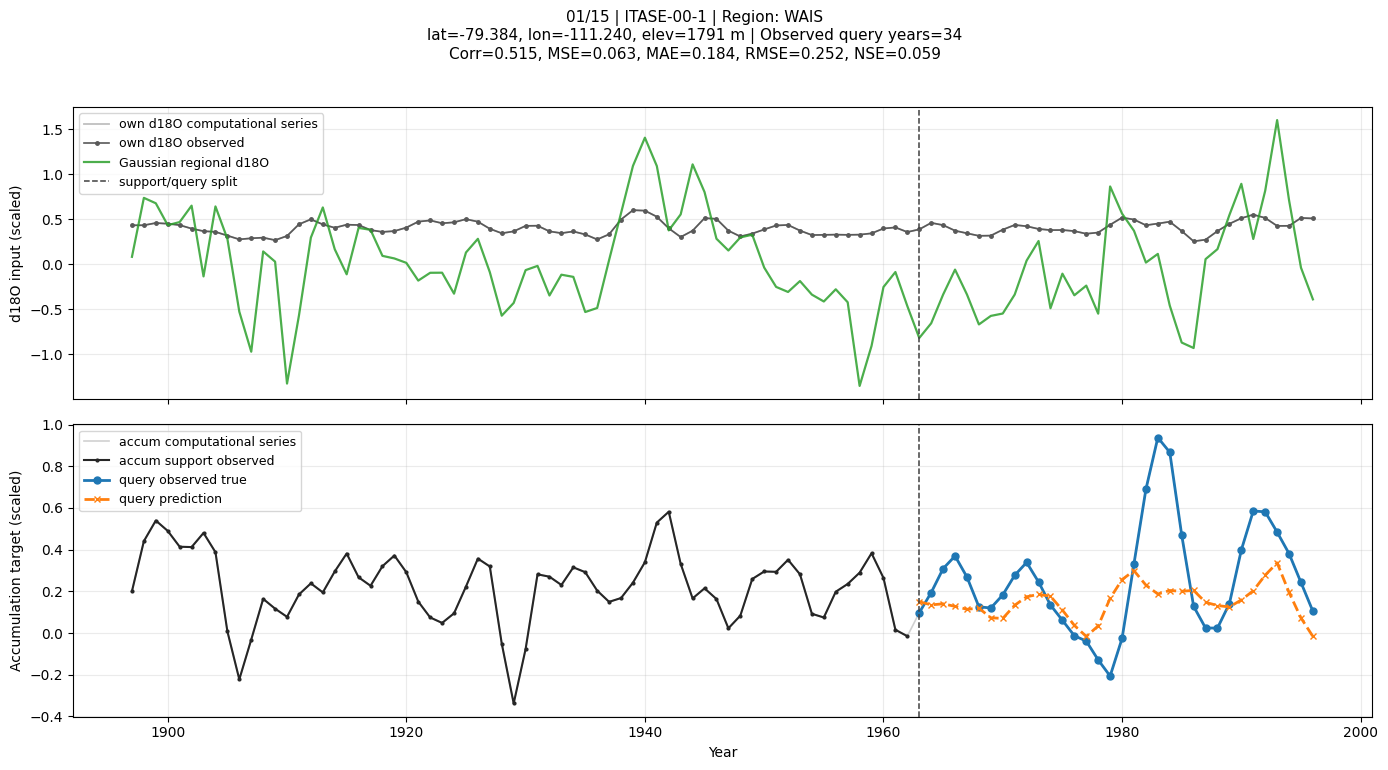

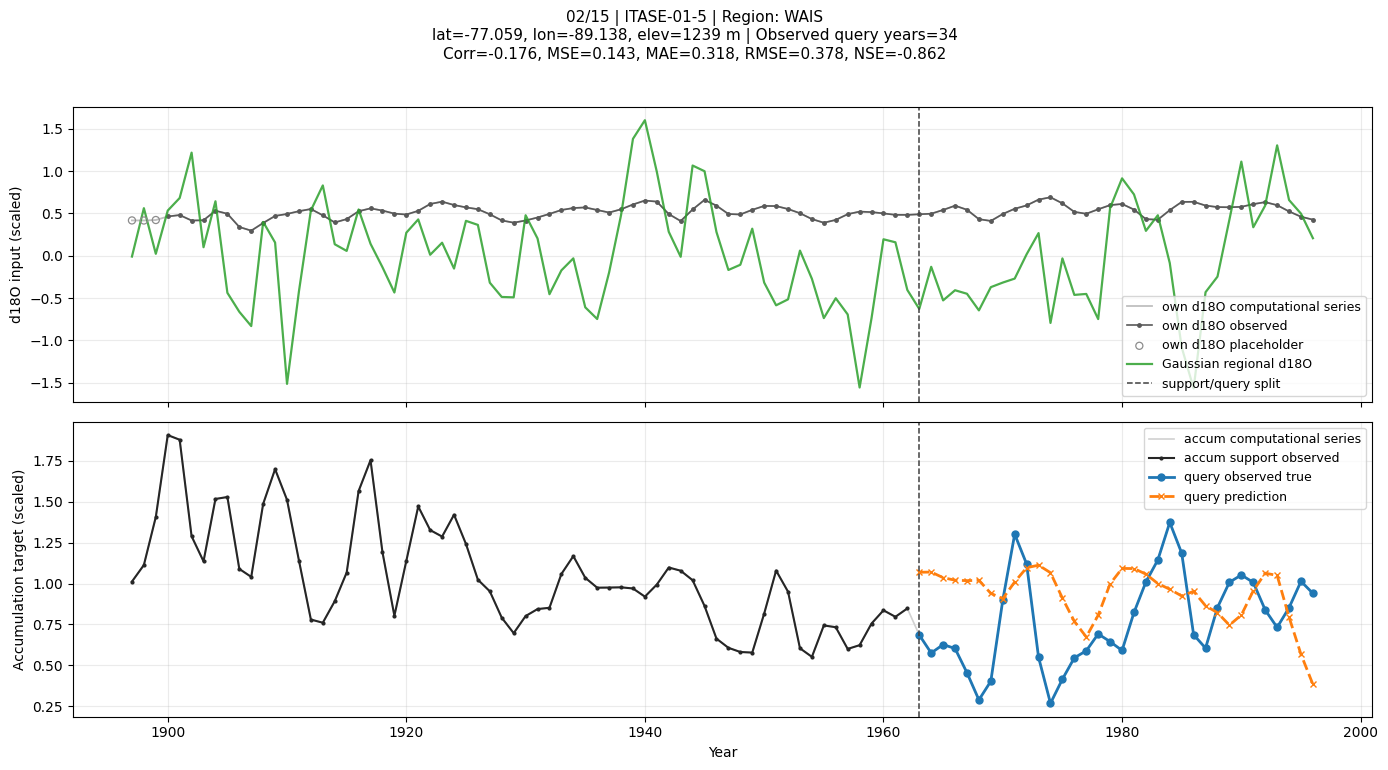

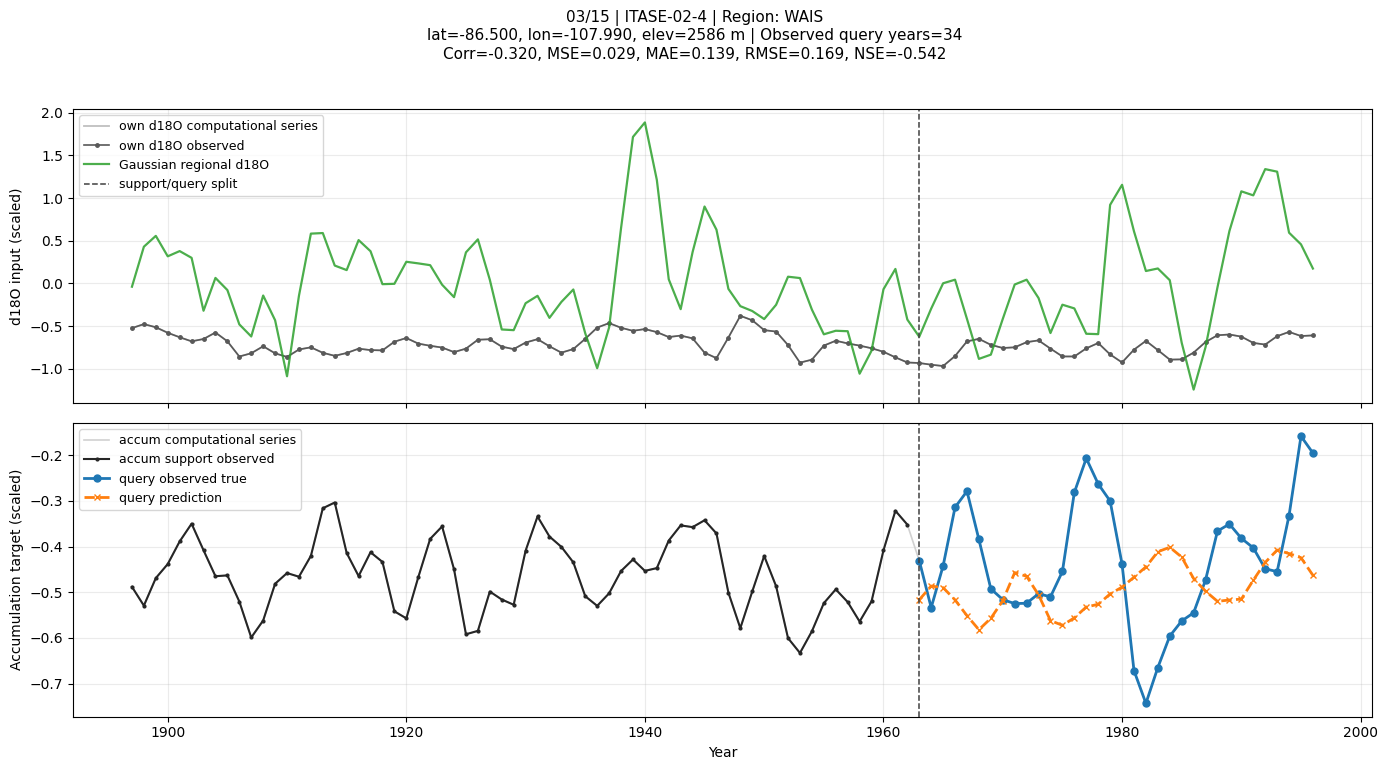

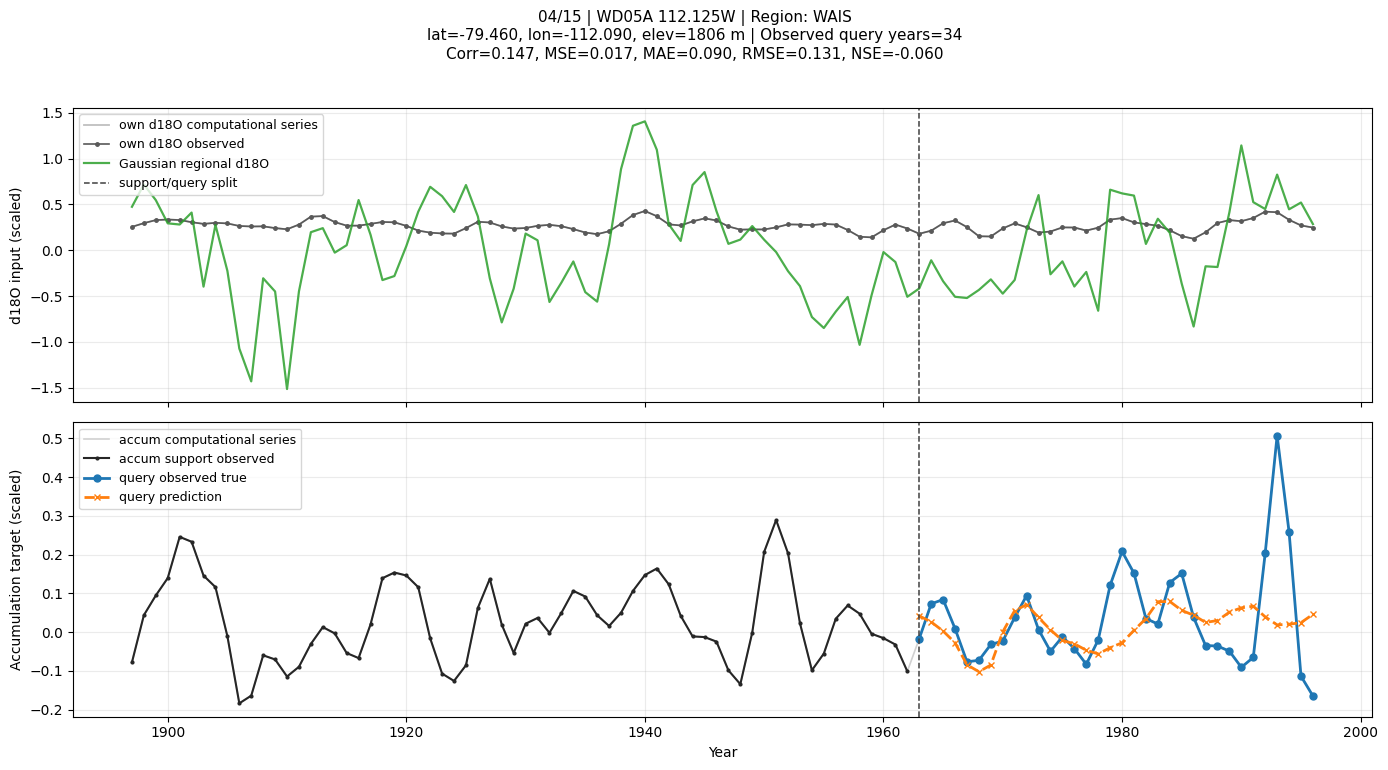

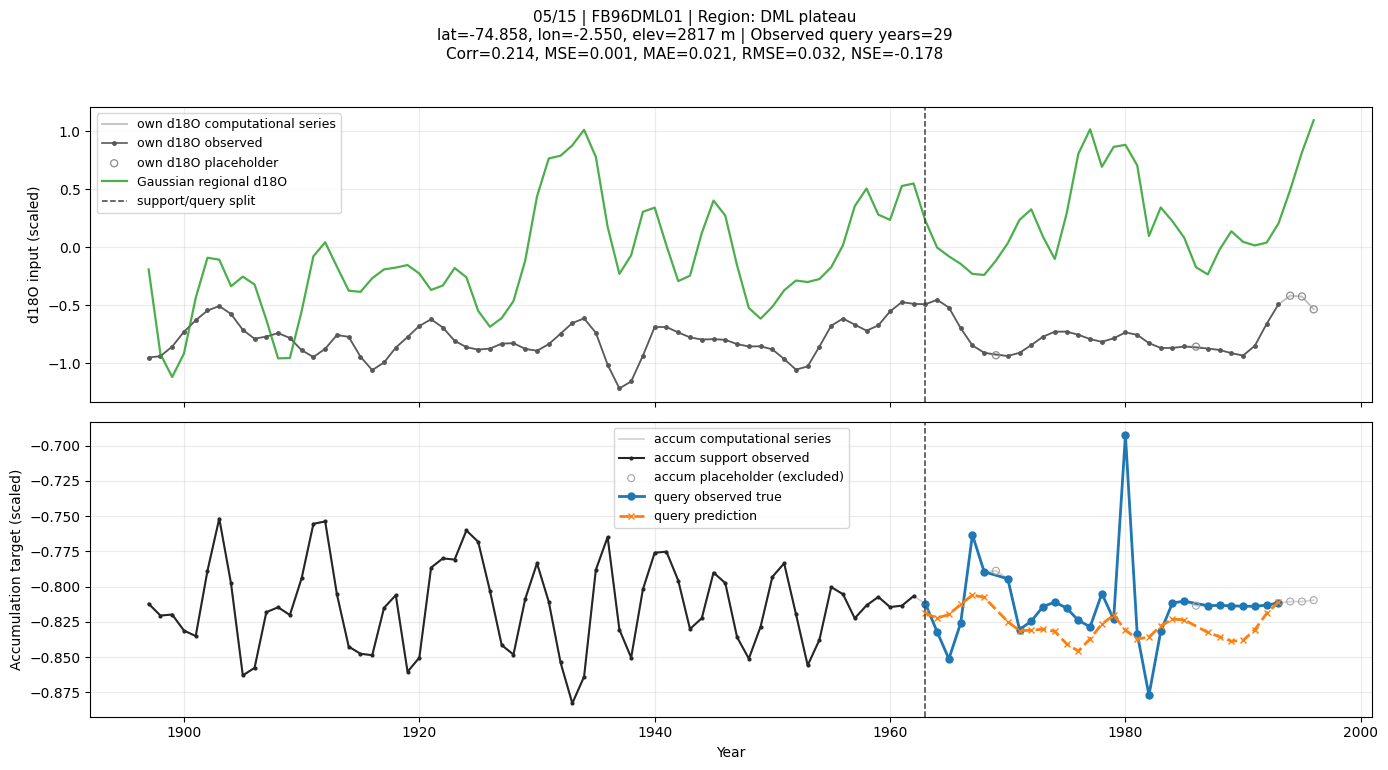

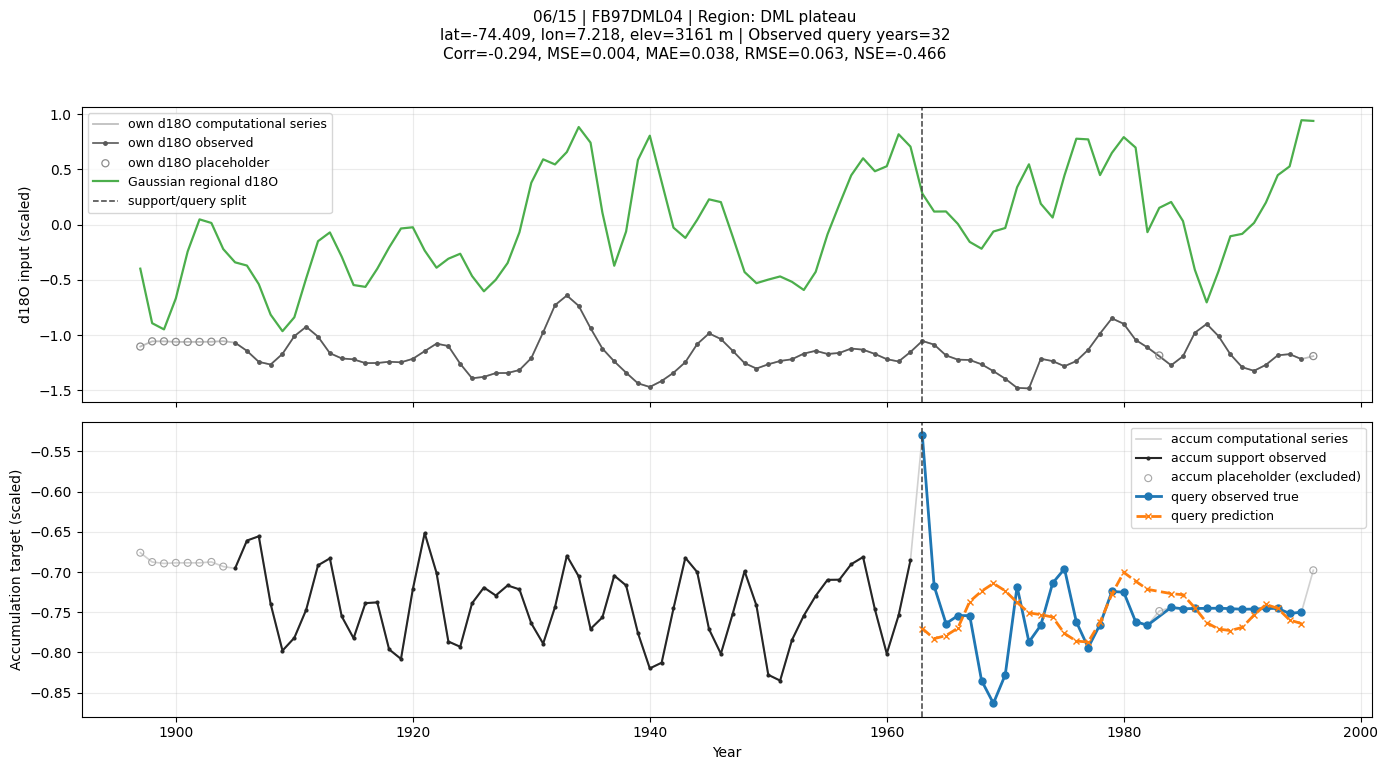

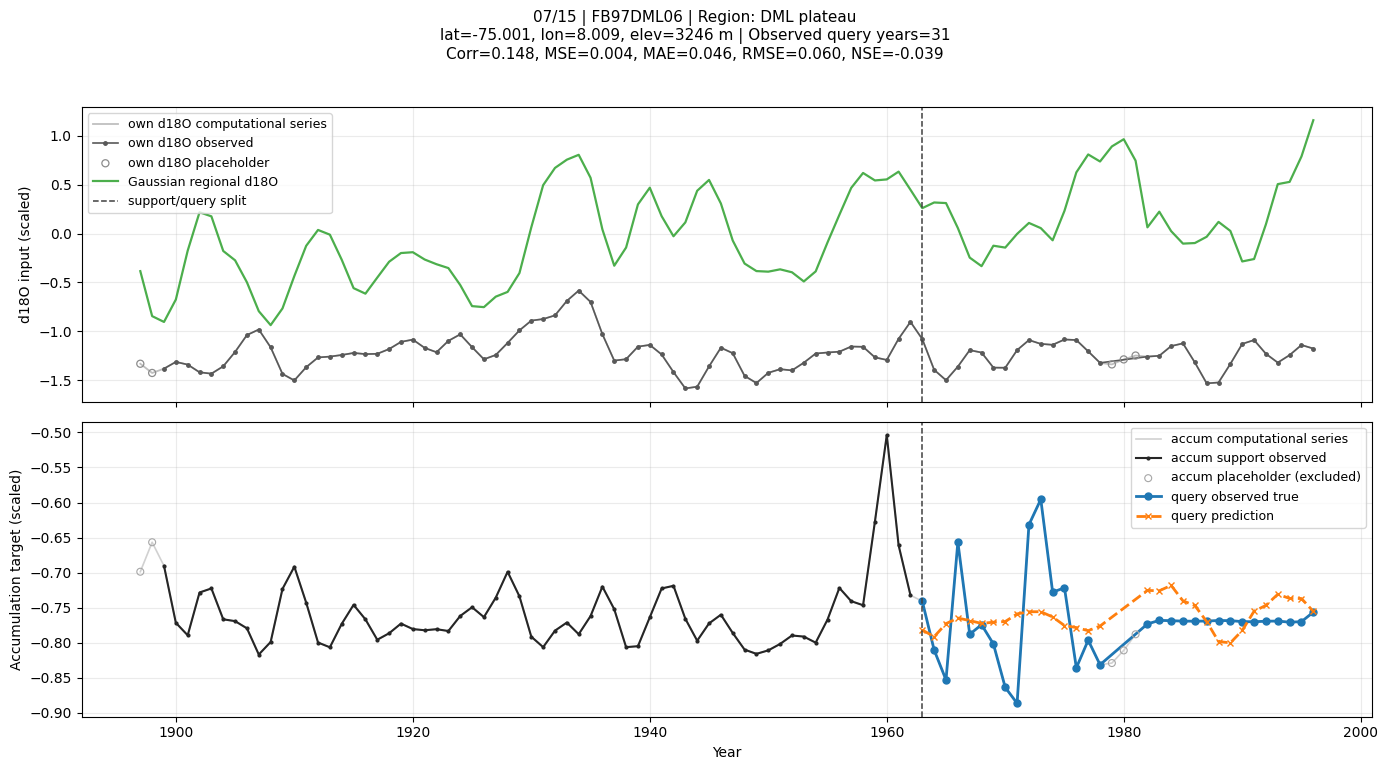

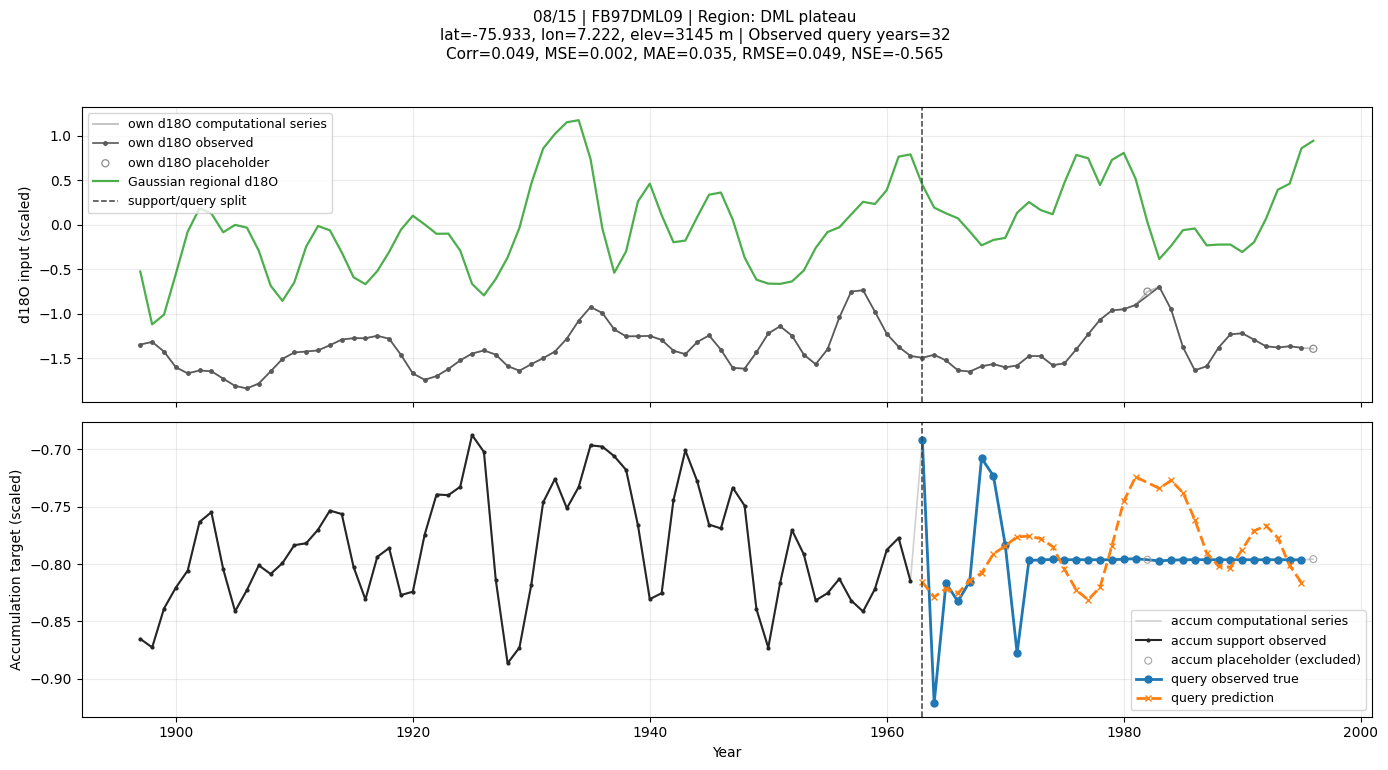

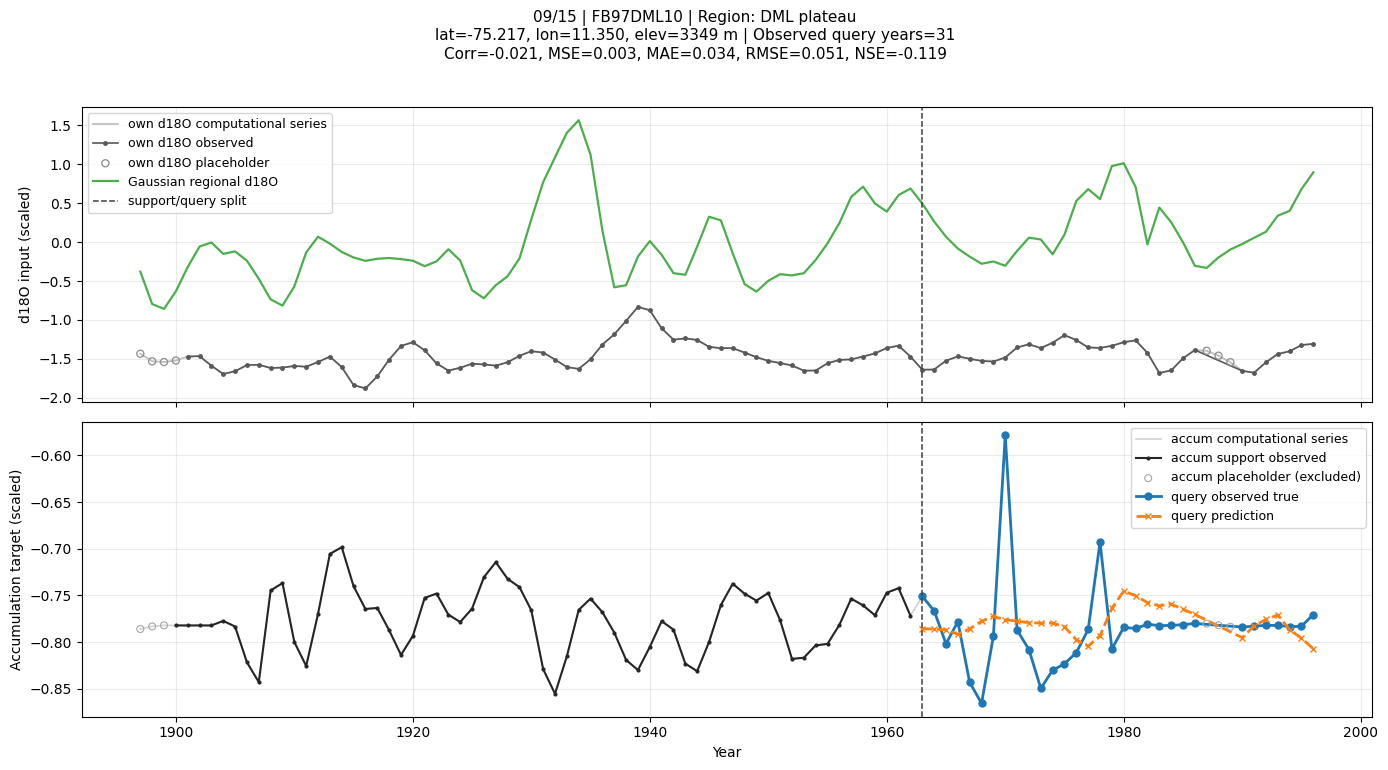

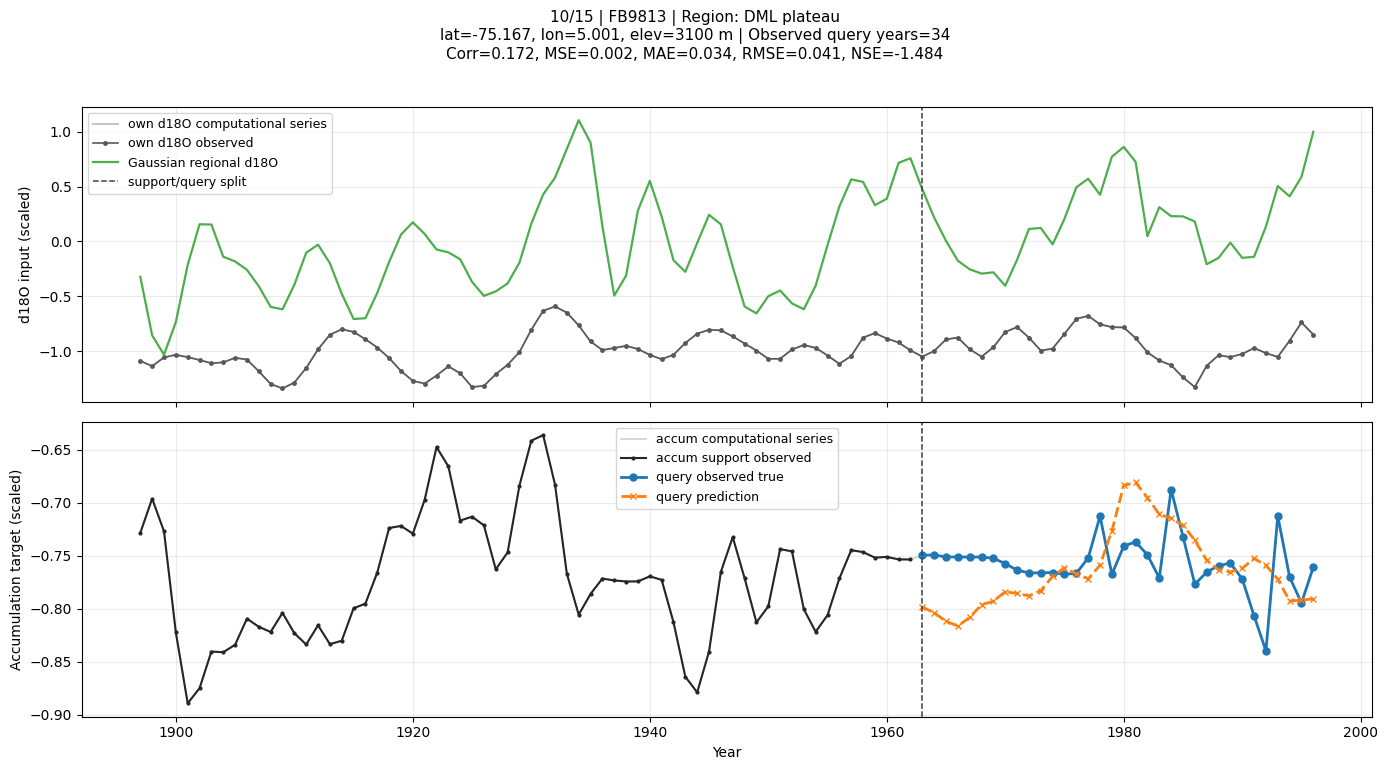

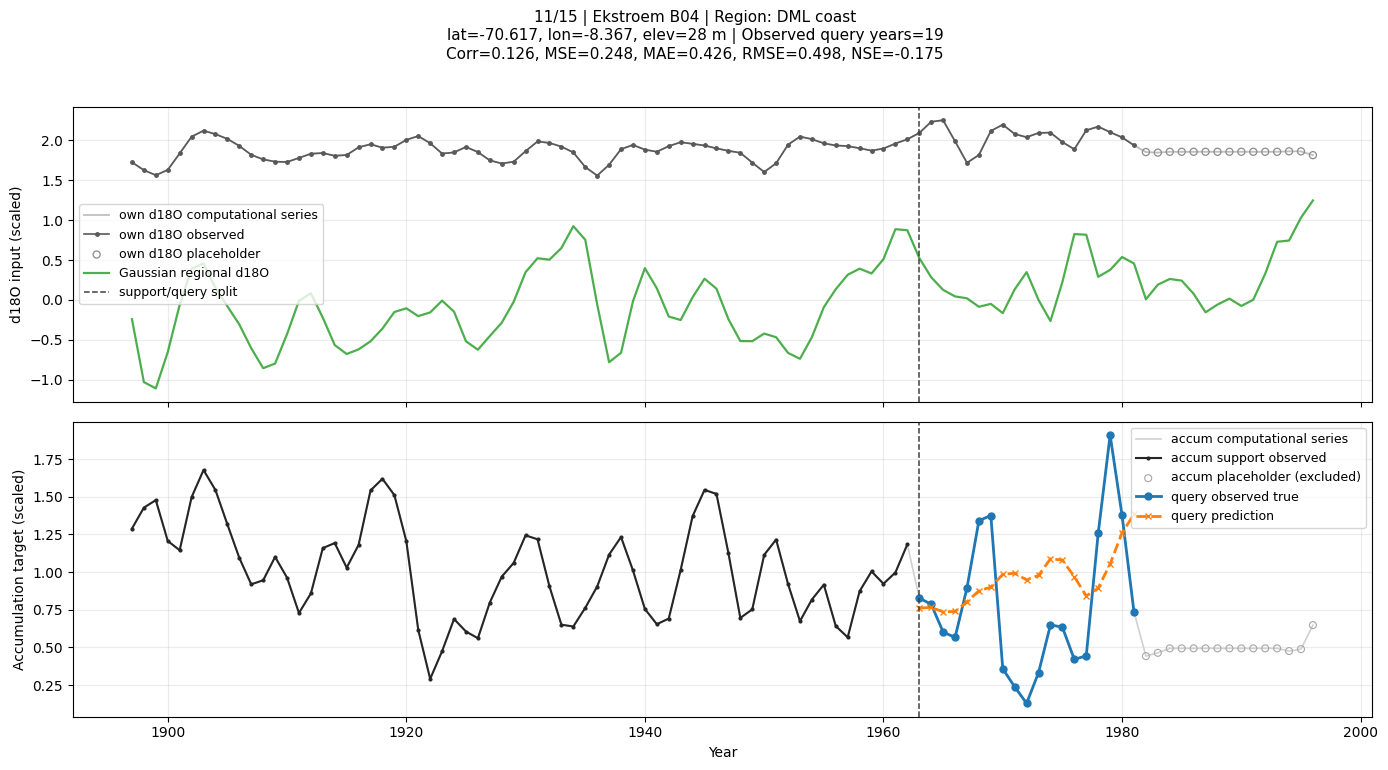

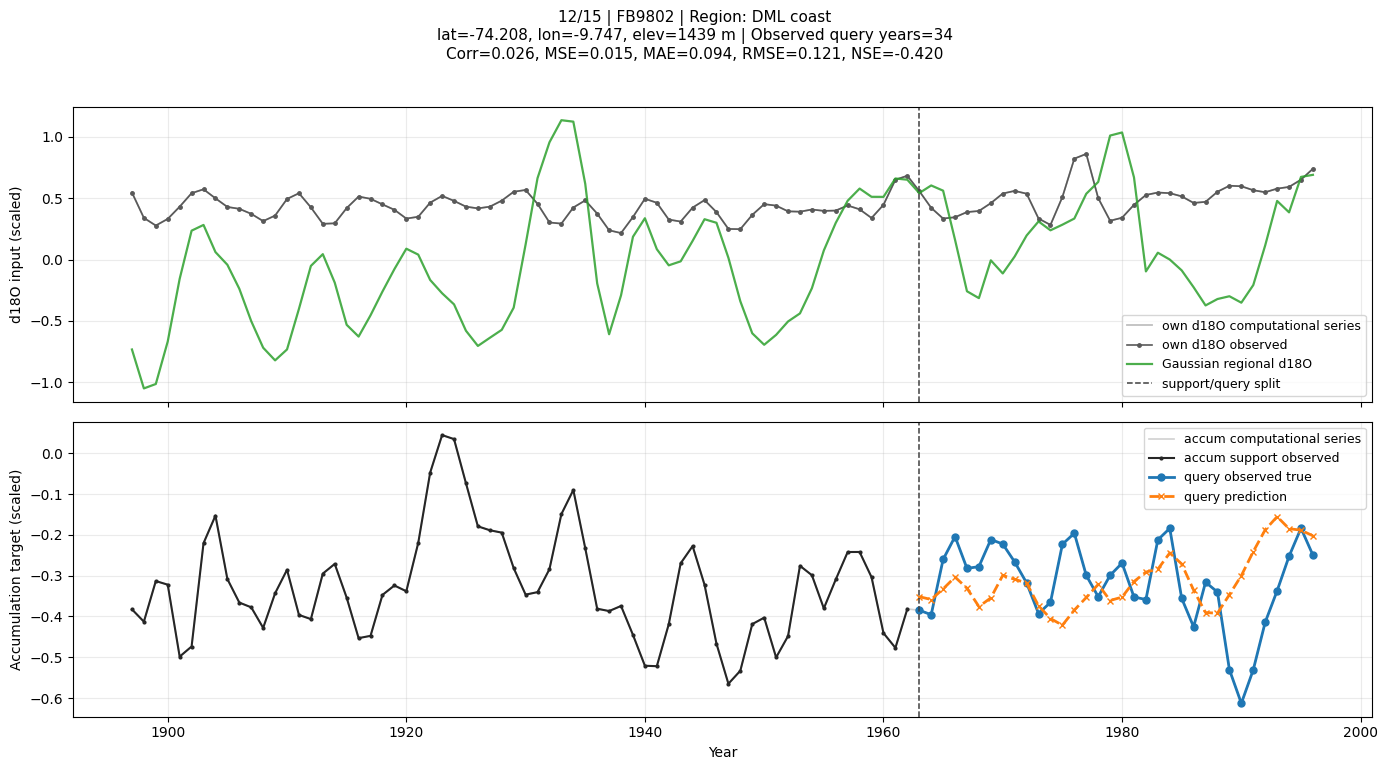

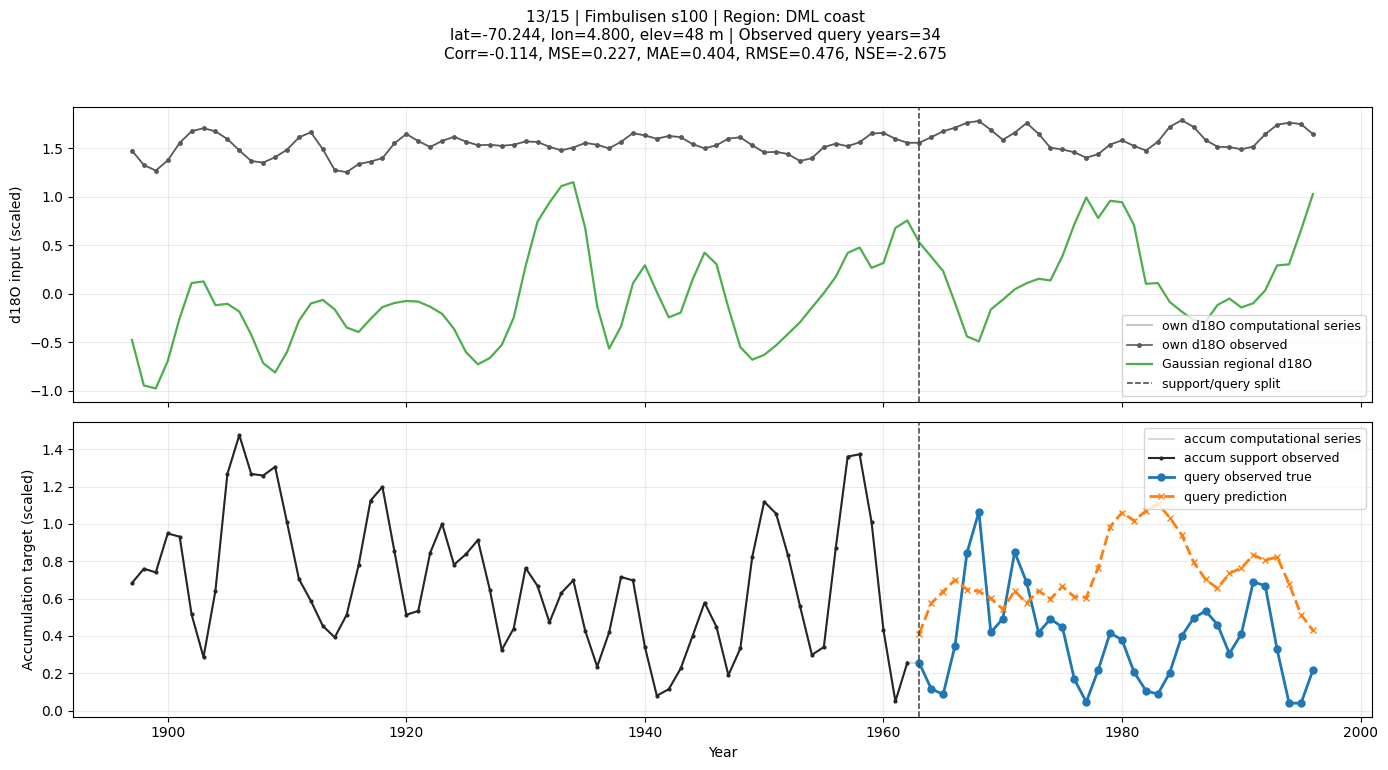

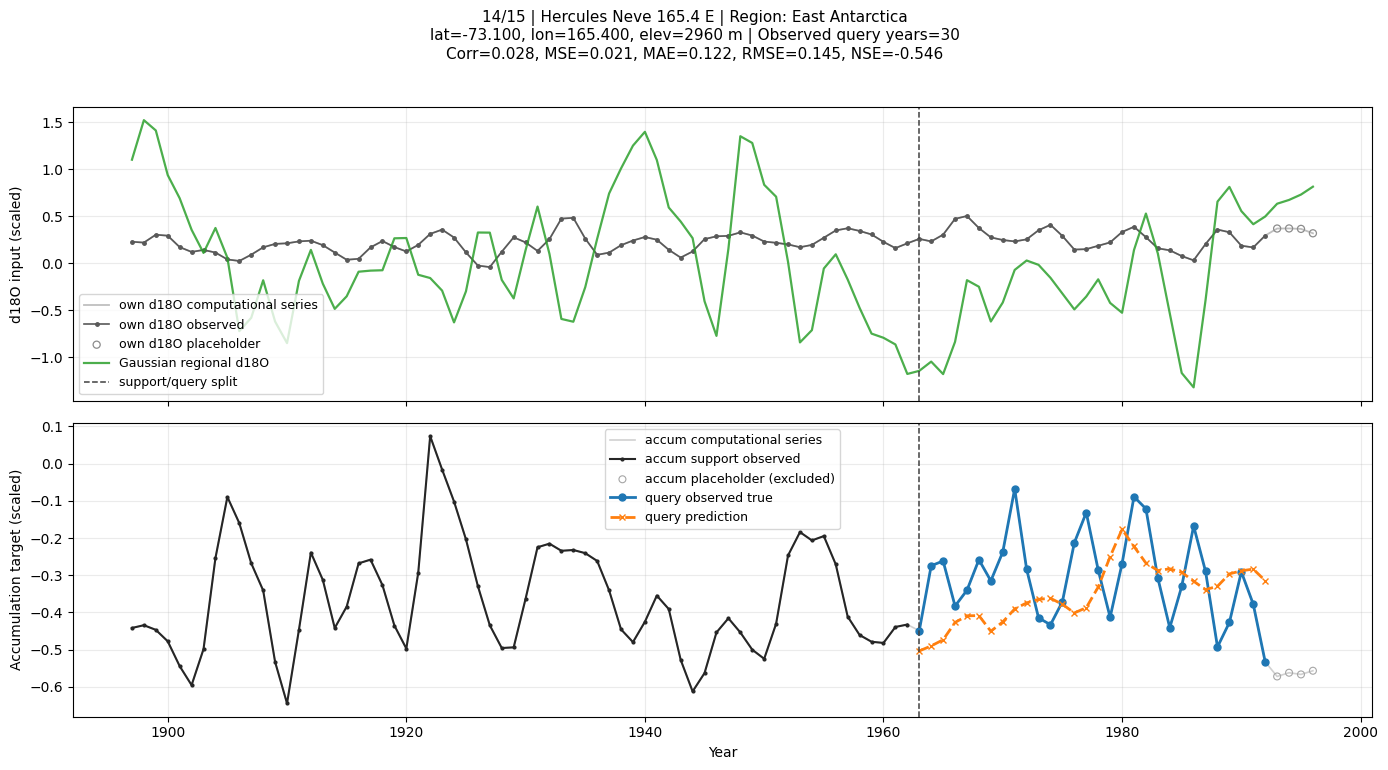

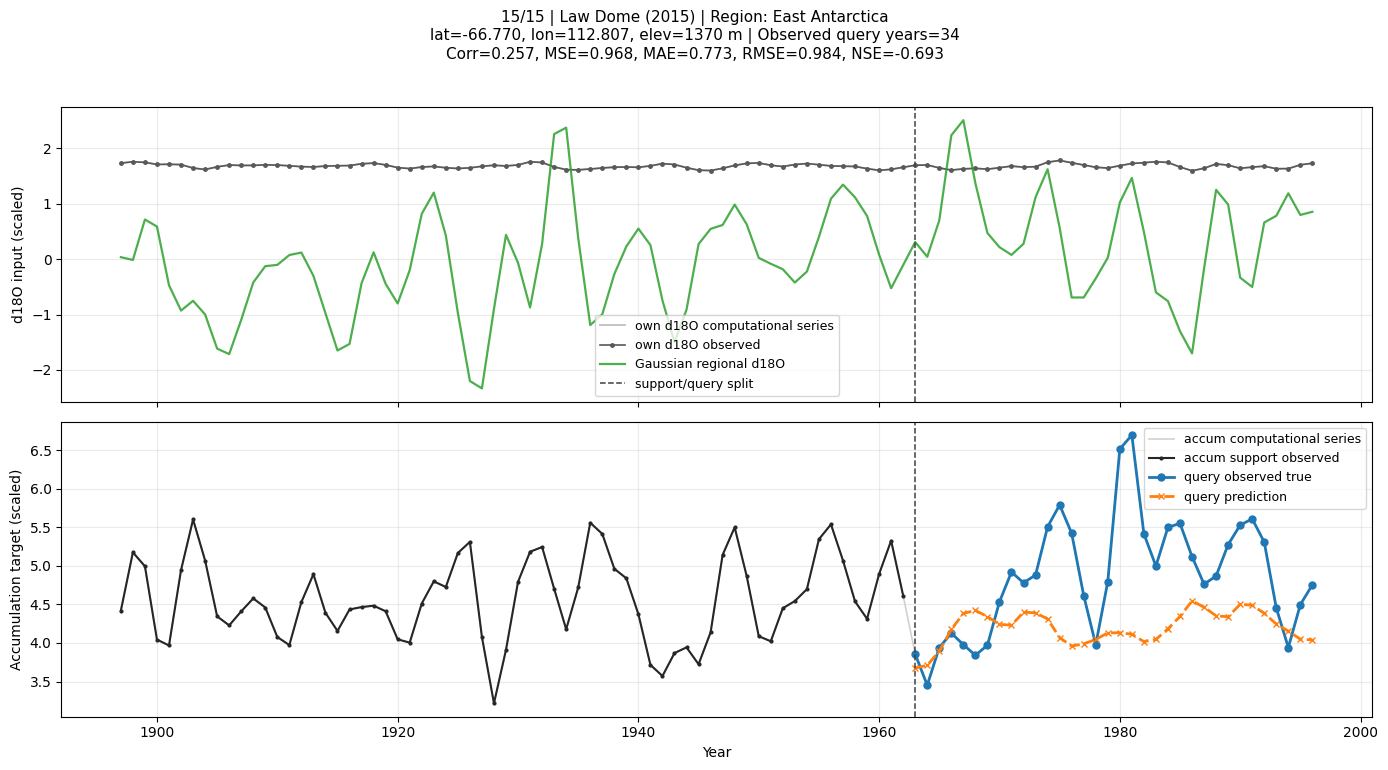

完成：显示了 15 个LOSO站点。


,site,region,latitude,longitude,elevation,n_observed_query_years,corr,mse,mae,rmse,nse
0,Ekstroem B04,DML coast,-70.6167,-8.3667,28.0,19,0.125884,0.247598,0.425757,0.497592,-0.175251
1,FB9802,DML coast,-74.2083,-9.7472,1439.0,34,0.026095,0.014543,0.093505,0.120595,-0.419816
2,Fimbulisen s100,DML coast,-70.2439,4.8000,48.0,34,-0.114043,0.226622,0.404284,0.476049,-2.675016
3,FB96DML01,DML plateau,-74.8583,-2.5500,2817.0,29,0.214181,0.001046,0.020777,0.032345,-0.178435
4,FB97DML04,DML plateau,-74.4094,7.2181,3161.0,32,-0.294457,0.003988,0.038480,0.063147,-0.465549
5,FB97DML06,DML plateau,-75.0011,8.0089,3246.0,31,0.147789,0.003639,0.046205,0.060321,-0.038874
6,FB97DML09,DML plateau,-75.9333,7.2217,3145.0,32,0.049061,0.002371,0.035236,0.048692,-0.565415
7,FB97DML10,DML plateau,-75.2167,11.3500,3349.0,31,-0.020972,0.002618,0.034460,0.051166,-0.118817
8,FB9813,DML plateau,-75.1669,5.0006,3100.0,34,0.172112,0.001666,0.034302,0.040819,-1.484370
9,Hercules Neve 165.4 E,East Antarctica,-73.1000,165.4000,2960.0,30,0.027705,0.020886,0.121984,0.144521,-0.545812


In [2]:
loso_metrics = visualise_loso_results(
    "../loso_runs/"
    "M3_d18O_accum_reg1_tau500_geo1_nq1_xy01_masked_swt1_supportstd1_sl32"
)